In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Version: 12.1
GPU Name: NVIDIA RTX A4000


In [2]:
# ============================================================
# STEP 1 — DDRNet-39 / KITTI
# ENVIRONMENT, REPRODUCIBILITY, RUNTIME,
# PATHS, HISTORY, AND CHECKPOINT INFRASTRUCTURE
#
# Target Architecture:
# DDRNet-39
#
# Target Dataset:
# KITTI Semantic Segmentation — 19 Classes
#
# Training Objective:
#   - Clean retraining from ImageNet initialization
#   - Keep implementation close to original DDRNet
#   - No previous KITTI semantic checkpoint initialization
#   - No Cityscapes semantic checkpoint initialization
#
# Local Hardware Adaptation:
#   - Single GPU
#   - AMP
#   - Physical batch = 4
#   - Gradient accumulation = 3
#   - Effective optimizer batch = 12
#
# Why batch 4 instead of batch 2:
#   Gradient accumulation reproduces optimizer-level batch size,
#   but BatchNorm statistics are computed per physical forward
#   batch. Increasing the physical batch from 2 -> 4 provides
#   more stable normalization while preserving effective batch 12.
#
# Notebook-Safe Output:
#   - tqdm bars do not remain embedded
#   - periodic plots saved only
#   - periodic qualitative images saved only
#   - final plots may be displayed once
#
# IMPORTANT:
# Before starting this clean retraining:
#   - delete/archive old KITTI latest/best checkpoints
#   - delete/archive old history CSV if desired
#   - DO NOT delete DDRNet39_imagenet.pth
# ============================================================


# ============================================================
# 1. COMMON IMPORTS
# ============================================================

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
import datetime
import inspect

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


# ============================================================
# 2. CUDA MEMORY ALLOCATION POLICY
# ============================================================
#
# Configure before significant CUDA allocation.
# ============================================================

os.environ[
    "PYTORCH_CUDA_ALLOC_CONF"
] = "expandable_segments:True"


# ============================================================
# 3. PYTORCH
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


# ============================================================
# 4. SCHEDULER / DATA LOADING
# ============================================================

from torch.optim.lr_scheduler import PolynomialLR

from torch.utils.data import (
    Dataset,
    DataLoader
)


# ============================================================
# 5. MIXED PRECISION
# ============================================================

from torch.amp import (
    GradScaler,
    autocast
)


# ============================================================
# 6. DATA AUGMENTATION
# ============================================================

import albumentations as A

from albumentations.pytorch import (
    ToTensorV2
)


# ============================================================
# 7. PROGRESS MONITORING
# ============================================================

from tqdm import tqdm


# ============================================================
# 8. INITIAL CLEANUP
# ============================================================

gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


warnings.filterwarnings(
    "ignore",
    category=UserWarning
)


# ============================================================
# 9. REPRODUCIBILITY
# ============================================================

SEED = 42


def set_seed(
    seed: int = 42,
    deterministic: bool = False
):
    """
    Configure Python, NumPy and PyTorch random seeds.

    deterministic=False is intentionally retained because:
        - cuDNN benchmarking remains enabled
        - DDRNet training throughput is higher
        - this matches the performance-oriented training setup

    Dataset splitting itself will still be deterministic
    because Step 3 explicitly uses SEED=42.
    """

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed(
            seed
        )

        torch.cuda.manual_seed_all(
            seed
        )


    os.environ[
        "PYTHONHASHSEED"
    ] = str(
        seed
    )


    if deterministic:

        torch.backends.cudnn.deterministic = True

        torch.backends.cudnn.benchmark = False


        try:

            torch.use_deterministic_algorithms(
                True
            )

        except Exception:

            pass


    else:

        torch.backends.cudnn.deterministic = False

        torch.backends.cudnn.benchmark = True


set_seed(
    SEED,
    deterministic=False
)


print(
    f"[*] Seed set to {SEED} "
    "(deterministic=False for efficient DDRNet training)"
)


# ============================================================
# 10. DATALOADER WORKER REPRODUCIBILITY
# ============================================================

def seed_worker(
    worker_id
):
    """
    Reproducible worker initialization.
    """

    worker_seed = (
        SEED
        + worker_id
    )


    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )

    torch.manual_seed(
        worker_seed
    )


# Reproducible DataLoader generator.
g = torch.Generator()


g.manual_seed(
    SEED
)


# ============================================================
# 11. MATPLOTLIB / JUPYTER CONFIGURATION
# ============================================================

%matplotlib inline


plt.rcParams[
    "figure.dpi"
] = 150


plt.rcParams[
    "savefig.dpi"
] = 600


plt.rcParams[
    "figure.figsize"
] = (
    10,
    6
)


sns.set_style(
    "whitegrid"
)


sns.set_context(
    "talk",
    font_scale=0.9
)


# ============================================================
# 12. NOTEBOOK-SAFE OUTPUT POLICY
# ============================================================
#
# This explicitly prevents the notebook-size problem that
# occurred during the previous long experiment.
# ============================================================

NOTEBOOK_SAFE_MODE = True


# tqdm progress bars are replaced rather than permanently
# embedded for every epoch.
TQDM_LEAVE = False


# Save periodic training curves but do not display them.
DISPLAY_PERIODIC_TRAINING_PLOTS = False


# Save periodic qualitative results but do not display them.
DISPLAY_PERIODIC_QUALITATIVE = False


# Final reporting cells may show their small number of figures.
DISPLAY_FINAL_REPORT_PLOTS = True


# Prevent huge history DataFrames from being rendered.
MAX_NOTEBOOK_TABLE_ROWS = 25


# Periodic file-save intervals.
TRAINING_PLOT_SAVE_INTERVAL = 5

QUAL_VIS_SAVE_INTERVAL = 10


print(
    "\n--- Notebook-Safe Output Policy ---"
)


print(
    f"[*] Safe mode                   : "
    f"{NOTEBOOK_SAFE_MODE}"
)


print(
    f"[*] tqdm leave                  : "
    f"{TQDM_LEAVE}"
)


print(
    f"[*] Periodic plots displayed   : "
    f"{DISPLAY_PERIODIC_TRAINING_PLOTS}"
)


print(
    f"[*] Periodic visuals displayed : "
    f"{DISPLAY_PERIODIC_QUALITATIVE}"
)


print(
    f"[*] Final plots displayed      : "
    f"{DISPLAY_FINAL_REPORT_PLOTS}"
)


# ============================================================
# 13. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    f"\n[*] Using Device: "
    f"{DEVICE}"
)


if torch.cuda.is_available():


    print(
        f"    GPU Model: "
        f"{torch.cuda.get_device_name(0)}"
    )


    print(
        f"    CUDA Toolchain Version: "
        f"{torch.version.cuda}"
    )


    total_gpu_memory = (

        torch.cuda
        .get_device_properties(0)
        .total_memory

        / 1024**3
    )


    print(
        f"    Total Available GPU Memory: "
        f"{total_gpu_memory:.2f} GB"
    )


    try:


        torch.backends.cuda.matmul.allow_tf32 = True

        torch.backends.cudnn.allow_tf32 = True


        print(
            "    TF32 matrix operations enabled."
        )


    except Exception as error:


        print(
            f"    TF32 configuration skipped: "
            f"{error}"
        )


# ============================================================
# 14. DATASET / EXPERIMENT IDENTIFICATION
# ============================================================

DATASET_NAME = (
    "KITTI"
)


MODEL_NAME = (
    "DDRNet-39"
)


# New clean-retraining identity.
EXPERIMENT_NAME = (
    "DDRNet39_KITTI_PaperAligned_Retrain"
)


TRAINING_PROTOCOL_NAME = (
    "DDRNet_PaperAligned_KITTI_Adaptation"
)


# ============================================================
# 15. DDRNet-39 ARCHITECTURE CONSTANTS
# ============================================================
#
# These must remain unchanged in the corrected retraining.
# ============================================================

NUM_CLASSES = 19


# DDRNet-39 residual-stage depths.
DDRNET_BLOCK_DEPTHS = (
    3,
    4,
    6,
    3
)


# Base width.
DDRNET_BASE_PLANES = 64


# Persistent high-resolution branch width.
DDRNET_HIGHRES_PLANES = 128


# DAPPM internal branch width.
DDRNET_DAPPM_BRANCH_PLANES = 128


# DDRNet-39 segmentation-head intermediate width.
DDRNET_HEAD_PLANES = 256


# DDRNet bottleneck expansion.
DDRNET_BOTTLENECK_EXPANSION = 2


# Paper auxiliary/deep-supervision coefficient.
AUX_LOSS_WEIGHT = 0.4


# Required DDRNet interpolation behavior.
ALIGN_CORNERS = False


# ============================================================
# 16. ARCHITECTURE SAFETY CHECK
# ============================================================

if tuple(
    DDRNET_BLOCK_DEPTHS
) != (
    3,
    4,
    6,
    3
):

    raise RuntimeError(
        "DDRNet-39 architecture depth configuration "
        "must remain (3, 4, 6, 3)."
    )


if NUM_CLASSES != 19:

    raise RuntimeError(
        "KITTI semantic experiment expects "
        "19 Cityscapes-compatible train classes."
    )


if not np.isclose(
    AUX_LOSS_WEIGHT,
    0.4
):

    raise RuntimeError(
        "DDRNet auxiliary loss weight must remain 0.4 "
        "for this paper-aligned experiment."
    )


if ALIGN_CORNERS is not False:

    raise RuntimeError(
        "DDRNet pretrained segmentation configuration "
        "requires ALIGN_CORNERS=False."
    )


print(
    "\n[✓] DDRNet-39 architecture constants verified."
)


# ============================================================
# 17. PRETRAINING STRATEGY
# ============================================================
#
# Correct experiment:
#
#       official DDRNet-39 ImageNet checkpoint
#                       ↓
#                     KITTI
#
# NOT:
#
#       old DDRNet-KITTI checkpoint -> KITTI
#
# NOT:
#
#       Cityscapes semantic checkpoint -> KITTI
# ============================================================

PRETRAINING_SOURCE = (
    "ImageNet"
)


USE_IMAGENET_PRETRAINED = True


USE_CITYSCAPES_PRETRAINED = False


if not USE_IMAGENET_PRETRAINED:

    raise RuntimeError(
        "Corrected DDRNet-KITTI retraining is expected "
        "to start from DDRNet-39 ImageNet initialization."
    )


if USE_CITYSCAPES_PRETRAINED:

    raise RuntimeError(
        "Cityscapes semantic initialization must remain "
        "disabled for this clean ImageNet -> KITTI experiment."
    )


# ============================================================
# 18. CORRECTED SINGLE-GPU BATCH STRATEGY
# ============================================================
#
# Previous experiment:
#
#       physical batch = 2
#       accumulation   = 6
#       effective      = 12
#
# Problem:
#       BatchNorm statistics were still computed using only
#       TWO samples during each forward pass.
#
# Corrected preferred configuration:
#
#       physical batch = 4
#       accumulation   = 3
#       effective      = 12
#
# This keeps the same optimizer-level effective batch while
# providing more stable normalization statistics.
#
# IMPORTANT:
# If Step 4/5 later produces CUDA OOM, use:
#
#       physical batch = 3
#       accumulation   = 4
#
# before falling back to the old 2 x 6 setting.
# ============================================================

PHYSICAL_BATCH_SIZE = 4


GRAD_ACCUM_STEPS = 3


EFFECTIVE_BATCH_SIZE = (
    PHYSICAL_BATCH_SIZE
    * GRAD_ACCUM_STEPS
)


TARGET_EFFECTIVE_BATCH_SIZE = 12


if (
    EFFECTIVE_BATCH_SIZE
    != TARGET_EFFECTIVE_BATCH_SIZE
):

    raise RuntimeError(
        "Corrected DDRNet training expects "
        f"effective batch size {TARGET_EFFECTIVE_BATCH_SIZE}, "
        f"but received {EFFECTIVE_BATCH_SIZE}."
    )


USE_AMP = (
    torch.cuda.is_available()
)


scaler = GradScaler(
    DEVICE.type,
    enabled=USE_AMP
)


print(
    "\n--- Corrected DDRNet-39 Runtime Strategy ---"
)


print(
    f"[*] Mixed Precision Enabled : "
    f"{USE_AMP}"
)


print(
    f"[*] Physical Batch Size     : "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    f"[*] Gradient Accumulation   : "
    f"{GRAD_ACCUM_STEPS}"
)


print(
    f"[*] Effective Batch Size    : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


print(
    "[*] Normalization sees physical batch = "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    "[*] Optimizer sees effective batch = "
    f"{EFFECTIVE_BATCH_SIZE}"
)


# ============================================================
# 19. KITTI DATASET PATHS
# ============================================================

DATASET_ROOT = Path(
    "/home/hrusikesh-nishank/miniconda3/envs/"
    "Segmentation/Datasets/KITTI"
)


KITTI_TRAINING_ROOT = (
    DATASET_ROOT
    / "training"
)


IMG_ROOT = (
    KITTI_TRAINING_ROOT
    / "image_2"
)


MASK_ROOT = (
    KITTI_TRAINING_ROOT
    / "semantic"
)


# ============================================================
# 20. DATASET PATH STATUS
# ============================================================

print(
    "\n--- KITTI Dataset Paths ---"
)


print(
    f"[*] Dataset root       : "
    f"{DATASET_ROOT}"
)


print(
    f"[*] Image root         : "
    f"{IMG_ROOT}"
)


print(
    f"[*] Semantic mask root : "
    f"{MASK_ROOT}"
)


print(
    f"[*] Image root exists  : "
    f"{IMG_ROOT.exists()}"
)


print(
    f"[*] Mask root exists   : "
    f"{MASK_ROOT.exists()}"
)


if not IMG_ROOT.exists():

    warnings.warn(
        "KITTI image_2 directory was not found at the "
        "configured path. Verify DATASET_ROOT before Step 3."
    )


if not MASK_ROOT.exists():

    warnings.warn(
        "KITTI semantic directory was not found at the "
        "configured path. Verify DATASET_ROOT before Step 3."
    )


# ============================================================
# 21. CENTRALIZED RESULT DIRECTORIES
# ============================================================
#
# Keep the same overall DDRNet_kitti experiment directory.
# Old checkpoints should have been deleted/archived before
# starting this clean retraining.
# ============================================================

FINAL_SAVE_DIR = Path(
    "/home/hrusikesh-nishank/Pictures/"
    "DDRNet_kitti/"
    "Results_Export_DDRNet_kitti"
)


QUAL_VIS_DIR = Path(
    "/home/hrusikesh-nishank/Pictures/"
    "DDRNet_kitti/"
    "training_visuals_DDRNet_kitti"
)


CHECKPOINT_DIR = (
    FINAL_SAVE_DIR
    / "progressive_checkpoints_DDRNet_kitti"
)


PLOTS_DIR = (
    FINAL_SAVE_DIR
    / "training_plots_DDRNet_kitti"
)


LOGS_DIR = (
    FINAL_SAVE_DIR
    / "training_logs_DDRNet_kitti"
)


METRICS_DIR = (
    FINAL_SAVE_DIR
    / "training_metrics_DDRNet_kitti"
)


# ============================================================
# 22. CREATE RESULT DIRECTORIES
# ============================================================

for directory in [

    FINAL_SAVE_DIR,
    QUAL_VIS_DIR,
    CHECKPOINT_DIR,
    PLOTS_DIR,
    LOGS_DIR,
    METRICS_DIR,

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 23. MODEL IDENTIFICATION
# ============================================================

MODEL_ALIAS = (
    "DDRNet-39 "
    "(Deep Dual-Resolution Backbone + "
    "Bilateral Fusion + DAPPM + Deep Supervision)"
)


print(
    "\n--- Model Configuration ---"
)


print(
    f"[*] Model                   : "
    f"{MODEL_NAME}"
)


print(
    f"[*] Dataset                 : "
    f"{DATASET_NAME}"
)


print(
    f"[*] Experiment              : "
    f"{EXPERIMENT_NAME}"
)


print(
    f"[*] Training protocol       : "
    f"{TRAINING_PROTOCOL_NAME}"
)


print(
    f"[*] Number of Classes       : "
    f"{NUM_CLASSES}"
)


print(
    f"[*] Residual Depths         : "
    f"{DDRNET_BLOCK_DEPTHS}"
)


print(
    f"[*] Base Channels           : "
    f"{DDRNET_BASE_PLANES}"
)


print(
    f"[*] High-Resolution Channels: "
    f"{DDRNET_HIGHRES_PLANES}"
)


print(
    f"[*] DAPPM Channels          : "
    f"{DDRNET_DAPPM_BRANCH_PLANES}"
)


print(
    f"[*] Head Channels           : "
    f"{DDRNET_HEAD_PLANES}"
)


print(
    f"[*] Auxiliary Weight        : "
    f"{AUX_LOSS_WEIGHT}"
)


print(
    f"[*] align_corners           : "
    f"{ALIGN_CORNERS}"
)


print(
    f"[*] Pretraining Source      : "
    f"{PRETRAINING_SOURCE}"
)


print(
    f"[*] Cityscapes Pretraining  : "
    f"{USE_CITYSCAPES_PRETRAINED}"
)


# ============================================================
# 24. TRAINING HISTORY FILE
# ============================================================

HISTORY_FILE = (
    LOGS_DIR
    / "training_history_DDRNet39_KITTI.csv"
)


# ============================================================
# 25. TRAINING HISTORY
# ============================================================
#
# Keep keys unchanged because later training/export cells
# depend on these names.
# ============================================================

history = {

    # General
    "epoch": [],
    "phase": [],


    # Training losses
    "train_total_loss": [],
    "train_main_loss": [],
    "train_aux_loss": [],


    # Training segmentation metrics
    "train_miou": [],
    "train_macc": [],
    "train_aacc": [],


    # Validation
    "val_total_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],


    # Optimization / runtime
    "learning_rate": [],
    "epoch_time_sec": [],
    "total_training_time_str": [],


    # Training Precision / Recall / F1
    "train_Precision_Macro": [],
    "train_Recall_Macro": [],
    "train_F1_Macro": [],

    "train_Precision_Micro": [],
    "train_Recall_Micro": [],
    "train_F1_Micro": [],


    # Validation Precision / Recall / F1
    "val_Precision_Macro": [],
    "val_Recall_Macro": [],
    "val_F1_Macro": [],

    "val_Precision_Micro": [],
    "val_Recall_Micro": [],
    "val_F1_Micro": [],
}


# ============================================================
# 26. BEST / LATEST MODEL TRACKING
# ============================================================

best_record = {

    "epoch":
        -1,

    "best_epoch":
        -1,

    # Percentage units.
    "best_miou":
        -1.0,

    "best_path":
        str(
            CHECKPOINT_DIR
            / "ddrnet39_kitti_best.pth"
        ),

    "latest_path":
        str(
            CHECKPOINT_DIR
            / "ddrnet39_kitti_latest.pth"
        ),
}


# ============================================================
# 27. OLD-CHECKPOINT DIAGNOSTIC
# ============================================================
#
# We do NOT automatically delete checkpoints from inside the
# notebook because accidental deletion would be dangerous.
#
# Since this is intended as a clean retraining, existing files
# are reported clearly.
# ============================================================

existing_training_artifacts = []


for candidate_path in [

    Path(
        best_record[
            "latest_path"
        ]
    ),

    Path(
        best_record[
            "best_path"
        ]
    ),

]:

    if candidate_path.exists():

        existing_training_artifacts.append(
            candidate_path
        )


if existing_training_artifacts:


    print(
        "\n[!] EXISTING DDRNet-KITTI CHECKPOINT(S) DETECTED:"
    )


    for artifact_path in existing_training_artifacts:

        print(
            f"    {artifact_path}"
        )


    print(
        "\n[!] For a CLEAN retraining, remove/archive these "
        "before Step 5."
    )


else:


    print(
        "\n[✓] No old DDRNet-KITTI best/latest checkpoints "
        "were detected."
    )


# ============================================================
# 28. ATOMIC FILE-SAVE HELPERS
# ============================================================

def atomic_torch_save(
    state,
    target_path
):
    """
    Save a PyTorch object through a temporary file and then
    atomically replace the final target.
    """

    target_path = Path(
        target_path
    )


    temporary_path = Path(
        str(
            target_path
        )
        + ".tmp"
    )


    torch.save(
        state,
        temporary_path
    )


    os.replace(
        temporary_path,
        target_path
    )


def atomic_history_csv_save(
    history_dict,
    target_path
):
    """
    Atomically save training history CSV.
    """

    target_path = Path(
        target_path
    )


    temporary_path = Path(
        str(
            target_path
        )
        + ".tmp"
    )


    pd.DataFrame(
        history_dict
    ).to_csv(
        temporary_path,
        index=False
    )


    os.replace(
        temporary_path,
        target_path
    )


# ============================================================
# 29. CHECKPOINT MANAGER
# ============================================================

def save_checkpoint(
    epoch,
    model,
    optimizer,
    scaler,
    scheduler,
    history_dict,
    total_time,
    is_best=False
):
    """
    Save complete DDRNet-39 KITTI training state.

    latest:
        crash/power-failure recovery

    best:
        replaced only when validation mIoU improves

    Complete training history is embedded in the checkpoint
    and exported separately as CSV.
    """

    state = {

        # ----------------------------------------------------
        # Training state
        # ----------------------------------------------------

        "epoch":
            epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scaler_state_dict":
            scaler.state_dict(),

        "scheduler_state_dict":
            (
                scheduler.state_dict()
                if scheduler is not None
                else None
            ),

        "history":
            history_dict,

        "total_training_time":
            total_time,

        "best_record":
            best_record,


        # ----------------------------------------------------
        # Experiment identity
        # ----------------------------------------------------

        "experiment_name":
            EXPERIMENT_NAME,

        "training_protocol_name":
            TRAINING_PROTOCOL_NAME,

        "dataset_name":
            DATASET_NAME,

        "model_name":
            MODEL_NAME,

        "model_alias":
            MODEL_ALIAS,

        "num_classes":
            NUM_CLASSES,

        "seed":
            SEED,


        # ----------------------------------------------------
        # DDRNet architecture
        # ----------------------------------------------------

        "ddrnet_block_depths":
            DDRNET_BLOCK_DEPTHS,

        "ddrnet_base_planes":
            DDRNET_BASE_PLANES,

        "ddrnet_highres_planes":
            DDRNET_HIGHRES_PLANES,

        "ddrnet_dappm_branch_planes":
            DDRNET_DAPPM_BRANCH_PLANES,

        "ddrnet_head_planes":
            DDRNET_HEAD_PLANES,

        "ddrnet_bottleneck_expansion":
            DDRNET_BOTTLENECK_EXPANSION,

        "aux_loss_weight":
            AUX_LOSS_WEIGHT,

        "align_corners":
            ALIGN_CORNERS,


        # ----------------------------------------------------
        # Pretraining
        # ----------------------------------------------------

        "pretraining_source":
            PRETRAINING_SOURCE,

        "use_imagenet_pretrained":
            USE_IMAGENET_PRETRAINED,

        "use_cityscapes_pretrained":
            USE_CITYSCAPES_PRETRAINED,


        # ----------------------------------------------------
        # Batch / AMP
        # ----------------------------------------------------

        "physical_batch_size":
            PHYSICAL_BATCH_SIZE,

        "grad_accum_steps":
            GRAD_ACCUM_STEPS,

        "effective_batch_size":
            EFFECTIVE_BATCH_SIZE,

        "target_effective_batch_size":
            TARGET_EFFECTIVE_BATCH_SIZE,

        "use_amp":
            USE_AMP,


        # ----------------------------------------------------
        # Output safety
        # ----------------------------------------------------

        "notebook_safe_mode":
            NOTEBOOK_SAFE_MODE,

        "tqdm_leave":
            TQDM_LEAVE,

        "display_periodic_training_plots":
            DISPLAY_PERIODIC_TRAINING_PLOTS,

        "display_periodic_qualitative":
            DISPLAY_PERIODIC_QUALITATIVE,
    }


    # ========================================================
    # SAVE HISTORY CSV
    # ========================================================

    atomic_history_csv_save(
        history_dict,
        HISTORY_FILE
    )


    # ========================================================
    # SAVE LATEST CHECKPOINT
    # ========================================================

    atomic_torch_save(
        state,
        best_record[
            "latest_path"
        ]
    )


    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    if is_best:


        atomic_torch_save(
            state,
            best_record[
                "best_path"
            ]
        )


        print(
            "\n[+] New Best DDRNet-39 KITTI Model Saved!"
        )


        print(
            f"    Validation mIoU : "
            f"{best_record['best_miou']:.2f}%"
        )


        print(
            f"    Epoch           : "
            f"{epoch}"
        )


        print(
            f"    Path            : "
            f"{best_record['best_path']}"
        )


# ============================================================
# 30. FINAL STEP-1 SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 88
)


print(
    "DDRNet-39 / KITTI — Corrected Step 1 Summary"
)


print(
    "=" * 88
)


print(
    f"[*] Architecture             : "
    f"{MODEL_NAME}"
)


print(
    f"[*] Dataset                  : "
    f"{DATASET_NAME}"
)


print(
    f"[*] Experiment               : "
    f"{EXPERIMENT_NAME}"
)


print(
    f"[*] Classes                  : "
    f"{NUM_CLASSES}"
)


print(
    f"[*] Residual Depths          : "
    f"{DDRNET_BLOCK_DEPTHS}"
)


print(
    f"[*] Base Channels            : "
    f"{DDRNET_BASE_PLANES}"
)


print(
    f"[*] High-Resolution Channels : "
    f"{DDRNET_HIGHRES_PLANES}"
)


print(
    f"[*] DAPPM Branch Channels    : "
    f"{DDRNET_DAPPM_BRANCH_PLANES}"
)


print(
    f"[*] Head Channels            : "
    f"{DDRNET_HEAD_PLANES}"
)


print(
    f"[*] Auxiliary Weight         : "
    f"{AUX_LOSS_WEIGHT}"
)


print(
    f"[*] align_corners            : "
    f"{ALIGN_CORNERS}"
)


print(
    f"[*] Pretraining              : "
    f"{PRETRAINING_SOURCE}"
)


print(
    f"[*] Cityscapes Pretraining   : "
    f"{USE_CITYSCAPES_PRETRAINED}"
)


print(
    "\n--- Corrected Batch Strategy ---"
)


print(
    f"[*] Physical Batch           : "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    f"[*] Gradient Accumulation    : "
    f"{GRAD_ACCUM_STEPS}"
)


print(
    f"[*] Effective Batch          : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


print(
    f"[*] AMP Enabled              : "
    f"{USE_AMP}"
)


print(
    "\n--- Dataset Paths ---"
)


print(
    f"[*] Image Root               : "
    f"{IMG_ROOT}"
)


print(
    f"[*] Mask Root                : "
    f"{MASK_ROOT}"
)


print(
    "\n--- Checkpoint / Logging ---"
)


print(
    f"[*] Latest Checkpoint        : "
    f"{best_record['latest_path']}"
)


print(
    f"[*] Best Checkpoint          : "
    f"{best_record['best_path']}"
)


print(
    f"[*] Training History CSV     : "
    f"{HISTORY_FILE}"
)


print(
    f"[*] Results Directory        : "
    f"{FINAL_SAVE_DIR.resolve()}"
)


print(
    "\n--- Notebook Safety ---"
)


print(
    f"[*] Notebook Safe Mode       : "
    f"{NOTEBOOK_SAFE_MODE}"
)


print(
    f"[*] tqdm Leave               : "
    f"{TQDM_LEAVE}"
)


print(
    f"[*] Periodic Plot Display    : "
    f"{DISPLAY_PERIODIC_TRAINING_PLOTS}"
)


print(
    f"[*] Periodic Visual Display  : "
    f"{DISPLAY_PERIODIC_QUALITATIVE}"
)


print(
    "=" * 88
)


print(
    "\n[✓] DDRNet-39 architecture constants preserved."
    "\n[✓] ImageNet-only initialization strategy preserved."
    "\n[✓] Physical batch increased from 2 to 4."
    "\n[✓] Gradient accumulation reduced from 6 to 3."
    "\n[✓] Effective optimizer batch remains 12."
    "\n[✓] Improved normalization batch statistics expected."
    "\n[✓] Atomic best/latest checkpoint manager ready."
    "\n[✓] Previous-checkpoint diagnostic enabled."
    "\n[✓] Notebook-safe output policy retained."
    "\n[✓] Corrected Step 1 completed successfully."
)

[*] Seed set to 42 (deterministic=False for efficient DDRNet training)

--- Notebook-Safe Output Policy ---
[*] Safe mode                   : True
[*] tqdm leave                  : False
[*] Periodic plots displayed   : False
[*] Periodic visuals displayed : False
[*] Final plots displayed      : True

[*] Using Device: cuda
    GPU Model: NVIDIA RTX A4000
    CUDA Toolchain Version: 12.1
    Total Available GPU Memory: 15.73 GB
    TF32 matrix operations enabled.

[✓] DDRNet-39 architecture constants verified.

--- Corrected DDRNet-39 Runtime Strategy ---
[*] Mixed Precision Enabled : True
[*] Physical Batch Size     : 4
[*] Gradient Accumulation   : 3
[*] Effective Batch Size    : 12
[*] Normalization sees physical batch = 4
[*] Optimizer sees effective batch = 12

--- KITTI Dataset Paths ---
[*] Dataset root       : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/KITTI
[*] Image root         : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/KITTI/training

In [3]:
# ============================================================
# STEP 2 — DDRNet-39 / KITTI
# HYPERPARAMETERS, LABEL CONFIGURATION,
# PAPER-ALIGNED SMALL-DATASET TRAINING SCHEDULE,
# AND NOTEBOOK-SAFE VISUALIZATION
#
# Target Architecture:
# DDRNet-39
#
# Target Dataset:
# KITTI Semantic Segmentation — 19 Classes
#
# Training Schedule:
#   - Adapted from DDRNet CamVid single-GPU schedule
#   - Initial LR = 0.001
#   - 968 epochs
#   - SGD
#   - Momentum = 0.9
#   - Weight decay = 5e-4
#   - Poly LR power = 0.9
#   - OHEM enabled
#   - Auxiliary loss weight = 0.4
#
# Augmentation:
#   - Random scale: 0.5 -> 2.0
#   - Random crop
#   - Horizontal flip
#
# KITTI-Specific Geometry:
#   - Training canvas   : 384 x 1248
#   - Validation canvas : 384 x 1248
#
# IMPORTANT:
# The DDRNet paper does NOT define a KITTI training protocol.
# Therefore:
#
#   PAPER-ALIGNED:
#       LR / epochs derived from DDRNet CamVid setting
#       SGD / momentum / WD / PolyLR / OHEM / augmentation
#
#   KITTI-SPECIFIC:
#       19 classes
#       384 x 1248 canvas
#       local train/validation split
#
# Notebook Safety:
#   - Periodic plots saved only
#   - Periodic qualitative images saved only
#   - No repeated plt.show()
#
# No new imports are required.
# ============================================================


# ============================================================
# 1. STEP-1 SAFETY CHECK
# ============================================================

required_step1_globals = [
    "IMG_ROOT",
    "MASK_ROOT",
    "QUAL_VIS_DIR",
    "PLOTS_DIR",
    "FINAL_SAVE_DIR",
    "NUM_CLASSES",
    "AUX_LOSS_WEIGHT",
    "PHYSICAL_BATCH_SIZE",
    "GRAD_ACCUM_STEPS",
    "EFFECTIVE_BATCH_SIZE",
    "TARGET_EFFECTIVE_BATCH_SIZE",
    "DEVICE",
    "USE_AMP",
    "ALIGN_CORNERS",
    "TRAINING_PLOT_SAVE_INTERVAL",
    "QUAL_VIS_SAVE_INTERVAL",
    "DISPLAY_PERIODIC_TRAINING_PLOTS",
    "DISPLAY_PERIODIC_QUALITATIVE",
    "NOTEBOOK_SAFE_MODE",
]


missing_step1_globals = [
    name
    for name in required_step1_globals
    if name not in globals()
]


if missing_step1_globals:

    raise NameError(
        "Step 1 has not been executed completely.\n"
        f"Missing variables: {missing_step1_globals}"
    )


print(
    "[✓] Step 1 configuration successfully inherited."
)


# ============================================================
# 2. INHERITED PATH VERIFICATION
# ============================================================

print(
    "\n--- Inherited KITTI Paths ---"
)


print(
    f"[*] Image root            : "
    f"{IMG_ROOT}"
)


print(
    f"[*] Mask root             : "
    f"{MASK_ROOT}"
)


print(
    f"[*] Qualitative results   : "
    f"{QUAL_VIS_DIR.resolve()}"
)


print(
    f"[*] Training plots        : "
    f"{PLOTS_DIR.resolve()}"
)


print(
    f"[*] Final export          : "
    f"{FINAL_SAVE_DIR.resolve()}"
)


# ============================================================
# 3. KITTI SEMANTIC-SEGMENTATION CONFIGURATION
# ============================================================

CLASSES = NUM_CLASSES


IGNORE_INDEX = 255


if CLASSES != 19:

    raise RuntimeError(
        "DDRNet-KITTI expects the Cityscapes-compatible "
        f"19-class label space, but CLASSES={CLASSES}."
    )


# ============================================================
# 4. CLASS NAMES
# ============================================================

CLASS_NAMES = [
    "Road",
    "Sidewalk",
    "Building",
    "Wall",
    "Fence",
    "Pole",
    "Traffic Light",
    "Traffic Sign",
    "Vegetation",
    "Terrain",
    "Sky",
    "Person",
    "Rider",
    "Car",
    "Truck",
    "Bus",
    "Train",
    "Motorcycle",
    "Bicycle",
]


if len(CLASS_NAMES) != CLASSES:

    raise RuntimeError(
        f"Expected {CLASSES} class names but "
        f"received {len(CLASS_NAMES)}."
    )


# ============================================================
# 5. KITTI / CITYSCAPES RGB PALETTE
# ============================================================

KITTI_PALETTE = np.array(
    [
        [128, 64, 128],    # Road
        [244, 35, 232],    # Sidewalk
        [70, 70, 70],      # Building
        [102, 102, 156],   # Wall
        [190, 153, 153],   # Fence
        [153, 153, 153],   # Pole
        [250, 170, 30],    # Traffic Light
        [220, 220, 0],     # Traffic Sign
        [107, 142, 35],    # Vegetation
        [152, 251, 152],   # Terrain
        [70, 130, 180],    # Sky
        [220, 20, 60],     # Person
        [255, 0, 0],       # Rider
        [0, 0, 142],       # Car
        [0, 0, 70],        # Truck
        [0, 60, 100],      # Bus
        [0, 80, 100],      # Train
        [0, 0, 230],       # Motorcycle
        [119, 11, 32],     # Bicycle
    ],
    dtype=np.uint8
)


if KITTI_PALETTE.shape != (
    CLASSES,
    3
):

    raise RuntimeError(
        "KITTI palette has an invalid shape.\n"
        f"Expected: ({CLASSES}, 3)\n"
        f"Found   : {KITTI_PALETTE.shape}"
    )


# ============================================================
# 6. IMAGENET NORMALIZATION CONSTANTS
# ============================================================
#
# Used by:
#   - Step 3 transforms
#   - visualization
#   - padding
#
# Padding with the ImageNet mean means the padded area becomes
# approximately zero after normalization instead of becoming
# a strongly negative artificial black border.
# ============================================================

IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406
)


IMAGENET_STD = (
    0.229,
    0.224,
    0.225
)


IMAGENET_MEAN_RGB_255 = tuple(
    int(
        round(
            value * 255.0
        )
    )
    for value in IMAGENET_MEAN
)


IMAGE_PADDING_VALUE = (
    IMAGENET_MEAN_RGB_255
)


MASK_PADDING_VALUE = (
    IGNORE_INDEX
)


print(
    "\n--- ImageNet Normalization ---"
)


print(
    f"[*] Mean                : "
    f"{IMAGENET_MEAN}"
)


print(
    f"[*] Std                 : "
    f"{IMAGENET_STD}"
)


print(
    f"[*] RGB padding value   : "
    f"{IMAGE_PADDING_VALUE}"
)


print(
    f"[*] Mask padding value  : "
    f"{MASK_PADDING_VALUE}"
)


# ============================================================
# 7. KITTI IMAGE GEOMETRY
# ============================================================
#
# KITTI images are approximately:
#
#       H ~ 375
#       W ~ 1242
#
# We use a fixed padded road-scene canvas:
#
#       384 x 1248
#
# This is a KITTI-specific adaptation.
#
# It preserves the wide road-scene geometry and works cleanly
# with DDRNet's repeated downsampling.
# ============================================================

IMG_H = 384

IMG_W = 1248


TRAIN_IMG_H = IMG_H

TRAIN_IMG_W = IMG_W


VAL_IMG_H = 384

VAL_IMG_W = 1248


# ============================================================
# 8. CORRECTED TRAINING LENGTH
# ============================================================
#
# Previous experiment:
#
#       EPOCHS = 120
#
# That produced only ~1,680 intended optimizer updates.
#
# Corrected experiment:
#
#       EPOCHS = 968
#
# This follows DDRNet's small road-scene CamVid schedule.
#
# IMPORTANT:
# 968 is not claimed as an official KITTI setting.
# ============================================================

EPOCHS = 968


USE_EARLY_STOPPING = False


TRAINING_SCHEDULE_REFERENCE = (
    "DDRNet CamVid single-GPU schedule adapted to KITTI"
)


# ============================================================
# 9. AUXILIARY DEEP SUPERVISION
# ============================================================

AUX_WEIGHT = (
    AUX_LOSS_WEIGHT
)


if not np.isclose(
    AUX_WEIGHT,
    0.4
):

    raise RuntimeError(
        "DDRNet auxiliary loss weight must remain 0.4."
    )


# ============================================================
# 10. CORRECTED DDRNet OPTIMIZATION SCHEDULE
# ============================================================
#
# Previous KITTI experiment:
#
#       LR     = 0.01
#       epochs = 120
#
# This mixed the Cityscapes learning rate with a short KITTI
# training budget.
#
# Corrected small-dataset / single-GPU adaptation:
#
#       LR     = 0.001
#       epochs = 968
#
# Remaining optimization settings follow the DDRNet
# segmentation training setup.
# ============================================================

BASE_LR = 0.001


MOMENTUM = 0.9


WEIGHT_DECAY = 0.0005


LR_POWER = 0.9


WARMUP_EPOCHS = 0


USE_OHEM = True


# ============================================================
# 11. PAPER-ALIGNED DATA AUGMENTATION CONSTANTS
# ============================================================
#
# DDRNet segmentation training uses:
#
#       random scale 0.5 -> 2.0
#       random crop
#       horizontal flip
#
# We preserve those settings.
# ============================================================

TRAIN_SCALE_MIN = 0.5


TRAIN_SCALE_MAX = 2.0


HORIZONTAL_FLIP_PROB = 0.5


# ============================================================
# 12. CLASS-BALANCED SAMPLING POLICY
# ============================================================
#
# The official DDRNet repository lists class-balanced
# sampling among the reproduction training techniques.
#
# Step 3 will:
#
#   1. inspect class occurrence per training image
#   2. calculate class/image frequencies
#   3. construct image-level sample weights
#   4. retain approximately one dataset-length of samples
#      per epoch
#
# We do NOT introduce:
#
#   - focal loss
#   - Dice loss
#   - class-weighted CE
#
# because those would change the DDRNet training objective.
# ============================================================

USE_CLASS_BALANCED_SAMPLING = True


# ============================================================
# 13. DATASET-AUDIT POLICY
# ============================================================
#
# Step 3 must verify the complete dataset before training.
# ============================================================

AUDIT_ALL_MASKS = True


CHECK_ALL_IGNORE_MASKS = True


CHECK_CLASS_PIXEL_COUNTS = True


CHECK_CLASS_IMAGE_COUNTS = True


CHECK_TRAIN_VAL_CLASS_COVERAGE = True


# ============================================================
# 14. VALIDATION / CHECKPOINT-SELECTION SETTINGS
# ============================================================
#
# Best-checkpoint selection:
#
#       single scale
#       no horizontal flip
#       complete 384 x 1248 canvas
#
# TTA is reserved for final evaluation only.
# ============================================================

USE_SLIDING_WINDOW_VAL = False


VAL_WINDOW_SIZE = (
    VAL_IMG_H,
    VAL_IMG_W
)


VAL_WINDOW_STRIDE = (
    VAL_IMG_H,
    VAL_IMG_W
)


USE_FLIP_TTA = False


USE_MULTI_SCALE_TTA_FOR_CHECKPOINT_SELECTION = False


# ============================================================
# 15. FINAL OPTIONAL DDRNet TTA CONFIGURATION
# ============================================================
#
# This is NOT used during normal epoch validation.
#
# It may be used after training for a separately reported
# final result.
# ============================================================

DDRNET_FINAL_TTA_SCALES = (
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    1.75,
    2.00
)


# ============================================================
# 16. LABEL FORMAT POLICY
# ============================================================
#
# KITTI masks will be inspected dataset-wide in Step 3.
#
# We deliberately DO NOT infer mask encoding independently
# for every image because a raw-label-ID image containing
# only values <=18 could otherwise be mistaken for an already
# converted train-ID mask.
#
# Step 3 will lock one global mode:
#
#       "raw_label_ids"
#
# or
#
#       "train_ids"
# ============================================================

USE_LABEL_TRAINIDS = True


KITTI_MASK_ENCODING_MODE = None


VALID_MASK_ENCODING_MODES = (
    "raw_label_ids",
    "train_ids"
)


# ============================================================
# 17. CITYSCAPES RAW ID -> 19 TRAIN-ID MAPPING
# ============================================================

mapping_34_to_19 = {

    0: 255,
    1: 255,
    2: 255,
    3: 255,
    4: 255,
    5: 255,
    6: 255,

    7: 0,
    8: 1,

    9: 255,
    10: 255,

    11: 2,
    12: 3,
    13: 4,

    14: 255,
    15: 255,
    16: 255,

    17: 5,

    18: 255,

    19: 6,
    20: 7,
    21: 8,
    22: 9,
    23: 10,
    24: 11,
    25: 12,
    26: 13,
    27: 14,
    28: 15,

    29: 255,
    30: 255,

    31: 16,
    32: 17,
    33: 18,

    -1: 255,
}


# ============================================================
# 18. RAW-ID LOOKUP TABLE
# ============================================================

LABEL_LUT = np.full(
    256,
    IGNORE_INDEX,
    dtype=np.uint8
)


for raw_id, train_id in mapping_34_to_19.items():

    if (
        0
        <= raw_id
        <= 255
    ):

        LABEL_LUT[
            raw_id
        ] = train_id


# ============================================================
# 19. RAW-LABEL-ID ENCODER
# ============================================================

def encode_raw_label_ids(
    mask: np.ndarray
) -> np.ndarray:
    """
    Convert raw Cityscapes-compatible semantic label IDs
    into the standard 19 train IDs.

    Valid:
        0 ... 18

    Ignore:
        255
    """

    mask = np.asarray(
        mask
    )


    if mask.ndim != 2:

        raise ValueError(
            "Semantic mask must be 2D. "
            f"Received shape: {mask.shape}"
        )


    mask_uint8 = np.clip(
        mask,
        0,
        255
    ).astype(
        np.uint8
    )


    encoded = LABEL_LUT[
        mask_uint8
    ]


    return encoded.astype(
        np.uint8,
        copy=False
    )


# ============================================================
# 20. TRAIN-ID MASK VALIDATOR
# ============================================================

def validate_train_id_mask(
    mask: np.ndarray
) -> np.ndarray:
    """
    Validate a semantic mask that is already encoded as:

        0 ... 18
        255
    """

    mask = np.asarray(
        mask
    )


    if mask.ndim != 2:

        raise ValueError(
            "Semantic mask must be 2D. "
            f"Received shape: {mask.shape}"
        )


    mask_int = mask.astype(
        np.int32,
        copy=False
    )


    invalid_mask = (
        (
            mask_int < 0
        )
        |
        (
            (mask_int >= CLASSES)
            & (mask_int != IGNORE_INDEX)
        )
    )


    if invalid_mask.any():

        invalid_values = np.unique(
            mask_int[
                invalid_mask
            ]
        ).tolist()


        raise ValueError(
            "Invalid values found inside train-ID mask: "
            f"{invalid_values}"
        )


    return mask_int.astype(
        np.uint8
    )


# ============================================================
# 21. EXPLICIT MASK ENCODER
# ============================================================
#
# The mode MUST be supplied.
#
# This prevents the per-image ambiguity in the previous
# implementation.
# ============================================================

def encode_mask(
    mask: np.ndarray,
    mode: str
) -> np.ndarray:
    """
    Encode a KITTI mask using an explicitly selected
    dataset-wide encoding mode.

    mode:
        "raw_label_ids"
        "train_ids"
    """

    if mode not in VALID_MASK_ENCODING_MODES:

        raise ValueError(
            "Invalid KITTI mask encoding mode.\n"
            f"Received: {mode}\n"
            f"Expected one of: {VALID_MASK_ENCODING_MODES}"
        )


    if mode == "raw_label_ids":

        return encode_raw_label_ids(
            mask
        )


    return validate_train_id_mask(
        mask
    )


# ============================================================
# 22. SEGMENTATION MAP DECODER
# ============================================================

def decode_segmap(
    segmentation_map: np.ndarray
) -> np.ndarray:
    """
    Convert a 19-class KITTI semantic map into RGB.

    Ignored / invalid pixels are shown as black.
    """

    segmentation_map = np.asarray(
        segmentation_map
    )


    if segmentation_map.ndim != 2:

        raise ValueError(
            "decode_segmap expects a 2D segmentation map. "
            f"Received shape: {segmentation_map.shape}"
        )


    segmentation_map = segmentation_map.astype(
        np.int64,
        copy=False
    )


    height, width = (
        segmentation_map.shape
    )


    rgb = np.zeros(
        (
            height,
            width,
            3
        ),
        dtype=np.uint8
    )


    valid = (
        (segmentation_map >= 0)
        & (segmentation_map < CLASSES)
    )


    rgb[
        valid
    ] = KITTI_PALETTE[
        segmentation_map[
            valid
        ]
    ]


    return rgb


# ============================================================
# 23. NOTEBOOK-SAFE TRAINING CURVES
# ============================================================

def plot_training_curves(
    history_dict,
    save_path=PLOTS_DIR
):
    """
    Save combined training/validation:

        Loss
        mIoU
        Macro-F1

    Periodic figures are saved to disk only.
    """

    keys_to_extract = [
        "epoch",
        "train_total_loss",
        "val_total_loss",
        "train_miou",
        "val_miou",
        "train_F1_Macro",
        "val_F1_Macro",
    ]


    target_len = len(
        history_dict.get(
            "epoch",
            []
        )
    )


    if target_len == 0:

        return None


    safe_dict = {}


    for key in keys_to_extract:


        column = list(
            history_dict.get(
                key,
                []
            )
        )


        if len(column) > target_len:

            column = column[
                :target_len
            ]


        elif len(column) < target_len:

            column.extend(
                [np.nan]
                * (
                    target_len
                    - len(column)
                )
            )


        safe_dict[
            key
        ] = column


    plot_df = pd.DataFrame(
        safe_dict
    )


    interval_df = plot_df[
        (
            plot_df[
                "epoch"
            ]
            % TRAINING_PLOT_SAVE_INTERVAL
            == 0
        )
        |
        (
            plot_df[
                "epoch"
            ]
            ==
            plot_df[
                "epoch"
            ].max()
        )
    ].copy()


    if interval_df.empty:

        return None


    epochs_filtered = (
        interval_df[
            "epoch"
        ].to_numpy()
    )


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(
            22,
            6
        )
    )


    # ========================================================
    # LOSS
    # ========================================================

    axes[0].plot(
        epochs_filtered,
        interval_df[
            "train_total_loss"
        ],
        marker="o",
        label="Train Loss",
        linewidth=2
    )


    if not interval_df[
        "val_total_loss"
    ].isna().all():

        axes[0].plot(
            epochs_filtered,
            interval_df[
                "val_total_loss"
            ],
            marker="s",
            label="Validation Loss",
            linewidth=2
        )


    axes[0].set_title(
        "DDRNet-39 KITTI Loss Progress",
        fontweight="bold"
    )


    axes[0].set_xlabel(
        "Epoch"
    )


    axes[0].set_ylabel(
        "Loss"
    )


    axes[0].legend()


    axes[0].grid(
        True,
        linestyle="--",
        alpha=0.3
    )


    # ========================================================
    # mIoU
    # ========================================================

    axes[1].plot(
        epochs_filtered,
        interval_df[
            "train_miou"
        ],
        marker="o",
        label="Train mIoU",
        linewidth=2
    )


    if not interval_df[
        "val_miou"
    ].isna().all():

        axes[1].plot(
            epochs_filtered,
            interval_df[
                "val_miou"
            ],
            marker="s",
            label="Validation mIoU",
            linewidth=2
        )


    axes[1].set_title(
        "DDRNet-39 KITTI mIoU Progress",
        fontweight="bold"
    )


    axes[1].set_xlabel(
        "Epoch"
    )


    axes[1].set_ylabel(
        "mIoU (%)"
    )


    axes[1].yaxis.set_major_formatter(
        mtick.PercentFormatter(
            decimals=2
        )
    )


    axes[1].legend()


    axes[1].grid(
        True,
        linestyle="--",
        alpha=0.3
    )


    # ========================================================
    # MACRO F1
    # ========================================================

    axes[2].plot(
        epochs_filtered,
        interval_df[
            "train_F1_Macro"
        ],
        marker="o",
        label="Train F1",
        linewidth=2
    )


    if not interval_df[
        "val_F1_Macro"
    ].isna().all():

        axes[2].plot(
            epochs_filtered,
            interval_df[
                "val_F1_Macro"
            ],
            marker="s",
            label="Validation F1",
            linewidth=2
        )


    axes[2].set_title(
        "DDRNet-39 KITTI Macro-F1 Progress",
        fontweight="bold"
    )


    axes[2].set_xlabel(
        "Epoch"
    )


    axes[2].set_ylabel(
        "F1 Score (%)"
    )


    axes[2].yaxis.set_major_formatter(
        mtick.PercentFormatter(
            decimals=2
        )
    )


    axes[2].legend()


    axes[2].grid(
        True,
        linestyle="--",
        alpha=0.3
    )


    fig.tight_layout()


    combined_graph_path = (
        Path(
            save_path
        )
        / "presentation_metrics_progress_DDRNet39_KITTI.png"
    )


    fig.savefig(
        combined_graph_path,
        dpi=600,
        bbox_inches="tight"
    )


    # Critical notebook-size protection.
    plt.close(
        fig
    )


    return combined_graph_path


# ============================================================
# 24. NOTEBOOK-SAFE QUALITATIVE VISUALIZATION
# ============================================================

def visualize_results(
    loader,
    model,
    epoch,
    save_path=QUAL_VIS_DIR,
    max_images=3
):
    """
    Save:

        Input
        Ground Truth
        DDRNet-39 Prediction

    without embedding the figure into the notebook.
    """

    save_path = Path(
        save_path
    )


    save_path.mkdir(
        parents=True,
        exist_ok=True
    )


    model_was_training = (
        model.training
    )


    model.eval()


    try:


        batch = next(
            iter(
                loader
            )
        )


        images = batch[0].to(
            DEVICE,
            non_blocking=True
        )


        targets = batch[1]


        current_h = int(
            images.shape[-2]
        )


        current_w = int(
            images.shape[-1]
        )


        with torch.inference_mode():


            with autocast(
                device_type=DEVICE.type,
                enabled=(
                    USE_AMP
                    and images.is_cuda
                )
            ):


                outputs = model(
                    images
                )


                if isinstance(
                    outputs,
                    (
                        tuple,
                        list
                    )
                ):

                    logits = outputs[
                        0
                    ]


                else:

                    logits = outputs


                if (
                    logits.shape[-2:]
                    != (
                        current_h,
                        current_w
                    )
                ):


                    logits = F.interpolate(
                        logits,
                        size=(
                            current_h,
                            current_w
                        ),
                        mode="bilinear",
                        align_corners=ALIGN_CORNERS
                    )


                predictions = torch.argmax(
                    logits,
                    dim=1
                )


        images_np = (
            images
            .detach()
            .cpu()
            .numpy()
        )


        targets_np = (
            targets
            .cpu()
            .numpy()
        )


        predictions_np = (
            predictions
            .cpu()
            .numpy()
        )


        number_of_images = min(
            max_images,
            len(
                images_np
            )
        )


        fig, axes = plt.subplots(
            number_of_images,
            3,
            figsize=(
                15,
                4.5
                * number_of_images
            )
        )


        if number_of_images == 1:

            axes = np.expand_dims(
                axes,
                axis=0
            )


        imagenet_mean_np = np.array(
            IMAGENET_MEAN,
            dtype=np.float32
        )


        imagenet_std_np = np.array(
            IMAGENET_STD,
            dtype=np.float32
        )


        for index in range(
            number_of_images
        ):


            image = np.transpose(
                images_np[
                    index
                ],
                (
                    1,
                    2,
                    0
                )
            )


            image = (
                image
                * imagenet_std_np
                + imagenet_mean_np
            )


            image = np.clip(
                image,
                0.0,
                1.0
            )


            # Input
            axes[
                index,
                0
            ].imshow(
                image
            )


            axes[
                index,
                0
            ].set_title(
                "Input Image"
            )


            axes[
                index,
                0
            ].axis(
                "off"
            )


            # Ground truth
            axes[
                index,
                1
            ].imshow(
                decode_segmap(
                    targets_np[
                        index
                    ]
                )
            )


            axes[
                index,
                1
            ].set_title(
                "Ground Truth"
            )


            axes[
                index,
                1
            ].axis(
                "off"
            )


            # Prediction
            axes[
                index,
                2
            ].imshow(
                decode_segmap(
                    predictions_np[
                        index
                    ]
                )
            )


            axes[
                index,
                2
            ].set_title(
                f"DDRNet-39 Prediction "
                f"(Epoch {epoch})"
            )


            axes[
                index,
                2
            ].axis(
                "off"
            )


        fig.tight_layout()


        output_file = (
            save_path
            / (
                f"epoch_{epoch:04d}_"
                "comparison_DDRNet39_KITTI.png"
            )
        )


        fig.savefig(
            output_file,
            dpi=600,
            bbox_inches="tight"
        )


        plt.close(
            fig
        )


        return output_file


    finally:


        if model_was_training:

            model.train()


# ============================================================
# 25. PERIODIC QUALITATIVE SAVE HELPER
# ============================================================

def save_visuals_every_10_epochs(
    epoch,
    loader,
    model,
    save_path=QUAL_VIS_DIR,
    max_images=3
):

    if (
        epoch > 0
        and epoch
        % QUAL_VIS_SAVE_INTERVAL
        == 0
    ):


        return visualize_results(
            loader=loader,
            model=model,
            epoch=epoch,
            save_path=save_path,
            max_images=max_images
        )


    return None


# ============================================================
# 26. QUICK KITTI DATA DISCOVERY
# ============================================================

discovered_images = sorted(
    IMG_ROOT.glob(
        "*.png"
    )
)


discovered_masks = sorted(
    MASK_ROOT.glob(
        "*.png"
    )
)


print(
    "\n--- KITTI Quick Data Discovery ---"
)


print(
    f"[*] RGB images discovered     : "
    f"{len(discovered_images)}"
)


print(
    f"[*] Semantic masks discovered : "
    f"{len(discovered_masks)}"
)


if len(
    discovered_images
) == 0:

    warnings.warn(
        "No KITTI RGB images were discovered."
    )


if len(
    discovered_masks
) == 0:

    warnings.warn(
        "No KITTI semantic masks were discovered."
    )


# ============================================================
# 27. CONFIGURATION SAFETY CHECKS
# ============================================================

if BASE_LR != 0.001:

    raise RuntimeError(
        "Corrected KITTI schedule expects BASE_LR=0.001."
    )


if EPOCHS != 968:

    raise RuntimeError(
        "Corrected KITTI schedule expects EPOCHS=968."
    )


if not np.isclose(
    MOMENTUM,
    0.9
):

    raise RuntimeError(
        "DDRNet SGD momentum should remain 0.9."
    )


if not np.isclose(
    WEIGHT_DECAY,
    0.0005
):

    raise RuntimeError(
        "DDRNet segmentation weight decay "
        "should remain 0.0005."
    )


if not np.isclose(
    LR_POWER,
    0.9
):

    raise RuntimeError(
        "DDRNet PolyLR power should remain 0.9."
    )


if not np.isclose(
    TRAIN_SCALE_MIN,
    0.5
):

    raise RuntimeError(
        "DDRNet random-scale minimum should remain 0.5."
    )


if not np.isclose(
    TRAIN_SCALE_MAX,
    2.0
):

    raise RuntimeError(
        "DDRNet random-scale maximum should remain 2.0."
    )


if EFFECTIVE_BATCH_SIZE != 12:

    raise RuntimeError(
        "Corrected experiment expects effective batch 12."
    )


print(
    "\n[✓] Corrected DDRNet training schedule verified."
)


# ============================================================
# 28. FINAL STEP-2 SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 90
)


print(
    "DDRNet-39 / KITTI — Corrected Step 2 Summary"
)


print(
    "=" * 90
)


print(
    f"[*] Classes                      : "
    f"{CLASSES}"
)


print(
    f"[*] Training Schedule Reference  : "
    f"{TRAINING_SCHEDULE_REFERENCE}"
)


print(
    f"[*] Training Epochs              : "
    f"{EPOCHS}"
)


print(
    f"[*] Base Learning Rate           : "
    f"{BASE_LR}"
)


print(
    f"[*] SGD Momentum                 : "
    f"{MOMENTUM}"
)


print(
    f"[*] Weight Decay                 : "
    f"{WEIGHT_DECAY}"
)


print(
    f"[*] PolyLR Power                 : "
    f"{LR_POWER}"
)


print(
    f"[*] Auxiliary Weight             : "
    f"{AUX_WEIGHT}"
)


print(
    f"[*] OHEM                         : "
    f"{USE_OHEM}"
)


print(
    f"[*] Class-Balanced Sampling      : "
    f"{USE_CLASS_BALANCED_SAMPLING}"
)


print(
    f"[*] Training Canvas              : "
    f"{IMG_H} x {IMG_W}"
)


print(
    f"[*] Validation Canvas            : "
    f"{VAL_IMG_H} x {VAL_IMG_W}"
)


print(
    f"[*] Random Scale                 : "
    f"{TRAIN_SCALE_MIN} - "
    f"{TRAIN_SCALE_MAX}"
)


print(
    f"[*] Horizontal Flip Probability  : "
    f"{HORIZONTAL_FLIP_PROB}"
)


print(
    f"[*] RGB Padding Value            : "
    f"{IMAGE_PADDING_VALUE}"
)


print(
    f"[*] Mask Padding Value           : "
    f"{MASK_PADDING_VALUE}"
)


print(
    f"[*] Physical Batch               : "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    f"[*] Gradient Accumulation        : "
    f"{GRAD_ACCUM_STEPS}"
)


print(
    f"[*] Effective Batch              : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


print(
    f"[*] Single-Scale Validation      : "
    f"{not USE_SLIDING_WINDOW_VAL}"
)


print(
    f"[*] Flip TTA for Best Model      : "
    f"{USE_FLIP_TTA}"
)


print(
    f"[*] Dataset-Wide Mask Audit      : "
    f"{AUDIT_ALL_MASKS}"
)


print(
    f"[*] All-Ignore Mask Check        : "
    f"{CHECK_ALL_IGNORE_MASKS}"
)


print(
    f"[*] Class Coverage Check         : "
    f"{CHECK_TRAIN_VAL_CLASS_COVERAGE}"
)


print(
    f"[*] Notebook-Safe Mode           : "
    f"{NOTEBOOK_SAFE_MODE}"
)


print(
    "=" * 90
)


print(
    "\n[✓] 19-class KITTI configuration retained."
    "\n[✓] Previous 120-epoch schedule removed."
    "\n[✓] Previous 0.01 KITTI learning rate removed."
    "\n[✓] 968-epoch small-dataset schedule configured."
    "\n[✓] Initial learning rate corrected to 0.001."
    "\n[✓] SGD + momentum + weight decay retained."
    "\n[✓] PolyLR power 0.9 retained."
    "\n[✓] OHEM retained."
    "\n[✓] DDRNet random scale 0.5-2.0 retained."
    "\n[✓] Horizontal flipping retained."
    "\n[✓] Class-balanced sampling requested for Step 3."
    "\n[✓] Dataset-wide mask encoding policy established."
    "\n[✓] Image padding changed to ImageNet-mean padding."
    "\n[✓] Final TTA separated from checkpoint selection."
    "\n[✓] Notebook-safe visualization retained."
    "\n[✓] Corrected Step 2 completed successfully."
)

[✓] Step 1 configuration successfully inherited.

--- Inherited KITTI Paths ---
[*] Image root            : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/KITTI/training/image_2
[*] Mask root             : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/KITTI/training/semantic
[*] Qualitative results   : /home/hrusikesh-nishank/Pictures/DDRNet_kitti/training_visuals_DDRNet_kitti
[*] Training plots        : /home/hrusikesh-nishank/Pictures/DDRNet_kitti/Results_Export_DDRNet_kitti/training_plots_DDRNet_kitti
[*] Final export          : /home/hrusikesh-nishank/Pictures/DDRNet_kitti/Results_Export_DDRNet_kitti

--- ImageNet Normalization ---
[*] Mean                : (0.485, 0.456, 0.406)
[*] Std                 : (0.229, 0.224, 0.225)
[*] RGB padding value   : (124, 116, 104)
[*] Mask padding value  : 255

--- KITTI Quick Data Discovery ---
[*] RGB images discovered     : 200
[*] Semantic masks discovered : 200

[✓] Corrected DDRNet training schedule verified.

In [4]:
# ============================================================
# STEP 3 — DDRNet-39 / KITTI
# DATASET AUDIT, CLASS DISTRIBUTION,
# CLASS-BALANCED SAMPLING, TRANSFORMS, DATALOADERS
#
# Target Architecture:
# DDRNet-39
#
# Target Dataset:
# KITTI Semantic Segmentation — 19 Classes
#
# Pipeline:
#   1. Discover image/mask pairs
#   2. Determine dataset-wide mask encoding
#   3. Audit ALL semantic masks
#   4. Detect all-ignore masks
#   5. Calculate class pixel/image frequencies
#   6. Deterministic 80/20 split
#   7. Audit train/validation class coverage
#   8. Construct class-balanced image sampler
#   9. Apply DDRNet-style augmentation
#  10. Build corrected DataLoaders
#  11. Verify train/validation tensors
#
# PAPER-ALIGNED ELEMENTS:
#   - Random scale 0.5 -> 2.0
#   - Random crop
#   - Horizontal flip
#   - Class-balanced sampling principle
#
# KITTI-SPECIFIC ADAPTATIONS:
#   - 384 x 1248 canvas
#   - 80/20 split
#   - Image-level inverse-sqrt class-frequency sampler
#   - Complete all-ignore/class-distribution audit
#
# Corrected Local Batch:
#   - Physical batch = 4
#   - Gradient accumulation = 3
#   - Effective batch = 12
#
# Notebook-Safe:
#   - No figures displayed
#   - No large DataFrames rendered
#   - Diagnostic results saved as CSV
# ============================================================


# ============================================================
# 1. NEW IMPORT REQUIRED FOR CLASS-BALANCED SAMPLING
# ============================================================

from torch.utils.data import WeightedRandomSampler


# ============================================================
# 2. SAFETY CHECKS
# ============================================================

required_globals = [
    "IMG_ROOT",
    "MASK_ROOT",
    "SEED",
    "CLASSES",
    "IGNORE_INDEX",
    "LABEL_LUT",
    "encode_mask",
    "VALID_MASK_ENCODING_MODES",
    "IMG_H",
    "IMG_W",
    "VAL_IMG_H",
    "VAL_IMG_W",
    "TRAIN_SCALE_MIN",
    "TRAIN_SCALE_MAX",
    "HORIZONTAL_FLIP_PROB",
    "IMAGENET_MEAN",
    "IMAGENET_STD",
    "IMAGE_PADDING_VALUE",
    "MASK_PADDING_VALUE",
    "PHYSICAL_BATCH_SIZE",
    "GRAD_ACCUM_STEPS",
    "EFFECTIVE_BATCH_SIZE",
    "TARGET_EFFECTIVE_BATCH_SIZE",
    "EPOCHS",
    "USE_CLASS_BALANCED_SAMPLING",
    "AUDIT_ALL_MASKS",
    "CHECK_ALL_IGNORE_MASKS",
    "CHECK_CLASS_PIXEL_COUNTS",
    "CHECK_CLASS_IMAGE_COUNTS",
    "CHECK_TRAIN_VAL_CLASS_COVERAGE",
    "seed_worker",
    "g",
    "LOGS_DIR",
    "METRICS_DIR",
    "NOTEBOOK_SAFE_MODE",
    "TQDM_LEAVE",
    "DISPLAY_PERIODIC_TRAINING_PLOTS",
    "DISPLAY_PERIODIC_QUALITATIVE",
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise NameError(
        "Required objects are missing. "
        "Run corrected Steps 1 and 2 first.\n"
        f"Missing: {missing_globals}"
    )


if CLASSES != 19:

    raise ValueError(
        "DDRNet-39 KITTI expects 19 semantic classes, "
        f"but CLASSES={CLASSES}."
    )


if EFFECTIVE_BATCH_SIZE != 12:

    raise RuntimeError(
        "Corrected DDRNet experiment expects "
        f"effective batch size 12, found "
        f"{EFFECTIVE_BATCH_SIZE}."
    )


if (
    PHYSICAL_BATCH_SIZE
    != 4
    or GRAD_ACCUM_STEPS
    != 3
):

    warnings.warn(
        "The preferred corrected configuration is "
        "physical batch 4 with accumulation 3."
    )


if not IMG_ROOT.exists():

    raise FileNotFoundError(
        "KITTI RGB-image directory was not found:\n"
        f"{IMG_ROOT}"
    )


if not MASK_ROOT.exists():

    raise FileNotFoundError(
        "KITTI semantic-mask directory was not found:\n"
        f"{MASK_ROOT}"
    )


print(
    "[✓] Step 3 safety checks passed."
)


# ============================================================
# 3. KITTI IMAGE / MASK DISCOVERY
# ============================================================

def get_kitti_pairs(
    img_dir,
    mask_dir
):
    """
    Pair KITTI RGB images and semantic masks using identical
    filenames.

    Expected example:

        image_2/000000_10.png
        semantic/000000_10.png
    """

    img_dir = Path(
        img_dir
    )


    mask_dir = Path(
        mask_dir
    )


    all_images = sorted(
        img_dir.glob(
            "*.png"
        ),
        key=lambda path:
            path.name.lower()
    )


    all_masks = sorted(
        mask_dir.glob(
            "*.png"
        ),
        key=lambda path:
            path.name.lower()
    )


    mask_lookup = {
        path.name:
            path

        for path
        in all_masks
    }


    valid_images = []

    valid_masks = []

    unmatched_images = []


    for image_path in all_images:


        corresponding_mask = (
            mask_lookup.get(
                image_path.name
            )
        )


        if corresponding_mask is None:


            unmatched_images.append(
                image_path
            )


        else:


            valid_images.append(
                image_path
            )


            valid_masks.append(
                corresponding_mask
            )


    image_names = {
        path.name

        for path
        in all_images
    }


    orphan_masks = [
        path

        for path
        in all_masks

        if path.name
        not in image_names
    ]


    return (
        valid_images,
        valid_masks,
        unmatched_images,
        orphan_masks
    )


# ============================================================
# 4. DISCOVER ALL KITTI PAIRS
# ============================================================

(
    discovered_img_paths,
    discovered_mask_paths,
    unmatched_img_paths,
    orphan_mask_paths
) = get_kitti_pairs(
    IMG_ROOT,
    MASK_ROOT
)


if len(
    discovered_img_paths
) == 0:

    raise FileNotFoundError(
        "No valid KITTI image/mask pairs were found."
    )


if (
    len(discovered_img_paths)
    != len(discovered_mask_paths)
):

    raise RuntimeError(
        "KITTI image/mask pairing failed."
    )


EXPECTED_LABELED_PAIRS = 200


print(
    "\n--- KITTI Pair Discovery ---"
)


print(
    f"[*] RGB images found         : "
    f"{len(list(IMG_ROOT.glob('*.png')))}"
)


print(
    f"[*] Semantic masks found     : "
    f"{len(list(MASK_ROOT.glob('*.png')))}"
)


print(
    f"[*] Valid pairs              : "
    f"{len(discovered_img_paths)}"
)


print(
    f"[*] Images without masks     : "
    f"{len(unmatched_img_paths)}"
)


print(
    f"[*] Orphan masks             : "
    f"{len(orphan_mask_paths)}"
)


if (
    len(discovered_img_paths)
    != EXPECTED_LABELED_PAIRS
):

    warnings.warn(
        "The local labeled KITTI pair count differs from "
        f"{EXPECTED_LABELED_PAIRS}. "
        f"Found {len(discovered_img_paths)}."
    )


# ============================================================
# 5. DUPLICATE-FILENAME CHECK
# ============================================================

image_names = [
    path.name

    for path
    in discovered_img_paths
]


mask_names = [
    path.name

    for path
    in discovered_mask_paths
]


if (
    len(image_names)
    != len(set(image_names))
):

    raise RuntimeError(
        "Duplicate KITTI RGB filenames detected."
    )


if (
    len(mask_names)
    != len(set(mask_names))
):

    raise RuntimeError(
        "Duplicate KITTI semantic-mask filenames detected."
    )


print(
    "[✓] Filename uniqueness check passed."
)


# ============================================================
# 6. DATASET-WIDE MASK FORMAT DETECTION
# ============================================================
#
# IMPORTANT:
#
# Do not detect encoding separately per image.
#
# Inspect all masks first and lock ONE format:
#
#       raw_label_ids
#
# or
#
#       train_ids
# ============================================================

raw_label_values = set()


for mask_path in discovered_mask_paths:


    raw_mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )


    if raw_mask is None:

        raise ValueError(
            "Could not read KITTI semantic mask:\n"
            f"{mask_path}"
        )


    raw_label_values.update(
        int(value)

        for value
        in np.unique(
            raw_mask
        )
    )


raw_label_values = sorted(
    raw_label_values
)


raw_id_evidence = [
    value

    for value
    in raw_label_values

    if (
        value != IGNORE_INDEX
        and value >= CLASSES
    )
]


if raw_id_evidence:


    KITTI_MASK_ENCODING_MODE = (
        "raw_label_ids"
    )


else:


    KITTI_MASK_ENCODING_MODE = (
        "train_ids"
    )


if (
    KITTI_MASK_ENCODING_MODE
    not in VALID_MASK_ENCODING_MODES
):

    raise RuntimeError(
        "Could not establish a valid KITTI mask "
        "encoding mode."
    )


print(
    "\n--- Dataset-Wide Mask Format ---"
)


print(
    f"[*] Raw values detected : "
    f"{raw_label_values}"
)


print(
    f"[*] Encoding mode       : "
    f"{KITTI_MASK_ENCODING_MODE}"
)


# ============================================================
# 7. LOCKED KITTI MASK ENCODER
# ============================================================

def encode_kitti_mask(
    mask_raw
):
    """
    Apply the dataset-wide mask encoding mode selected above.
    """

    return encode_mask(
        mask_raw,
        mode=KITTI_MASK_ENCODING_MODE
    )


# ============================================================
# 8. COMPLETE DATASET AUDIT
# ============================================================
#
# For EVERY labeled image calculate:
#
#   - valid pixel count
#   - ignore pixel count
#   - per-class pixel count
#   - per-class presence
#
# This is used to:
#
#   - detect all-ignore annotations
#   - inspect class imbalance
#   - verify train/val coverage
#   - build the class-balanced sampler
# ============================================================

dataset_audit_records = []


pair_statistics = {}


overall_class_pixel_counts = np.zeros(
    CLASSES,
    dtype=np.int64
)


overall_class_image_counts = np.zeros(
    CLASSES,
    dtype=np.int64
)


all_ignore_pairs = []


usable_pairs = []


for image_path, mask_path in zip(
    discovered_img_paths,
    discovered_mask_paths
):


    raw_mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )


    if raw_mask is None:

        raise ValueError(
            "Could not read KITTI mask during audit:\n"
            f"{mask_path}"
        )


    encoded_mask = encode_kitti_mask(
        raw_mask
    )


    valid_mask = (
        encoded_mask
        != IGNORE_INDEX
    )


    valid_pixel_count = int(
        valid_mask.sum()
    )


    total_pixel_count = int(
        encoded_mask.size
    )


    ignore_pixel_count = (
        total_pixel_count
        - valid_pixel_count
    )


    if valid_pixel_count > 0:


        class_pixel_counts = np.bincount(
            encoded_mask[
                valid_mask
            ].reshape(
                -1
            ),
            minlength=CLASSES
        ).astype(
            np.int64
        )


    else:


        class_pixel_counts = np.zeros(
            CLASSES,
            dtype=np.int64
        )


    class_presence = (
        class_pixel_counts > 0
    )


    overall_class_pixel_counts += (
        class_pixel_counts
    )


    overall_class_image_counts += (
        class_presence.astype(
            np.int64
        )
    )


    statistics = {

        "valid_pixels":
            valid_pixel_count,

        "ignore_pixels":
            ignore_pixel_count,

        "total_pixels":
            total_pixel_count,

        "class_pixel_counts":
            class_pixel_counts,

        "class_presence":
            class_presence,
    }


    pair_statistics[
        image_path.name
    ] = statistics


    audit_row = {

        "filename":
            image_path.name,

        "image_path":
            str(image_path),

        "mask_path":
            str(mask_path),

        "valid_pixels":
            valid_pixel_count,

        "ignore_pixels":
            ignore_pixel_count,

        "total_pixels":
            total_pixel_count,

        "valid_fraction":
            (
                valid_pixel_count
                / max(
                    total_pixel_count,
                    1
                )
            ),
    }


    for class_id, class_name in enumerate(
        CLASS_NAMES
    ):


        safe_name = (
            class_name
            .lower()
            .replace(
                " ",
                "_"
            )
        )


        audit_row[
            f"pixels_{safe_name}"
        ] = int(
            class_pixel_counts[
                class_id
            ]
        )


        audit_row[
            f"contains_{safe_name}"
        ] = int(
            class_presence[
                class_id
            ]
        )


    dataset_audit_records.append(
        audit_row
    )


    if valid_pixel_count == 0:


        all_ignore_pairs.append(
            (
                image_path,
                mask_path
            )
        )


    else:


        usable_pairs.append(
            (
                image_path,
                mask_path
            )
        )


# ============================================================
# 9. SAVE COMPLETE DATASET AUDIT
# ============================================================

dataset_audit_path = (
    METRICS_DIR
    / "kitti_dataset_mask_audit.csv"
)


dataset_audit_df = pd.DataFrame(
    dataset_audit_records
)


dataset_audit_df.to_csv(
    dataset_audit_path,
    index=False
)


print(
    "\n--- Complete KITTI Mask Audit ---"
)


print(
    f"[*] Audited masks             : "
    f"{len(dataset_audit_records)}"
)


print(
    f"[*] Masks with valid labels   : "
    f"{len(usable_pairs)}"
)


print(
    f"[*] All-ignore masks          : "
    f"{len(all_ignore_pairs)}"
)


print(
    f"[*] Audit CSV                 : "
    f"{dataset_audit_path}"
)


# ============================================================
# 10. ALL-IGNORE MASK HANDLING
# ============================================================
#
# All-ignore annotations provide:
#
#       no training supervision
#
# and can cause:
#
#       CrossEntropyLoss(mean) -> NaN
#
# when evaluated individually.
#
# They are therefore excluded from the train/validation split.
# Step 5 will ALSO contain a valid-pixel-safe validation loss.
# ============================================================

if all_ignore_pairs:


    print(
        "\n[!] All-ignore semantic annotation(s) detected:"
    )


    for image_path, mask_path in all_ignore_pairs:


        print(
            f"    {image_path.name}"
        )


    print(
        "[!] These samples will be excluded from "
        "supervised train/validation splitting."
    )


else:


    print(
        "[✓] No completely all-ignore semantic masks found."
    )


if len(
    usable_pairs
) < 2:

    raise RuntimeError(
        "Too few usable KITTI samples remain after "
        "the mask audit."
    )


# ============================================================
# 11. GLOBAL CLASS DISTRIBUTION
# ============================================================

print(
    "\n--- Complete KITTI Class Distribution ---"
)


for class_id, class_name in enumerate(
    CLASS_NAMES
):


    print(
        f"[{class_id:02d}] "
        f"{class_name:<14} "
        f"| Images: "
        f"{overall_class_image_counts[class_id]:>3} "
        f"| Pixels: "
        f"{overall_class_pixel_counts[class_id]:>10,}"
    )


# ============================================================
# 12. DETERMINISTIC 80/20 SPLIT
# ============================================================
#
# Preserve the same seed-based split principle as the
# previous KITTI experiments.
#
# All-ignore masks have already been removed.
# ============================================================

KITTI_TRAIN_FRACTION = 0.80


combined_pairs = list(
    usable_pairs
)


split_rng = random.Random(
    SEED
)


split_rng.shuffle(
    combined_pairs
)


split_index = int(
    len(combined_pairs)
    * KITTI_TRAIN_FRACTION
)


train_pairs = (
    combined_pairs[
        :split_index
    ]
)


val_pairs = (
    combined_pairs[
        split_index:
    ]
)


if len(train_pairs) == 0:

    raise RuntimeError(
        "KITTI training split is empty."
    )


if len(val_pairs) == 0:

    raise RuntimeError(
        "KITTI validation split is empty."
    )


train_img_paths = [
    pair[0]

    for pair
    in train_pairs
]


train_mask_paths = [
    pair[1]

    for pair
    in train_pairs
]


val_img_paths = [
    pair[0]

    for pair
    in val_pairs
]


val_mask_paths = [
    pair[1]

    for pair
    in val_pairs
]


# ============================================================
# 13. TRAIN / VALIDATION LEAKAGE CHECK
# ============================================================

train_names = {
    path.name

    for path
    in train_img_paths
}


val_names = {
    path.name

    for path
    in val_img_paths
}


split_overlap = (
    train_names
    & val_names
)


if split_overlap:

    raise RuntimeError(
        "KITTI train/validation leakage detected:\n"
        f"{sorted(split_overlap)}"
    )


if (
    len(train_img_paths)
    + len(val_img_paths)
    != len(usable_pairs)
):

    raise RuntimeError(
        "Train/validation split does not preserve "
        "all usable KITTI samples."
    )


print(
    "\n--- Deterministic KITTI Split ---"
)


print(
    f"[*] Usable samples       : "
    f"{len(usable_pairs)}"
)


print(
    f"[*] Training samples     : "
    f"{len(train_img_paths)}"
)


print(
    f"[*] Validation samples   : "
    f"{len(val_img_paths)}"
)


print(
    f"[*] Split seed           : "
    f"{SEED}"
)


print(
    "[✓] No train/validation filename overlap."
)


# ============================================================
# 14. SPLIT CLASS-DISTRIBUTION HELPER
# ============================================================

def compute_pair_distribution(
    image_paths
):
    """
    Calculate class pixel and image-occurrence counts for
    a set of already-audited KITTI images.
    """

    class_pixel_counts = np.zeros(
        CLASSES,
        dtype=np.int64
    )


    class_image_counts = np.zeros(
        CLASSES,
        dtype=np.int64
    )


    for image_path in image_paths:


        statistics = pair_statistics[
            image_path.name
        ]


        class_pixel_counts += (
            statistics[
                "class_pixel_counts"
            ]
        )


        class_image_counts += (
            statistics[
                "class_presence"
            ].astype(
                np.int64
            )
        )


    return (
        class_pixel_counts,
        class_image_counts
    )


# ============================================================
# 15. TRAIN / VALIDATION CLASS COVERAGE AUDIT
# ============================================================

(
    train_class_pixel_counts,
    train_class_image_counts
) = compute_pair_distribution(
    train_img_paths
)


(
    val_class_pixel_counts,
    val_class_image_counts
) = compute_pair_distribution(
    val_img_paths
)


print(
    "\n--- Train / Validation Class Coverage ---"
)


for class_id, class_name in enumerate(
    CLASS_NAMES
):


    print(
        f"[{class_id:02d}] "
        f"{class_name:<14}"
        f" | Train img: "
        f"{train_class_image_counts[class_id]:>3}"
        f" | Val img: "
        f"{val_class_image_counts[class_id]:>3}"
        f" | Train px: "
        f"{train_class_pixel_counts[class_id]:>10,}"
        f" | Val px: "
        f"{val_class_pixel_counts[class_id]:>10,}"
    )


# ============================================================
# 16. MISSING CLASS DETECTION
# ============================================================

classes_present_overall = (
    overall_class_image_counts > 0
)


missing_train_classes = [
    class_id

    for class_id in range(
        CLASSES
    )

    if (
        classes_present_overall[
            class_id
        ]

        and train_class_image_counts[
            class_id
        ] == 0
    )
]


missing_val_classes = [
    class_id

    for class_id in range(
        CLASSES
    )

    if (
        classes_present_overall[
            class_id
        ]

        and val_class_image_counts[
            class_id
        ] == 0
    )
]


if missing_train_classes:


    missing_names = [
        CLASS_NAMES[
            class_id
        ]

        for class_id
        in missing_train_classes
    ]


    raise RuntimeError(
        "The deterministic training split contains no "
        "examples of one or more classes:\n"
        f"{missing_names}\n\n"
        "The model cannot learn a class that is completely "
        "absent from the training split. "
        "Do not start training until this split is corrected."
    )


else:


    print(
        "\n[✓] Every dataset class present overall is "
        "represented in the training split."
    )


if missing_val_classes:


    missing_names = [
        CLASS_NAMES[
            class_id
        ]

        for class_id
        in missing_val_classes
    ]


    warnings.warn(
        "One or more dataset classes are absent from the "
        "validation split:\n"
        f"{missing_names}\n"
        "Validation mIoU will therefore not evaluate those "
        "classes on this split."
    )


else:


    print(
        "[✓] Every dataset class present overall is "
        "represented in the validation split."
    )


# ============================================================
# 17. SAVE CLASS-DISTRIBUTION REPORT
# ============================================================

class_distribution_records = []


for class_id, class_name in enumerate(
    CLASS_NAMES
):


    class_distribution_records.append(
        {
            "class_id":
                class_id,

            "class_name":
                class_name,

            "overall_images":
                int(
                    overall_class_image_counts[
                        class_id
                    ]
                ),

            "overall_pixels":
                int(
                    overall_class_pixel_counts[
                        class_id
                    ]
                ),

            "train_images":
                int(
                    train_class_image_counts[
                        class_id
                    ]
                ),

            "train_pixels":
                int(
                    train_class_pixel_counts[
                        class_id
                    ]
                ),

            "val_images":
                int(
                    val_class_image_counts[
                        class_id
                    ]
                ),

            "val_pixels":
                int(
                    val_class_pixel_counts[
                        class_id
                    ]
                ),
        }
    )


class_distribution_df = pd.DataFrame(
    class_distribution_records
)


class_distribution_path = (
    METRICS_DIR
    / "kitti_class_distribution_train_val.csv"
)


class_distribution_df.to_csv(
    class_distribution_path,
    index=False
)


print(
    f"\n[*] Class-distribution report saved:\n"
    f"    {class_distribution_path}"
)


# ============================================================
# 18. SAVE SPLIT MANIFEST
# ============================================================

split_manifest_path = (
    LOGS_DIR
    / f"kitti_train_val_split_seed_{SEED}.csv"
)


split_manifest_records = []


for split_name, image_paths, mask_paths in [

    (
        "train",
        train_img_paths,
        train_mask_paths
    ),

    (
        "val",
        val_img_paths,
        val_mask_paths
    ),

]:


    for image_path, mask_path in zip(
        image_paths,
        mask_paths
    ):


        statistics = pair_statistics[
            image_path.name
        ]


        split_manifest_records.append(
            {
                "filename":
                    image_path.name,

                "image_path":
                    str(
                        image_path
                    ),

                "mask_path":
                    str(
                        mask_path
                    ),

                "split":
                    split_name,

                "valid_pixels":
                    int(
                        statistics[
                            "valid_pixels"
                        ]
                    ),

                "ignore_pixels":
                    int(
                        statistics[
                            "ignore_pixels"
                        ]
                    ),
            }
        )


split_manifest_df = pd.DataFrame(
    split_manifest_records
)


split_manifest_df.to_csv(
    split_manifest_path,
    index=False
)


print(
    f"[*] Split manifest saved:\n"
    f"    {split_manifest_path}"
)


# ============================================================
# 19. KITTI DATASET CLASS
# ============================================================

class KITTIDataset(
    Dataset
):
    """
    KITTI semantic-segmentation dataset for DDRNet-39.

    RGB:
        ImageNet normalized

    Target:
        19 semantic train IDs

    Ignore:
        255
    """

    def __init__(
        self,
        image_paths,
        mask_paths,
        split="train",
        transform=None
    ):


        self.images = list(
            image_paths
        )


        self.masks = list(
            mask_paths
        )


        self.split = (
            split
        )


        self.transform = (
            transform
        )


        if (
            len(self.images)
            != len(self.masks)
        ):

            raise ValueError(
                f"{split}: "
                "image/mask count mismatch."
            )


    def __len__(
        self
    ):


        return len(
            self.images
        )


    def __getitem__(
        self,
        index
    ):


        image_path = (
            self.images[
                index
            ]
        )


        mask_path = (
            self.masks[
                index
            ]
        )


        # ====================================================
        # RGB IMAGE
        # ====================================================

        image = cv2.imread(
            str(
                image_path
            ),
            cv2.IMREAD_COLOR
        )


        if image is None:

            raise ValueError(
                "Failed to read KITTI RGB image:\n"
                f"{image_path}"
            )


        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )


        # ====================================================
        # SEMANTIC MASK
        # ====================================================

        raw_mask = cv2.imread(
            str(
                mask_path
            ),
            cv2.IMREAD_GRAYSCALE
        )


        if raw_mask is None:

            raise ValueError(
                "Failed to read KITTI semantic mask:\n"
                f"{mask_path}"
            )


        mask = encode_kitti_mask(
            raw_mask
        )


        # ====================================================
        # JOINT TRANSFORM
        # ====================================================

        if self.transform is not None:


            augmented = self.transform(
                image=image,
                mask=mask
            )


            image = augmented[
                "image"
            ]


            mask = augmented[
                "mask"
            ]


        # ====================================================
        # TENSOR SAFETY
        # ====================================================

        if not torch.is_tensor(
            image
        ):


            image = (
                torch.as_tensor(
                    image
                )
                .permute(
                    2,
                    0,
                    1
                )
                .float()
            )


        if not torch.is_tensor(
            mask
        ):


            mask = torch.as_tensor(
                mask,
                dtype=torch.long
            )


        else:


            mask = mask.long()


        return (
            image,
            mask
        )


# ============================================================
# 20. VERSION-SAFE RANDOM SCALE
# ============================================================

def random_scale_tf():
    """
    DDRNet-style random scaling:

        0.5 -> 2.0

    Image:
        bilinear

    Mask:
        nearest neighbor
    """

    signature = inspect.signature(
        A.RandomScale
    )


    kwargs = {

        "scale_limit":
            (
                TRAIN_SCALE_MIN - 1.0,
                TRAIN_SCALE_MAX - 1.0
            ),

        "interpolation":
            cv2.INTER_LINEAR,

        "p":
            1.0,
    }


    if (
        "mask_interpolation"
        in signature.parameters
    ):


        kwargs[
            "mask_interpolation"
        ] = cv2.INTER_NEAREST


    return A.RandomScale(
        **kwargs
    )


# ============================================================
# 21. VERSION-SAFE MEAN PADDING
# ============================================================
#
# Old implementation:
#
#       RGB fill = 0
#
# Corrected:
#
#       RGB fill ≈ ImageNet mean
#
# After ImageNet normalization the padded region is therefore
# approximately zero-valued rather than strongly negative.
# ============================================================

def pad_if_needed_tf(
    min_h,
    min_w,
    image_fill=IMAGE_PADDING_VALUE,
    ignore_index=MASK_PADDING_VALUE
):
    """
    Pad image/mask to at least the requested spatial size.

    RGB:
        ImageNet-mean color

    Mask:
        IGNORE_INDEX = 255
    """

    signature = inspect.signature(
        A.PadIfNeeded
    )


    kwargs = {

        "min_height":
            min_h,

        "min_width":
            min_w,

        "border_mode":
            cv2.BORDER_CONSTANT,

        "p":
            1.0,
    }


    if (
        "fill"
        in signature.parameters
    ):


        kwargs[
            "fill"
        ] = image_fill


        kwargs[
            "fill_mask"
        ] = ignore_index


    else:


        kwargs[
            "value"
        ] = image_fill


        kwargs[
            "mask_value"
        ] = ignore_index


    return A.PadIfNeeded(
        **kwargs
    )


# ============================================================
# 22. TRAINING TRANSFORM
# ============================================================
#
# Retains DDRNet training augmentation:
#
#       scale 0.5 -> 2.0
#             ↓
#       pad when required
#             ↓
#       random crop
#             ↓
#       horizontal flip
#             ↓
#       ImageNet normalization
# ============================================================

train_transform = A.Compose(
    [

        random_scale_tf(),


        pad_if_needed_tf(
            IMG_H,
            IMG_W,
            image_fill=IMAGE_PADDING_VALUE,
            ignore_index=IGNORE_INDEX
        ),


        A.RandomCrop(
            height=IMG_H,
            width=IMG_W,
            p=1.0
        ),


        A.HorizontalFlip(
            p=HORIZONTAL_FLIP_PROB
        ),


        A.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
            max_pixel_value=255.0
        ),


        ToTensorV2(
            transpose_mask=True
        ),
    ]
)


# ============================================================
# 23. VALIDATION TRANSFORM
# ============================================================
#
# Deterministic validation:
#
#       mean padding
#             ↓
#       center crop
#             ↓
#       normalization
#
# No scale augmentation.
# No horizontal flip.
# ============================================================

val_transform = A.Compose(
    [

        pad_if_needed_tf(
            VAL_IMG_H,
            VAL_IMG_W,
            image_fill=IMAGE_PADDING_VALUE,
            ignore_index=IGNORE_INDEX
        ),


        A.CenterCrop(
            height=VAL_IMG_H,
            width=VAL_IMG_W,
            p=1.0
        ),


        A.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
            max_pixel_value=255.0
        ),


        ToTensorV2(
            transpose_mask=True
        ),
    ]
)


# ============================================================
# 24. DATASET INITIALIZATION
# ============================================================

train_dataset = KITTIDataset(
    image_paths=train_img_paths,
    mask_paths=train_mask_paths,
    split="train",
    transform=train_transform
)


val_dataset = KITTIDataset(
    image_paths=val_img_paths,
    mask_paths=val_mask_paths,
    split="val",
    transform=val_transform
)


# ============================================================
# 25. TRANSFORMED VALIDATION MASK AUDIT
# ============================================================
#
# This directly guards against the problem that produced:
#
#       Val Loss = NaN
#
# in the previous experiment.
#
# Every deterministic validation mask must contain at least
# one valid semantic pixel AFTER its validation transform.
# ============================================================

transformed_all_ignore_val = []


for index in range(
    len(
        val_dataset
    )
):


    _, transformed_mask = (
        val_dataset[
            index
        ]
    )


    valid_pixels_after_transform = int(
        (
            transformed_mask
            != IGNORE_INDEX
        )
        .sum()
        .item()
    )


    if (
        valid_pixels_after_transform
        == 0
    ):


        transformed_all_ignore_val.append(
            val_dataset.images[
                index
            ].name
        )


if transformed_all_ignore_val:


    raise RuntimeError(
        "One or more validation samples became entirely "
        "IGNORE_INDEX after validation preprocessing:\n"
        f"{transformed_all_ignore_val}\n\n"
        "Training has been stopped before Step 4/5 so the "
        "validation-loss NaN problem cannot recur silently."
    )


print(
    "\n[✓] Every transformed validation mask contains "
    "valid semantic pixels."
)


# ============================================================
# 26. CLASS-BALANCED TRAINING SAMPLE WEIGHTS
# ============================================================
#
# Official DDRNet documentation recommends class-balanced
# sampling.
#
# Exact KITTI sampling weights are not specified by DDRNet.
#
# Our KITTI adaptation:
#
# For class c:
#
#       balance_factor(c)
#           = sqrt(
#               N_train_images
#               /
#               images_containing_class_c
#             )
#
# For image i:
#
#       weight(i)
#           = maximum balance factor among classes present
#
# Thus an image containing a rare class receives greater
# probability without changing the segmentation loss itself.
# ============================================================

train_sample_weights = np.ones(
    len(
        train_img_paths
    ),
    dtype=np.float64
)


class_balance_factors = np.ones(
    CLASSES,
    dtype=np.float64
)


number_of_train_images = (
    len(
        train_img_paths
    )
)


for class_id in range(
    CLASSES
):


    class_frequency = int(
        train_class_image_counts[
            class_id
        ]
    )


    if class_frequency > 0:


        class_balance_factors[
            class_id
        ] = math.sqrt(
            number_of_train_images
            / float(
                class_frequency
            )
        )


for sample_index, image_path in enumerate(
    train_img_paths
):


    presence = pair_statistics[
        image_path.name
    ][
        "class_presence"
    ]


    present_class_ids = np.where(
        presence
    )[0]


    if len(
        present_class_ids
    ) > 0:


        train_sample_weights[
            sample_index
        ] = float(
            np.max(
                class_balance_factors[
                    present_class_ids
                ]
            )
        )


# Normalize so mean sampling weight = 1.
mean_weight = float(
    train_sample_weights.mean()
)


if mean_weight > 0:


    train_sample_weights /= (
        mean_weight
    )


if not np.isfinite(
    train_sample_weights
).all():

    raise RuntimeError(
        "Non-finite class-balanced sampling weights detected."
    )


if (
    train_sample_weights
    <= 0
).any():

    raise RuntimeError(
        "Class-balanced sampling weights must be positive."
    )


print(
    "\n--- Class-Balanced Sampling ---"
)


print(
    f"[*] Enabled             : "
    f"{USE_CLASS_BALANCED_SAMPLING}"
)


print(
    f"[*] Weight minimum      : "
    f"{train_sample_weights.min():.4f}"
)


print(
    f"[*] Weight mean         : "
    f"{train_sample_weights.mean():.4f}"
)


print(
    f"[*] Weight maximum      : "
    f"{train_sample_weights.max():.4f}"
)


# ============================================================
# 27. SAVE SAMPLING-WEIGHT REPORT
# ============================================================

sampling_weight_records = []


for sample_index, image_path in enumerate(
    train_img_paths
):


    presence = pair_statistics[
        image_path.name
    ][
        "class_presence"
    ]


    present_names = [
        CLASS_NAMES[
            class_id
        ]

        for class_id
        in np.where(
            presence
        )[0]
    ]


    sampling_weight_records.append(
        {
            "filename":
                image_path.name,

            "sampling_weight":
                float(
                    train_sample_weights[
                        sample_index
                    ]
                ),

            "classes_present":
                ", ".join(
                    present_names
                ),
        }
    )


sampling_weights_path = (
    METRICS_DIR
    / "kitti_class_balanced_sampling_weights.csv"
)


pd.DataFrame(
    sampling_weight_records
).to_csv(
    sampling_weights_path,
    index=False
)


print(
    f"[*] Sampling weights CSV:\n"
    f"    {sampling_weights_path}"
)


# ============================================================
# 28. CLASS-BALANCED SAMPLER
# ============================================================

sampler_generator = (
    torch.Generator()
)


sampler_generator.manual_seed(
    SEED
)


if USE_CLASS_BALANCED_SAMPLING:


    train_sampler = WeightedRandomSampler(

        weights=torch.as_tensor(
            train_sample_weights,
            dtype=torch.double
        ),

        num_samples=len(
            train_dataset
        ),

        replacement=True,

        generator=sampler_generator
    )


    TRAIN_SAMPLING_MODE = (
        "Class-balanced WeightedRandomSampler"
    )


else:


    train_sampler = None


    TRAIN_SAMPLING_MODE = (
        "Standard shuffled sampling"
    )


# ============================================================
# 29. DATALOADER HARDWARE CONFIGURATION
# ============================================================

NUM_WORKERS = min(
    4,
    os.cpu_count()
    if os.cpu_count() is not None
    else 2
)


PIN_MEMORY = (
    torch.cuda.is_available()
)


PERSISTENT_WORKERS = (
    NUM_WORKERS > 0
)


print(
    "\n--- KITTI DataLoader Configuration ---"
)


print(
    f"[*] Sampling mode         : "
    f"{TRAIN_SAMPLING_MODE}"
)


print(
    f"[*] Num workers           : "
    f"{NUM_WORKERS}"
)


print(
    f"[*] Pin memory            : "
    f"{PIN_MEMORY}"
)


print(
    f"[*] Persistent workers    : "
    f"{PERSISTENT_WORKERS}"
)


print(
    f"[*] Physical batch        : "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    f"[*] Gradient accumulation : "
    f"{GRAD_ACCUM_STEPS}"
)


print(
    f"[*] Effective batch       : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


# ============================================================
# 30. TRAIN DATALOADER
# ============================================================
#
# With class-balanced sampling:
#
#       shuffle=False
#
# because the sampler itself defines randomized sampling.
#
# num_samples == len(train_dataset), so one epoch still
# contains approximately one original dataset-length worth
# of training examples.
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=PHYSICAL_BATCH_SIZE,

    shuffle=(
        train_sampler is None
    ),

    sampler=train_sampler,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY,

    drop_last=True,

    worker_init_fn=seed_worker,

    generator=g,

    persistent_workers=PERSISTENT_WORKERS
)


# ============================================================
# 31. VALIDATION DATALOADER
# ============================================================

val_loader = DataLoader(

    val_dataset,

    batch_size=1,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY,

    drop_last=False,

    worker_init_fn=seed_worker,

    generator=g,

    persistent_workers=PERSISTENT_WORKERS
)


# ============================================================
# 32. OPTIMIZER-STEP ESTIMATE
# ============================================================
#
# Expected when:
#
#       train samples = 160
#       physical batch = 4
#
#       160 / 4
#           = 40 mini-batches / epoch
#
#       ceil(40 / 3)
#           = 14 optimizer updates / epoch
#
#       14 x 968
#           = 13,552 intended updates
# ============================================================

TRAIN_MINIBATCHES_PER_EPOCH = len(
    train_loader
)


OPTIMIZER_STEPS_PER_EPOCH = math.ceil(
    TRAIN_MINIBATCHES_PER_EPOCH
    / GRAD_ACCUM_STEPS
)


ESTIMATED_TOTAL_OPTIMIZER_STEPS = (
    OPTIMIZER_STEPS_PER_EPOCH
    * EPOCHS
)


print(
    "\n--- Corrected DDRNet-39 Training Budget ---"
)


print(
    f"[*] Mini-batches / epoch      : "
    f"{TRAIN_MINIBATCHES_PER_EPOCH}"
)


print(
    f"[*] Optimizer updates / epoch : "
    f"{OPTIMIZER_STEPS_PER_EPOCH}"
)


print(
    f"[*] Training epochs           : "
    f"{EPOCHS}"
)


print(
    f"[*] Estimated total updates   : "
    f"{ESTIMATED_TOTAL_OPTIMIZER_STEPS:,}"
)


# ============================================================
# 33. TRAINING BATCH SANITY CHECK
# ============================================================

train_images, train_masks = next(
    iter(
        train_loader
    )
)


print(
    "\n--- KITTI Train Batch Sanity Check ---"
)


print(
    f"[*] Images shape : "
    f"{tuple(train_images.shape)}"
)


print(
    f"[*] Masks shape  : "
    f"{tuple(train_masks.shape)}"
)


print(
    f"[*] Image dtype  : "
    f"{train_images.dtype}"
)


print(
    f"[*] Mask dtype   : "
    f"{train_masks.dtype}"
)


assert train_images.shape == (
    PHYSICAL_BATCH_SIZE,
    3,
    IMG_H,
    IMG_W
), (
    "Unexpected training tensor shape.\n"
    f"Expected: "
    f"({PHYSICAL_BATCH_SIZE}, 3, {IMG_H}, {IMG_W})\n"
    f"Found: {tuple(train_images.shape)}"
)


assert train_masks.shape == (
    PHYSICAL_BATCH_SIZE,
    IMG_H,
    IMG_W
), (
    "Unexpected training mask shape."
)


assert (
    train_images.dtype
    == torch.float32
)


assert (
    train_masks.dtype
    == torch.int64
)


# ============================================================
# 34. TRAIN BATCH LABEL INTEGRITY
# ============================================================

unique_train_labels = (
    torch.unique(
        train_masks
    )
    .cpu()
    .tolist()
)


invalid_train_labels = [
    label

    for label
    in unique_train_labels

    if (
        label != IGNORE_INDEX

        and not (
            0
            <= label
            < CLASSES
        )
    )
]


if invalid_train_labels:

    raise RuntimeError(
        "Invalid semantic labels detected after "
        f"training augmentation: "
        f"{invalid_train_labels}"
    )


valid_train_pixels = int(
    (
        train_masks
        != IGNORE_INDEX
    )
    .sum()
    .item()
)


if valid_train_pixels == 0:

    raise RuntimeError(
        "The sampled training batch contains no valid "
        "semantic pixels."
    )


print(
    f"[*] Labels present      : "
    f"{unique_train_labels}"
)


print(
    f"[*] Valid train pixels  : "
    f"{valid_train_pixels:,}"
)


print(
    "[✓] Training tensor/label integrity passed."
)


# ============================================================
# 35. VALIDATION BATCH SANITY CHECK
# ============================================================

val_images, val_masks = next(
    iter(
        val_loader
    )
)


print(
    "\n--- KITTI Validation Batch Sanity Check ---"
)


print(
    f"[*] Images shape : "
    f"{tuple(val_images.shape)}"
)


print(
    f"[*] Masks shape  : "
    f"{tuple(val_masks.shape)}"
)


print(
    f"[*] Image dtype  : "
    f"{val_images.dtype}"
)


print(
    f"[*] Mask dtype   : "
    f"{val_masks.dtype}"
)


assert val_images.shape == (
    1,
    3,
    VAL_IMG_H,
    VAL_IMG_W
)


assert val_masks.shape == (
    1,
    VAL_IMG_H,
    VAL_IMG_W
)


assert (
    val_masks.dtype
    == torch.int64
)


unique_val_labels = (
    torch.unique(
        val_masks
    )
    .cpu()
    .tolist()
)


invalid_val_labels = [
    label

    for label
    in unique_val_labels

    if (
        label != IGNORE_INDEX

        and not (
            0
            <= label
            < CLASSES
        )
    )
]


if invalid_val_labels:

    raise RuntimeError(
        "Invalid validation semantic labels detected: "
        f"{invalid_val_labels}"
    )


valid_val_pixels = int(
    (
        val_masks
        != IGNORE_INDEX
    )
    .sum()
    .item()
)


if valid_val_pixels == 0:

    raise RuntimeError(
        "Validation sanity-check sample contains "
        "zero valid semantic pixels."
    )


print(
    f"[*] Labels present    : "
    f"{unique_val_labels}"
)


print(
    f"[*] Valid val pixels  : "
    f"{valid_val_pixels:,}"
)


print(
    "[✓] Validation tensor/label integrity passed."
)


# ============================================================
# 36. IGNORE-PADDING CHECK
# ============================================================

train_ignore_pixels = int(
    (
        train_masks
        == IGNORE_INDEX
    )
    .sum()
    .item()
)


val_ignore_pixels = int(
    (
        val_masks
        == IGNORE_INDEX
    )
    .sum()
    .item()
)


print(
    "\n--- Ignore-Pixel Check ---"
)


print(
    f"[*] Train ignore pixels in sample : "
    f"{train_ignore_pixels:,}"
)


print(
    f"[*] Val ignore pixels in sample   : "
    f"{val_ignore_pixels:,}"
)


# ============================================================
# 37. NOTEBOOK OUTPUT SAFETY
# ============================================================

print(
    "\n--- Notebook Output Safety ---"
)


print(
    f"[*] NOTEBOOK_SAFE_MODE           : "
    f"{NOTEBOOK_SAFE_MODE}"
)


print(
    f"[*] TQDM_LEAVE                   : "
    f"{TQDM_LEAVE}"
)


print(
    f"[*] Periodic plot display        : "
    f"{DISPLAY_PERIODIC_TRAINING_PLOTS}"
)


print(
    f"[*] Periodic qualitative display : "
    f"{DISPLAY_PERIODIC_QUALITATIVE}"
)


print(
    "[✓] Step 3 created no embedded figures."
)


# ============================================================
# 38. FINAL STEP-3 SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 92
)


print(
    "DDRNet-39 / KITTI — Corrected Step 3 Summary"
)


print(
    "=" * 92
)


print(
    f"[*] Raw labeled pairs           : "
    f"{len(discovered_img_paths)}"
)


print(
    f"[*] All-ignore masks excluded   : "
    f"{len(all_ignore_pairs)}"
)


print(
    f"[*] Usable labeled pairs        : "
    f"{len(usable_pairs)}"
)


print(
    f"[*] Training samples            : "
    f"{len(train_dataset)}"
)


print(
    f"[*] Validation samples          : "
    f"{len(val_dataset)}"
)


print(
    f"[*] Train / Val split           : "
    f"{KITTI_TRAIN_FRACTION:.0%} / "
    f"{1.0 - KITTI_TRAIN_FRACTION:.0%}"
)


print(
    f"[*] Split seed                  : "
    f"{SEED}"
)


print(
    f"[*] Mask encoding mode          : "
    f"{KITTI_MASK_ENCODING_MODE}"
)


print(
    f"[*] Training sampling           : "
    f"{TRAIN_SAMPLING_MODE}"
)


print(
    f"[*] Random scale                : "
    f"{TRAIN_SCALE_MIN} - "
    f"{TRAIN_SCALE_MAX}"
)


print(
    f"[*] Training canvas             : "
    f"{IMG_H} x {IMG_W}"
)


print(
    f"[*] Validation canvas           : "
    f"{VAL_IMG_H} x {VAL_IMG_W}"
)


print(
    f"[*] Image padding               : "
    f"{IMAGE_PADDING_VALUE}"
)


print(
    f"[*] Mask padding                : "
    f"{IGNORE_INDEX}"
)


print(
    f"[*] Physical batch              : "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    f"[*] Gradient accumulation       : "
    f"{GRAD_ACCUM_STEPS}"
)


print(
    f"[*] Effective batch             : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


print(
    f"[*] Mini-batches / epoch        : "
    f"{TRAIN_MINIBATCHES_PER_EPOCH}"
)


print(
    f"[*] Optimizer updates / epoch   : "
    f"{OPTIMIZER_STEPS_PER_EPOCH}"
)


print(
    f"[*] Estimated total updates     : "
    f"{ESTIMATED_TOTAL_OPTIMIZER_STEPS:,}"
)


print(
    f"[*] Dataset audit CSV           : "
    f"{dataset_audit_path.name}"
)


print(
    f"[*] Class distribution CSV      : "
    f"{class_distribution_path.name}"
)


print(
    f"[*] Sampling weights CSV        : "
    f"{sampling_weights_path.name}"
)


print(
    f"[*] Split manifest              : "
    f"{split_manifest_path.name}"
)


print(
    "=" * 92
)


print(
    "\n[✓] Complete KITTI mask audit performed."
    "\n[✓] All-ignore annotations checked."
    "\n[✓] Dataset-wide mask encoding locked."
    "\n[✓] Class pixel frequencies calculated."
    "\n[✓] Class image frequencies calculated."
    "\n[✓] Train/validation class coverage audited."
    "\n[✓] Class-balanced image sampling enabled."
    "\n[✓] ImageNet-mean RGB padding enabled."
    "\n[✓] DDRNet random scaling 0.5-2.0 retained."
    "\n[✓] Random horizontal flip retained."
    "\n[✓] Corrected 4 x 3 = 12 batch strategy active."
    "\n[✓] Validation masks verified against all-ignore failure."
    "\n[✓] Corrected DataLoaders are ready for Step 4."
)

[✓] Step 3 safety checks passed.

--- KITTI Pair Discovery ---
[*] RGB images found         : 200
[*] Semantic masks found     : 200
[*] Valid pairs              : 200
[*] Images without masks     : 0
[*] Orphan masks             : 0
[✓] Filename uniqueness check passed.

--- Dataset-Wide Mask Format ---
[*] Raw values detected : [0, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
[*] Encoding mode       : raw_label_ids

--- Complete KITTI Mask Audit ---
[*] Audited masks             : 200
[*] Masks with valid labels   : 200
[*] All-ignore masks          : 0
[*] Audit CSV                 : /home/hrusikesh-nishank/Pictures/DDRNet_kitti/Results_Export_DDRNet_kitti/training_metrics_DDRNet_kitti/kitti_dataset_mask_audit.csv
[✓] No completely all-ignore semantic masks found.

--- Complete KITTI Class Distribution ---
[00] Road           | Images: 200 | Pixels: 21,507,188
[01] Sidewalk       | Images: 148 | Pixels:  3,561,071


In [5]:
# ============================================================
# STEP 4 — DDRNet-39 / KITTI
# OFFICIAL-STYLE ARCHITECTURE, IMAGENET INITIALIZATION,
# OHEM, DEEP SUPERVISION, SGD, POLYNOMIAL LR
#
# Target Architecture:
# DDRNet-39
#
# Target Dataset:
# KITTI Semantic Segmentation — 19 Classes
#
# PAPER / OFFICIAL-IMPLEMENTATION-ALIGNED:
#   - BasicBlock depths [3, 4, 6, 3]
#   - Base planes = 64
#   - Persistent high-resolution branch = 128 channels
#   - Bilateral fusion
#   - Final Bottleneck blocks
#   - DAPPM branch width = 128
#   - DDRNet-39 segmentation-head width = 256
#   - Auxiliary deep supervision
#   - Auxiliary weight = 0.4
#   - ImageNet initialization
#   - SyncBatchNorm for principal components
#   - BatchNorm2d inside Bottleneck / residual downsample
#   - align_corners=False
#   - OHEM
#   - SGD
#   - PolyLR
#
# CORRECTED KITTI TRAINING:
#   - Base LR = 0.001
#   - Epochs = 968
#   - Momentum = 0.9
#   - Weight decay = 5e-4
#   - Poly power = 0.9
#   - Physical batch = 4
#   - Gradient accumulation = 3
#   - Effective batch = 12
#
# IMPORTANT LOSS CORRECTION:
#   - Training auxiliary CE is safe for all-ignore crops
#   - Validation CE supports sum + valid-pixel count
#   - Step 5 will aggregate validation CE over valid pixels
#   - No all-ignore image can silently create Val Loss = NaN
#
# No new imports are required.
# ============================================================


# ============================================================
# 1. SAFETY CHECKS
# ============================================================

required_globals = [
    "train_loader",
    "val_loader",
    "CLASSES",
    "IGNORE_INDEX",
    "PHYSICAL_BATCH_SIZE",
    "GRAD_ACCUM_STEPS",
    "EFFECTIVE_BATCH_SIZE",
    "DDRNET_BLOCK_DEPTHS",
    "DDRNET_BASE_PLANES",
    "DDRNET_DAPPM_BRANCH_PLANES",
    "DDRNET_HEAD_PLANES",
    "DDRNET_BOTTLENECK_EXPANSION",
    "ALIGN_CORNERS",
    "AUX_WEIGHT",
    "BASE_LR",
    "MOMENTUM",
    "WEIGHT_DECAY",
    "LR_POWER",
    "EPOCHS",
    "OPTIMIZER_STEPS_PER_EPOCH",
    "ESTIMATED_TOTAL_OPTIMIZER_STEPS",
    "USE_IMAGENET_PRETRAINED",
    "USE_CITYSCAPES_PRETRAINED",
    "FINAL_SAVE_DIR",
    "DEVICE",
    "IMG_H",
    "IMG_W",
    "KITTI_MASK_ENCODING_MODE",
    "USE_CLASS_BALANCED_SAMPLING",
    "TRAIN_SAMPLING_MODE",
    "NOTEBOOK_SAFE_MODE",
    "USE_AMP",
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise NameError(
        "Required objects are missing. "
        "Run corrected Steps 1-3 first.\n"
        f"Missing: {missing_globals}"
    )


if CLASSES != 19:

    raise RuntimeError(
        "DDRNet-39 KITTI expects 19 classes, "
        f"found {CLASSES}."
    )


if tuple(
    DDRNET_BLOCK_DEPTHS
) != (
    3,
    4,
    6,
    3
):

    raise RuntimeError(
        "DDRNet-39 residual depths must remain "
        "(3, 4, 6, 3)."
    )


if DDRNET_BASE_PLANES != 64:

    raise RuntimeError(
        "DDRNet-39 base width must remain 64."
    )


if DDRNET_DAPPM_BRANCH_PLANES != 128:

    raise RuntimeError(
        "DDRNet-39 DAPPM branch width must remain 128."
    )


if DDRNET_HEAD_PLANES != 256:

    raise RuntimeError(
        "DDRNet-39 segmentation-head width must remain 256."
    )


if DDRNET_BOTTLENECK_EXPANSION != 2:

    raise RuntimeError(
        "DDRNet Bottleneck expansion must remain 2."
    )


if ALIGN_CORNERS is not False:

    raise RuntimeError(
        "DDRNet pretrained segmentation configuration "
        "requires ALIGN_CORNERS=False."
    )


if not np.isclose(
    AUX_WEIGHT,
    0.4
):

    raise RuntimeError(
        "DDRNet auxiliary weight must remain 0.4."
    )


if USE_CITYSCAPES_PRETRAINED:

    raise RuntimeError(
        "This clean experiment must use:\n\n"
        "DDRNet39 ImageNet -> KITTI\n\n"
        "not Cityscapes semantic initialization."
    )


# ============================================================
# CORRECTED TRAINING-SCHEDULE CHECKS
# ============================================================

if not np.isclose(
    BASE_LR,
    0.001
):

    raise RuntimeError(
        "Corrected KITTI experiment expects "
        f"BASE_LR=0.001, found {BASE_LR}."
    )


if EPOCHS != 968:

    raise RuntimeError(
        "Corrected KITTI experiment expects "
        f"968 epochs, found {EPOCHS}."
    )


if not np.isclose(
    MOMENTUM,
    0.9
):

    raise RuntimeError(
        "SGD momentum should remain 0.9."
    )


if not np.isclose(
    WEIGHT_DECAY,
    0.0005
):

    raise RuntimeError(
        "Weight decay should remain 0.0005."
    )


if not np.isclose(
    LR_POWER,
    0.9
):

    raise RuntimeError(
        "Polynomial LR power should remain 0.9."
    )


if EFFECTIVE_BATCH_SIZE != 12:

    raise RuntimeError(
        "Corrected experiment expects effective batch 12."
    )


if (
    PHYSICAL_BATCH_SIZE == 4
    and GRAD_ACCUM_STEPS == 3
):

    print(
        "[✓] Preferred 4 x 3 = 12 batch strategy detected."
    )


else:

    warnings.warn(
        "Preferred corrected configuration is "
        "physical batch 4 and accumulation 3. "
        f"Current: {PHYSICAL_BATCH_SIZE} x "
        f"{GRAD_ACCUM_STEPS}."
    )


if IMG_H != 384 or IMG_W != 1248:

    warnings.warn(
        "Current KITTI canvas differs from "
        f"384 x 1248: {IMG_H} x {IMG_W}."
    )


print(
    "[✓] Step 4 configuration checks passed."
)


# ============================================================
# 2. DDRNet NORMALIZATION
# ============================================================
#
# Official DDRNet segmentation source:
#
#       BatchNorm2d = nn.SyncBatchNorm
#
# for the principal architecture components.
#
# Bottleneck itself explicitly uses ordinary BatchNorm2d.
# ============================================================

DDRNET_NORM = (
    nn.SyncBatchNorm
)


BN_MOMENTUM = 0.1


# ============================================================
# 3. BASIC 3 x 3 CONVOLUTION
# ============================================================

def conv3x3(
    in_planes,
    out_planes,
    stride=1
):

    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False
    )


# ============================================================
# 4. DDRNet BASIC BLOCK
# ============================================================

class DDRBasicBlock(
    nn.Module
):

    expansion = 1


    def __init__(
        self,
        inplanes,
        planes,
        stride=1,
        downsample=None,
        no_relu=False
    ):

        super().__init__()


        self.conv1 = conv3x3(
            inplanes,
            planes,
            stride
        )


        self.bn1 = DDRNET_NORM(
            planes,
            momentum=BN_MOMENTUM
        )


        self.relu = nn.ReLU(
            inplace=True
        )


        self.conv2 = conv3x3(
            planes,
            planes
        )


        self.bn2 = DDRNET_NORM(
            planes,
            momentum=BN_MOMENTUM
        )


        self.downsample = (
            downsample
        )


        self.stride = (
            stride
        )


        self.no_relu = (
            no_relu
        )


    def forward(
        self,
        x
    ):

        residual = (
            x
        )


        out = self.conv1(
            x
        )


        out = self.bn1(
            out
        )


        out = self.relu(
            out
        )


        out = self.conv2(
            out
        )


        out = self.bn2(
            out
        )


        if self.downsample is not None:

            residual = (
                self.downsample(
                    x
                )
            )


        out = (
            out
            + residual
        )


        if self.no_relu:

            return out


        return self.relu(
            out
        )


# ============================================================
# 5. DDRNet BOTTLENECK
# ============================================================
#
# Official DDRNet source explicitly uses nn.BatchNorm2d
# inside Bottleneck rather than the SyncBatchNorm alias.
# ============================================================

class DDRBottleneck(
    nn.Module
):

    expansion = (
        DDRNET_BOTTLENECK_EXPANSION
    )


    def __init__(
        self,
        inplanes,
        planes,
        stride=1,
        downsample=None,
        no_relu=True
    ):

        super().__init__()


        self.conv1 = nn.Conv2d(
            inplanes,
            planes,
            kernel_size=1,
            bias=False
        )


        self.bn1 = nn.BatchNorm2d(
            planes,
            momentum=BN_MOMENTUM
        )


        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )


        self.bn2 = nn.BatchNorm2d(
            planes,
            momentum=BN_MOMENTUM
        )


        self.conv3 = nn.Conv2d(
            planes,
            planes
            * self.expansion,
            kernel_size=1,
            bias=False
        )


        self.bn3 = nn.BatchNorm2d(
            planes
            * self.expansion,
            momentum=BN_MOMENTUM
        )


        self.relu = nn.ReLU(
            inplace=True
        )


        self.downsample = (
            downsample
        )


        self.stride = (
            stride
        )


        self.no_relu = (
            no_relu
        )


    def forward(
        self,
        x
    ):

        residual = (
            x
        )


        out = self.conv1(
            x
        )


        out = self.bn1(
            out
        )


        out = self.relu(
            out
        )


        out = self.conv2(
            out
        )


        out = self.bn2(
            out
        )


        out = self.relu(
            out
        )


        out = self.conv3(
            out
        )


        out = self.bn3(
            out
        )


        if self.downsample is not None:

            residual = (
                self.downsample(
                    x
                )
            )


        out = (
            out
            + residual
        )


        if self.no_relu:

            return out


        return self.relu(
            out
        )


# ============================================================
# 6. DEEP AGGREGATION PYRAMID POOLING MODULE — DAPPM
# ============================================================
#
# KITTI input:
#
#       384 x 1248
#
# High-resolution branch:
#
#       48 x 156
#
# Low-resolution feature entering DAPPM:
#
#       approximately 6 x 20
#
# Channels entering DAPPM:
#
#       1024
#
# DAPPM branches:
#
#       scale0 = original resolution
#       scale1 = AvgPool 5, stride 2
#       scale2 = AvgPool 9, stride 4
#       scale3 = AvgPool 17, stride 8
#       scale4 = global average pooling
#
# Each branch:
#
#       128 channels
#
# Concatenation:
#
#       5 x 128 = 640
#
# Compression:
#
#       640 -> 256
# ============================================================

class DAPPM(
    nn.Module
):

    def __init__(
        self,
        inplanes,
        branch_planes,
        outplanes
    ):

        super().__init__()


        self.scale1 = nn.Sequential(

            nn.AvgPool2d(
                kernel_size=5,
                stride=2,
                padding=2
            ),

            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )


        self.scale2 = nn.Sequential(

            nn.AvgPool2d(
                kernel_size=9,
                stride=4,
                padding=4
            ),

            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )


        self.scale3 = nn.Sequential(

            nn.AvgPool2d(
                kernel_size=17,
                stride=8,
                padding=8
            ),

            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )


        self.scale4 = nn.Sequential(

            nn.AdaptiveAvgPool2d(
                (
                    1,
                    1
                )
            ),

            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )


        self.scale0 = nn.Sequential(

            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )


        self.process1 = (
            self._make_process(
                branch_planes
            )
        )


        self.process2 = (
            self._make_process(
                branch_planes
            )
        )


        self.process3 = (
            self._make_process(
                branch_planes
            )
        )


        self.process4 = (
            self._make_process(
                branch_planes
            )
        )


        self.compression = nn.Sequential(

            DDRNET_NORM(
                branch_planes
                * 5,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                branch_planes
                * 5,
                outplanes,
                kernel_size=1,
                bias=False
            )
        )


        self.shortcut = nn.Sequential(

            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                inplanes,
                outplanes,
                kernel_size=1,
                bias=False
            )
        )


    @staticmethod
    def _make_process(
        branch_planes
    ):

        return nn.Sequential(

            DDRNET_NORM(
                branch_planes,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                branch_planes,
                branch_planes,
                kernel_size=3,
                padding=1,
                bias=False
            )
        )


    def forward(
        self,
        x
    ):

        target_size = (
            x.shape[-2:]
        )


        x_list = []


        # ====================================================
        # ORIGINAL RESOLUTION
        # ====================================================

        x_list.append(
            self.scale0(
                x
            )
        )


        # ====================================================
        # SCALE 1
        # ====================================================

        x_list.append(

            self.process1(

                F.interpolate(
                    self.scale1(
                        x
                    ),
                    size=target_size,
                    mode="bilinear",
                    align_corners=ALIGN_CORNERS
                )

                + x_list[
                    0
                ]
            )
        )


        # ====================================================
        # SCALE 2
        # ====================================================

        x_list.append(

            self.process2(

                F.interpolate(
                    self.scale2(
                        x
                    ),
                    size=target_size,
                    mode="bilinear",
                    align_corners=ALIGN_CORNERS
                )

                + x_list[
                    1
                ]
            )
        )


        # ====================================================
        # SCALE 3
        # ====================================================

        x_list.append(

            self.process3(

                F.interpolate(
                    self.scale3(
                        x
                    ),
                    size=target_size,
                    mode="bilinear",
                    align_corners=ALIGN_CORNERS
                )

                + x_list[
                    2
                ]
            )
        )


        # ====================================================
        # GLOBAL CONTEXT
        # ====================================================

        x_list.append(

            self.process4(

                F.interpolate(
                    self.scale4(
                        x
                    ),
                    size=target_size,
                    mode="bilinear",
                    align_corners=ALIGN_CORNERS
                )

                + x_list[
                    3
                ]
            )
        )


        return (

            self.compression(
                torch.cat(
                    x_list,
                    dim=1
                )
            )

            + self.shortcut(
                x
            )
        )


# ============================================================
# 7. DDRNet SEGMENTATION HEAD
# ============================================================
#
# Official structure:
#
#       BN
#        ↓
#       ReLU
#        ↓
#       3 x 3 Conv
#        ↓
#       BN
#        ↓
#       ReLU
#        ↓
#       1 x 1 Conv
# ============================================================

class DDRSegmentationHead(
    nn.Module
):

    def __init__(
        self,
        inplanes,
        interplanes,
        outplanes,
        scale_factor=None
    ):

        super().__init__()


        self.bn1 = DDRNET_NORM(
            inplanes,
            momentum=BN_MOMENTUM
        )


        self.conv1 = nn.Conv2d(
            inplanes,
            interplanes,
            kernel_size=3,
            padding=1,
            bias=False
        )


        self.bn2 = DDRNET_NORM(
            interplanes,
            momentum=BN_MOMENTUM
        )


        self.relu = nn.ReLU(
            inplace=True
        )


        self.conv2 = nn.Conv2d(
            interplanes,
            outplanes,
            kernel_size=1,
            padding=0,
            bias=True
        )


        self.scale_factor = (
            scale_factor
        )


    def forward(
        self,
        x
    ):

        x = self.conv1(
            self.relu(
                self.bn1(
                    x
                )
            )
        )


        out = self.conv2(
            self.relu(
                self.bn2(
                    x
                )
            )
        )


        if self.scale_factor is not None:


            height = (
                x.shape[-2]
                * self.scale_factor
            )


            width = (
                x.shape[-1]
                * self.scale_factor
            )


            out = F.interpolate(
                out,
                size=(
                    height,
                    width
                ),
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )


        return out


# ============================================================
# 8. COMPLETE DDRNet-39
# ============================================================
#
# Forward ordering follows the official DDRNet-39 source.
#
# IMPORTANT CHANGE FROM PREVIOUS NOTEBOOK:
#
# With augment=True the official architecture returns:
#
#       [main_logits, auxiliary_logits]
#
# regardless of model.train() / model.eval().
#
# Step 5 will explicitly extract main_logits during
# validation.
# ============================================================

class DDRNet39(
    nn.Module
):

    def __init__(
        self,
        num_classes=19,
        augment=True,
        planes=DDRNET_BASE_PLANES,
        spp_planes=DDRNET_DAPPM_BRANCH_PLANES,
        head_planes=DDRNET_HEAD_PLANES
    ):

        super().__init__()


        highres_planes = (
            planes
            * 2
        )


        self.augment = (
            augment
        )


        # ====================================================
        # INPUT STEM
        # ====================================================

        self.conv1 = nn.Sequential(

            nn.Conv2d(
                3,
                planes,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            DDRNET_NORM(
                planes,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                planes,
                planes,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            DDRNET_NORM(
                planes,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            )
        )


        self.relu = nn.ReLU(
            inplace=False
        )


        # ====================================================
        # SHARED BACKBONE
        # ====================================================

        self.layer1 = self._make_layer(
            DDRBasicBlock,
            planes,
            planes,
            DDRNET_BLOCK_DEPTHS[
                0
            ]
        )


        self.layer2 = self._make_layer(
            DDRBasicBlock,
            planes,
            planes
            * 2,
            DDRNET_BLOCK_DEPTHS[
                1
            ],
            stride=2
        )


        # ====================================================
        # LOW-RESOLUTION BRANCH
        # ====================================================

        self.layer3_1 = self._make_layer(
            DDRBasicBlock,
            planes
            * 2,
            planes
            * 4,
            DDRNET_BLOCK_DEPTHS[
                2
            ]
            // 2,
            stride=2
        )


        self.layer3_2 = self._make_layer(
            DDRBasicBlock,
            planes
            * 4,
            planes
            * 4,
            DDRNET_BLOCK_DEPTHS[
                2
            ]
            // 2
        )


        self.layer4 = self._make_layer(
            DDRBasicBlock,
            planes
            * 4,
            planes
            * 8,
            DDRNET_BLOCK_DEPTHS[
                3
            ],
            stride=2
        )


        # ====================================================
        # LOW -> HIGH COMPRESSION
        # ====================================================

        self.compression3_1 = nn.Sequential(

            nn.Conv2d(
                planes
                * 4,
                highres_planes,
                kernel_size=1,
                bias=False
            ),

            DDRNET_NORM(
                highres_planes,
                momentum=BN_MOMENTUM
            )
        )


        self.compression3_2 = nn.Sequential(

            nn.Conv2d(
                planes
                * 4,
                highres_planes,
                kernel_size=1,
                bias=False
            ),

            DDRNET_NORM(
                highres_planes,
                momentum=BN_MOMENTUM
            )
        )


        self.compression4 = nn.Sequential(

            nn.Conv2d(
                planes
                * 8,
                highres_planes,
                kernel_size=1,
                bias=False
            ),

            DDRNET_NORM(
                highres_planes,
                momentum=BN_MOMENTUM
            )
        )


        # ====================================================
        # HIGH -> LOW CONNECTIONS
        # ====================================================

        self.down3_1 = nn.Sequential(

            nn.Conv2d(
                highres_planes,
                planes
                * 4,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            DDRNET_NORM(
                planes
                * 4,
                momentum=BN_MOMENTUM
            )
        )


        self.down3_2 = nn.Sequential(

            nn.Conv2d(
                highres_planes,
                planes
                * 4,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            DDRNET_NORM(
                planes
                * 4,
                momentum=BN_MOMENTUM
            )
        )


        self.down4 = nn.Sequential(

            nn.Conv2d(
                highres_planes,
                planes
                * 4,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            DDRNET_NORM(
                planes
                * 4,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                planes
                * 4,
                planes
                * 8,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            DDRNET_NORM(
                planes
                * 8,
                momentum=BN_MOMENTUM
            )
        )


        # ====================================================
        # PERSISTENT HIGH-RESOLUTION BRANCH
        # ====================================================

        self.layer3_1_ = self._make_layer(
            DDRBasicBlock,
            planes
            * 2,
            highres_planes,
            DDRNET_BLOCK_DEPTHS[
                2
            ]
            // 2
        )


        self.layer3_2_ = self._make_layer(
            DDRBasicBlock,
            highres_planes,
            highres_planes,
            DDRNET_BLOCK_DEPTHS[
                2
            ]
            // 2
        )


        self.layer4_ = self._make_layer(
            DDRBasicBlock,
            highres_planes,
            highres_planes,
            DDRNET_BLOCK_DEPTHS[
                3
            ]
        )


        # ====================================================
        # FINAL BOTTLENECKS
        # ====================================================

        self.layer5_ = self._make_layer(
            DDRBottleneck,
            highres_planes,
            highres_planes,
            1
        )


        self.layer5 = self._make_layer(
            DDRBottleneck,
            planes
            * 8,
            planes
            * 8,
            1,
            stride=2
        )


        # ====================================================
        # DAPPM
        # ====================================================

        self.spp = DAPPM(
            planes
            * 16,
            spp_planes,
            planes
            * 4
        )


        # ====================================================
        # AUXILIARY SEGMENTATION HEAD
        # ====================================================

        if self.augment:


            self.seghead_extra = DDRSegmentationHead(
                highres_planes,
                head_planes,
                num_classes
            )


        # ====================================================
        # FINAL SEGMENTATION HEAD
        # ====================================================

        self.final_layer = DDRSegmentationHead(
            planes
            * 4,
            head_planes,
            num_classes
        )


        self._initialize_weights()


    # ========================================================
    # RESIDUAL LAYER CONSTRUCTION
    # ========================================================

    def _make_layer(
        self,
        block,
        inplanes,
        planes,
        blocks,
        stride=1
    ):

        downsample = None


        if (
            stride != 1

            or inplanes
            != planes
            * block.expansion
        ):


            downsample = nn.Sequential(

                nn.Conv2d(
                    inplanes,
                    planes
                    * block.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                # Official source uses ordinary BatchNorm2d
                # in this residual downsample path.
                nn.BatchNorm2d(
                    planes
                    * block.expansion,
                    momentum=BN_MOMENTUM
                )
            )


        layers = []


        layers.append(

            block(
                inplanes,
                planes,
                stride,
                downsample
            )
        )


        current_inplanes = (
            planes
            * block.expansion
        )


        for index in range(
            1,
            blocks
        ):


            if (
                index
                == blocks - 1
            ):


                layers.append(

                    block(
                        current_inplanes,
                        planes,
                        stride=1,
                        no_relu=True
                    )
                )


            else:


                layers.append(

                    block(
                        current_inplanes,
                        planes,
                        stride=1,
                        no_relu=False
                    )
                )


        return nn.Sequential(
            *layers
        )


    # ========================================================
    # WEIGHT INITIALIZATION
    # ========================================================

    def _initialize_weights(
        self
    ):


        for module in self.modules():


            if isinstance(
                module,
                nn.Conv2d
            ):


                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )


            elif isinstance(
                module,
                (
                    nn.SyncBatchNorm,
                    nn.BatchNorm2d
                )
            ):


                if module.weight is not None:

                    nn.init.constant_(
                        module.weight,
                        1
                    )


                if module.bias is not None:

                    nn.init.constant_(
                        module.bias,
                        0
                    )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        x
    ):


        width_output = (
            x.shape[-1]
            // 8
        )


        height_output = (
            x.shape[-2]
            // 8
        )


        layers = []


        # ====================================================
        # STEM + SHARED BACKBONE
        # ====================================================

        x = self.conv1(
            x
        )


        x = self.layer1(
            x
        )


        layers.append(
            x
        )


        x = self.layer2(
            self.relu(
                x
            )
        )


        layers.append(
            x
        )


        # ====================================================
        # BILATERAL FUSION STAGE 1
        # ====================================================

        x = self.layer3_1(
            self.relu(
                x
            )
        )


        layers.append(
            x
        )


        x_high = self.layer3_1_(
            self.relu(
                layers[
                    1
                ]
            )
        )


        # High -> Low
        x = (

            x

            + self.down3_1(
                self.relu(
                    x_high
                )
            )
        )


        # Low -> High
        x_high = (

            x_high

            + F.interpolate(

                self.compression3_1(
                    self.relu(
                        layers[
                            2
                        ]
                    )
                ),

                size=(
                    height_output,
                    width_output
                ),

                mode="bilinear",

                align_corners=ALIGN_CORNERS
            )
        )


        # ====================================================
        # BILATERAL FUSION STAGE 2
        # ====================================================

        x = self.layer3_2(
            self.relu(
                x
            )
        )


        layers.append(
            x
        )


        x_high = self.layer3_2_(
            self.relu(
                x_high
            )
        )


        # High -> Low
        x = (

            x

            + self.down3_2(
                self.relu(
                    x_high
                )
            )
        )


        # Low -> High
        x_high = (

            x_high

            + F.interpolate(

                self.compression3_2(
                    self.relu(
                        layers[
                            3
                        ]
                    )
                ),

                size=(
                    height_output,
                    width_output
                ),

                mode="bilinear",

                align_corners=ALIGN_CORNERS
            )
        )


        # Official auxiliary-supervision feature.
        aux_feature = (
            x_high
        )


        # ====================================================
        # BILATERAL FUSION STAGE 3
        # ====================================================

        x = self.layer4(
            self.relu(
                x
            )
        )


        layers.append(
            x
        )


        x_high = self.layer4_(
            self.relu(
                x_high
            )
        )


        # High -> Low
        x = (

            x

            + self.down4(
                self.relu(
                    x_high
                )
            )
        )


        # Low -> High
        x_high = (

            x_high

            + F.interpolate(

                self.compression4(
                    self.relu(
                        layers[
                            4
                        ]
                    )
                ),

                size=(
                    height_output,
                    width_output
                ),

                mode="bilinear",

                align_corners=ALIGN_CORNERS
            )
        )


        # ====================================================
        # FINAL HIGH-RESOLUTION BOTTLENECK
        # ====================================================

        x_high = self.layer5_(
            self.relu(
                x_high
            )
        )


        # ====================================================
        # FINAL LOW-RESOLUTION BOTTLENECK + DAPPM
        # ====================================================

        x_low = F.interpolate(

            self.spp(

                self.layer5(
                    self.relu(
                        x
                    )
                )
            ),

            size=(
                height_output,
                width_output
            ),

            mode="bilinear",

            align_corners=ALIGN_CORNERS
        )


        # ====================================================
        # FINAL FUSION + MAIN HEAD
        # ====================================================

        main_logits = (
            self.final_layer(
                x_low
                + x_high
            )
        )


        # ====================================================
        # OFFICIAL DEEP-SUPERVISION OUTPUT BEHAVIOR
        # ====================================================

        if self.augment:


            aux_logits = (
                self.seghead_extra(
                    aux_feature
                )
            )


            return [
                main_logits,
                aux_logits
            ]


        return main_logits


# ============================================================
# 9. OUTPUT HELPER
# ============================================================
#
# Since augment=True follows the official output behavior,
# validation / visualization should explicitly select output 0.
# ============================================================

def extract_main_logits(
    outputs
):
    """
    Return the principal DDRNet segmentation logits.
    """

    if isinstance(
        outputs,
        (
            tuple,
            list
        )
    ):


        if len(
            outputs
        ) == 0:

            raise RuntimeError(
                "DDRNet returned an empty output sequence."
            )


        return outputs[
            0
        ]


    return outputs


# ============================================================
# 10. IMAGENET PRETRAINED DDRNet-39 CHECKPOINT
# ============================================================
#
# This reuses the official ImageNet checkpoint.
#
# It is NOT:
#
#   - old KITTI best checkpoint
#   - old KITTI latest checkpoint
#   - Cityscapes semantic checkpoint
# ============================================================

PRETRAINED_DIR = (
    FINAL_SAVE_DIR.parent
    / "pretrained_weights"
)


PRETRAINED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SHARED_DDRNET39_IMAGENET_WEIGHTS = Path(
    "/home/hrusikesh-nishank/Pictures/"
    "DDRNet_cityscapes/"
    "pretrained_weights/"
    "DDRNet39_imagenet.pth"
)


LOCAL_DDRNET39_IMAGENET_WEIGHTS = (
    PRETRAINED_DIR
    / "DDRNet39_imagenet.pth"
)


PRETRAINED_CANDIDATES = [

    SHARED_DDRNET39_IMAGENET_WEIGHTS,

    LOCAL_DDRNET39_IMAGENET_WEIGHTS,
]


DDRNET39_IMAGENET_WEIGHTS = next(
    (
        path

        for path
        in PRETRAINED_CANDIDATES

        if path.exists()
    ),
    None
)


if (
    USE_IMAGENET_PRETRAINED

    and DDRNET39_IMAGENET_WEIGHTS
    is None
):


    checked_locations = "\n".join(
        str(
            path
        )

        for path
        in PRETRAINED_CANDIDATES
    )


    raise FileNotFoundError(
        "\nDDRNet-39 ImageNet checkpoint was not found.\n\n"
        "Checked locations:\n"
        f"{checked_locations}"
    )


print(
    "\n--- DDRNet-39 Pretraining ---"
)


print(
    f"[*] ImageNet pretrained     : "
    f"{USE_IMAGENET_PRETRAINED}"
)


print(
    f"[*] Cityscapes pretrained   : "
    f"{USE_CITYSCAPES_PRETRAINED}"
)


print(
    f"[*] Selected checkpoint     : "
    f"{DDRNET39_IMAGENET_WEIGHTS}"
)


# ============================================================
# 11. IMAGENET CHECKPOINT LOADER
# ============================================================

def load_ddrnet39_imagenet_weights(
    model,
    checkpoint_path
):
    """
    Load all name-and-shape-compatible DDRNet-39 ImageNet
    tensors.

    Segmentation-specific tensors remain freshly initialized.
    """

    checkpoint_path = Path(
        checkpoint_path
    )


    if not checkpoint_path.exists():

        raise FileNotFoundError(
            "DDRNet-39 ImageNet checkpoint not found:\n"
            f"{checkpoint_path}"
        )


    # ========================================================
    # SAFE LOAD
    # ========================================================

    try:


        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=True
        )


    except TypeError:


        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu"
        )


    # ========================================================
    # SUPPORT COMMON CHECKPOINT WRAPPERS
    # ========================================================

    if (
        isinstance(
            checkpoint,
            dict
        )

        and "state_dict"
        in checkpoint

        and isinstance(
            checkpoint[
                "state_dict"
            ],
            dict
        )
    ):


        checkpoint = (
            checkpoint[
                "state_dict"
            ]
        )


    if not isinstance(
        checkpoint,
        dict
    ):

        raise TypeError(
            "Unsupported DDRNet-39 ImageNet "
            "checkpoint format."
        )


    # ========================================================
    # CLEAN DISTRIBUTED PREFIX
    # ========================================================

    cleaned_state = {}


    for key, value in checkpoint.items():


        clean_key = (
            key
        )


        if clean_key.startswith(
            "module."
        ):


            clean_key = clean_key[
                len(
                    "module."
                ):
            ]


        cleaned_state[
            clean_key
        ] = value


    model_state = (
        model.state_dict()
    )


    compatible_state = {

        key:
            value

        for key, value
        in cleaned_state.items()

        if (
            key in model_state

            and model_state[
                key
            ].shape
            == value.shape
        )
    }


    if len(
        compatible_state
    ) == 0:

        raise RuntimeError(
            "No compatible parameters were found in "
            "DDRNet39_imagenet.pth."
        )


    incompatible = (
        model.load_state_dict(
            compatible_state,
            strict=False
        )
    )


    compatibility_ratio = (
        len(
            compatible_state
        )
        / max(
            len(
                model_state
            ),
            1
        )
    )


    print(
        "\n--- DDRNet-39 ImageNet Initialization ---"
    )


    print(
        f"[*] Checkpoint             : "
        f"{checkpoint_path}"
    )


    print(
        f"[*] Compatible tensors     : "
        f"{len(compatible_state)}"
    )


    print(
        f"[*] Model-state tensors    : "
        f"{len(model_state)}"
    )


    print(
        f"[*] Tensor coverage        : "
        f"{compatibility_ratio * 100:.2f}%"
    )


    print(
        f"[*] Fresh/missing tensors  : "
        f"{len(incompatible.missing_keys)}"
    )


    print(
        f"[*] Unexpected tensors     : "
        f"{len(incompatible.unexpected_keys)}"
    )


    # The previously verified official ImageNet checkpoint
    # loads several hundred compatible tensors.
    if len(
        compatible_state
    ) < 300:

        raise RuntimeError(
            "Suspiciously few pretrained DDRNet tensors were "
            "loaded. Verify DDRNet39_imagenet.pth."
        )


    return incompatible


# ============================================================
# 12. MODEL INITIALIZATION
# ============================================================

model = DDRNet39(
    num_classes=CLASSES,
    augment=True
)


if USE_IMAGENET_PRETRAINED:


    load_ddrnet39_imagenet_weights(
        model,
        DDRNET39_IMAGENET_WEIGHTS
    )


model = model.to(
    DEVICE
)


print(
    "\n[✓] DDRNet-39 KITTI model initialized."
)


print(
    "[✓] Deep-supervision head enabled."
)


# ============================================================
# 13. SEGMENTATION-HEAD VERIFICATION
# ============================================================

if (
    model.final_layer.conv2.out_channels
    != CLASSES
):

    raise RuntimeError(
        "Main segmentation-head class count mismatch."
    )


if (
    model.seghead_extra.conv2.out_channels
    != CLASSES
):

    raise RuntimeError(
        "Auxiliary segmentation-head class count mismatch."
    )


print(
    f"[✓] Main head output classes : {CLASSES}"
)


print(
    f"[✓] Aux head output classes  : {CLASSES}"
)


# ============================================================
# 14. PARAMETER VERIFICATION
# ============================================================

total_params = sum(
    parameter.numel()

    for parameter
    in model.parameters()
)


trainable_params = sum(
    parameter.numel()

    for parameter
    in model.parameters()

    if parameter.requires_grad
)


auxiliary_params = sum(
    parameter.numel()

    for parameter
    in model.seghead_extra.parameters()
)


inference_params = (
    total_params
    - auxiliary_params
)


EXPECTED_INFERENCE_PARAMS = (
    32_360_275
)


EXPECTED_AUXILIARY_PARAMS = (
    300_563
)


EXPECTED_TOTAL_TRAINING_PARAMS = (
    32_660_838
)


if (
    inference_params
    != EXPECTED_INFERENCE_PARAMS
):

    raise RuntimeError(
        "DDRNet-39 inference parameter mismatch.\n"
        f"Expected    : {EXPECTED_INFERENCE_PARAMS:,}\n"
        f"Constructed : {inference_params:,}"
    )


if (
    auxiliary_params
    != EXPECTED_AUXILIARY_PARAMS
):

    raise RuntimeError(
        "DDRNet auxiliary-head parameter mismatch.\n"
        f"Expected    : {EXPECTED_AUXILIARY_PARAMS:,}\n"
        f"Constructed : {auxiliary_params:,}"
    )


if (
    total_params
    != EXPECTED_TOTAL_TRAINING_PARAMS
):

    raise RuntimeError(
        "DDRNet-39 training parameter mismatch.\n"
        f"Expected    : {EXPECTED_TOTAL_TRAINING_PARAMS:,}\n"
        f"Constructed : {total_params:,}"
    )


print(
    "\n[✓] DDRNet-39 parameter verification passed."
)


# ============================================================
# 15. KITTI FORWARD-GEOMETRY CHECK
# ============================================================

model.eval()


sanity_images, _ = next(
    iter(
        val_loader
    )
)


sanity_images = (
    sanity_images[
        :1
    ]
    .to(
        DEVICE,
        non_blocking=True
    )
)


with torch.inference_mode():


    with autocast(
        device_type=DEVICE.type,
        enabled=USE_AMP
    ):


        sanity_outputs = model(
            sanity_images
        )


sanity_main_logits = (
    extract_main_logits(
        sanity_outputs
    )
)


expected_output_h = (
    IMG_H
    // 8
)


expected_output_w = (
    IMG_W
    // 8
)


expected_shape = (
    1,
    CLASSES,
    expected_output_h,
    expected_output_w
)


if tuple(
    sanity_main_logits.shape
) != expected_shape:

    raise RuntimeError(
        "Unexpected DDRNet-39 forward shape.\n"
        f"Expected : {expected_shape}\n"
        f"Received : {tuple(sanity_main_logits.shape)}"
    )


if not torch.isfinite(
    sanity_main_logits
).all():

    raise RuntimeError(
        "Non-finite logits detected during "
        "DDRNet forward sanity check."
    )


print(
    "\n--- KITTI DDRNet Forward Check ---"
)


print(
    f"[*] Input shape       : "
    f"{tuple(sanity_images.shape)}"
)


print(
    f"[*] Main output shape : "
    f"{tuple(sanity_main_logits.shape)}"
)


if isinstance(
    sanity_outputs,
    (
        tuple,
        list
    )
):


    print(
        f"[*] Aux output shape  : "
        f"{tuple(sanity_outputs[1].shape)}"
    )


print(
    "[✓] KITTI geometry is compatible with DDRNet-39."
)


del sanity_images
del sanity_outputs
del sanity_main_logits


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 16. OHEM CROSS-ENTROPY
# ============================================================
#
# OHEM configuration retained:
#
#       threshold = 0.9
#       min_kept  = 100000
#
# Selection logic follows the HRNet-style OHEM approach used
# by the DDRNet training codebase:
#
#       1. obtain GT-class probability
#       2. sort from hardest to easiest
#       3. determine dynamic probability threshold
#       4. retain hard pixels
# ============================================================

OHEM_THRESHOLD = 0.9


OHEM_MIN_KEPT = (
    100_000
)


class OHEMCrossEntropyLoss(
    nn.Module
):

    def __init__(
        self,
        ignore_index=255,
        threshold=0.9,
        min_kept=100_000
    ):

        super().__init__()


        self.ignore_index = int(
            ignore_index
        )


        self.threshold = float(
            threshold
        )


        self.min_kept = max(
            1,
            int(
                min_kept
            )
        )


        self.cross_entropy = nn.CrossEntropyLoss(
            ignore_index=self.ignore_index,
            reduction="none"
        )


    def forward(
        self,
        logits,
        target
    ):


        # ====================================================
        # RESIZE TO TARGET
        # ====================================================

        if (
            logits.shape[-2:]
            != target.shape[-2:]
        ):


            logits = F.interpolate(
                logits,
                size=target.shape[-2:],
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )


        # ====================================================
        # VALID PIXELS
        # ====================================================

        target_flat = (
            target
            .contiguous()
            .view(
                -1
            )
        )


        valid_mask = (
            target_flat
            != self.ignore_index
        )


        number_valid = int(
            valid_mask
            .sum()
            .item()
        )


        if number_valid == 0:


            # Graph-connected zero.
            return (
                logits.sum()
                * 0.0
            )


        # ====================================================
        # PER-PIXEL CE
        # ====================================================

        pixel_losses = (

            self.cross_entropy(
                logits,
                target
            )

            .contiguous()

            .view(
                -1
            )
        )


        # ====================================================
        # GT-CLASS PROBABILITY
        # ====================================================

        with torch.no_grad():


            probability = F.softmax(
                logits.float(),
                dim=1
            )


            safe_target = (
                target.clone()
            )


            safe_target[
                safe_target
                == self.ignore_index
            ] = 0


            probability = (
                probability.gather(
                    1,
                    safe_target.unsqueeze(
                        1
                    )
                )
            )


            gt_probability = (

                probability
                .contiguous()
                .view(
                    -1
                )[
                    valid_mask
                ]
                .contiguous()
            )


            (
                sorted_probability,
                sorted_indices
            ) = gt_probability.sort()


            # HRNet-style indexing:
            #
            # min(min_kept, N - 1)
            threshold_position = min(
                self.min_kept,
                sorted_probability.numel()
                - 1
            )


            minimum_probability = float(
                sorted_probability[
                    threshold_position
                ].item()
            )


            dynamic_threshold = max(
                minimum_probability,
                self.threshold
            )


            hard_mask = (
                sorted_probability
                < dynamic_threshold
            )


            minimum_required = min(
                self.min_kept,
                sorted_probability.numel()
            )


            if (
                int(
                    hard_mask
                    .sum()
                    .item()
                )
                < minimum_required
            ):


                hard_mask = torch.zeros_like(
                    sorted_probability,
                    dtype=torch.bool
                )


                hard_mask[
                    :minimum_required
                ] = True


        # ====================================================
        # HARD PIXEL LOSSES
        # ====================================================

        valid_losses = (
            pixel_losses[
                valid_mask
            ]
        )


        sorted_losses = (
            valid_losses[
                sorted_indices
            ]
        )


        hard_losses = (
            sorted_losses[
                hard_mask
            ]
        )


        if hard_losses.numel() == 0:


            return (
                logits.sum()
                * 0.0
            )


        return hard_losses.mean()


# ============================================================
# 17. MAIN OHEM CRITERION
# ============================================================

criterion = OHEMCrossEntropyLoss(
    ignore_index=IGNORE_INDEX,
    threshold=OHEM_THRESHOLD,
    min_kept=OHEM_MIN_KEPT
)


# ============================================================
# 18. AUXILIARY FULL-PIXEL CE
# ============================================================
#
# reduction="none" is intentional.
#
# This allows us to explicitly handle IGNORE_INDEX and prevents
# a completely ignored target from producing NaN.
# ============================================================

aux_criterion = nn.CrossEntropyLoss(
    ignore_index=IGNORE_INDEX,
    reduction="none"
)


# ============================================================
# 19. SAFE FULL-PIXEL CROSS-ENTROPY
# ============================================================

def safe_cross_entropy_sum_and_count(
    logits,
    targets,
    ignore_index=IGNORE_INDEX
):
    """
    Calculate standard semantic Cross-Entropy over valid pixels.

    Returns:
        loss_sum
        number_of_valid_pixels
        resized_logits

    Critical behavior:
        If targets contain zero valid pixels, return a
        graph-connected zero rather than NaN.

    Step 5 will use loss_sum / total_valid_pixels across the
    complete validation set.
    """

    if (
        logits.shape[-2:]
        != targets.shape[-2:]
    ):


        logits = F.interpolate(
            logits,
            size=targets.shape[-2:],
            mode="bilinear",
            align_corners=ALIGN_CORNERS
        )


    per_pixel_loss = F.cross_entropy(
        logits,
        targets,
        ignore_index=ignore_index,
        reduction="none"
    )


    valid_mask = (
        targets
        != ignore_index
    )


    valid_count = int(
        valid_mask
        .sum()
        .item()
    )


    if valid_count == 0:


        return (
            logits.sum()
            * 0.0,
            0,
            logits
        )


    loss_sum = (
        per_pixel_loss[
            valid_mask
        ]
        .sum()
    )


    return (
        loss_sum,
        valid_count,
        logits
    )


def safe_cross_entropy_mean(
    logits,
    targets,
    ignore_index=IGNORE_INDEX
):
    """
    Mean CE over valid semantic pixels only.
    """

    (
        loss_sum,
        valid_count,
        resized_logits
    ) = safe_cross_entropy_sum_and_count(
        logits,
        targets,
        ignore_index=ignore_index
    )


    if valid_count == 0:


        return (
            resized_logits.sum()
            * 0.0
        )


    return (
        loss_sum
        / float(
            valid_count
        )
    )


# ============================================================
# 20. DDRNet COMBINED LOSS
# ============================================================
#
# Training:
#
#       L =
#           L_main_OHEM
#           +
#           0.4 * L_aux_CE
#
# Validation:
#
#       full-pixel CE
#       over valid pixels only
#
# IMPORTANT:
#
# Model output ordering with augment=True:
#
#       outputs[0] = main
#       outputs[1] = auxiliary
# ============================================================

def ddrnet_loss(
    outputs,
    targets,
    mode="train",
    main_criterion=criterion,
    aux_weight=AUX_WEIGHT
):
    """
    DDRNet-39 KITTI loss.

    mode="train":
        OHEM(main)
        +
        0.4 * CE(auxiliary)

    mode="val":
        standard valid-pixel CE on main output

    Returns:
        total_loss
        main_loss
        auxiliary_loss
    """

    mode = str(
        mode
    ).lower()


    if mode not in (
        "train",
        "val",
        "validation"
    ):

        raise ValueError(
            f"Unsupported loss mode: {mode}"
        )


    main_logits = (
        extract_main_logits(
            outputs
        )
    )


    # ========================================================
    # TRAIN
    # ========================================================

    if mode == "train":


        if not isinstance(
            outputs,
            (
                tuple,
                list
            )
        ):

            raise RuntimeError(
                "DDRNet training with augment=True should "
                "return [main_logits, aux_logits]."
            )


        if len(
            outputs
        ) < 2:

            raise RuntimeError(
                "Auxiliary output missing during training."
            )


        aux_logits = (
            outputs[
                1
            ]
        )


        main_loss = (
            main_criterion(
                main_logits,
                targets
            )
        )


        aux_loss = (
            safe_cross_entropy_mean(
                aux_logits,
                targets,
                ignore_index=IGNORE_INDEX
            )
        )


        total_loss = (

            main_loss

            + aux_weight
            * aux_loss
        )


        return (
            total_loss,
            main_loss,
            aux_loss
        )


    # ========================================================
    # VALIDATION
    # ========================================================

    validation_loss = (
        safe_cross_entropy_mean(
            main_logits,
            targets,
            ignore_index=IGNORE_INDEX
        )
    )


    return (
        validation_loss,
        validation_loss,
        None
    )


# ============================================================
# 21. SINGLE-BATCH LOSS SANITY CHECK
# ============================================================
#
# Uses one transformed training batch.
#
# No optimizer step is performed.
# No model weights are changed.
#
# This verifies:
#
#   - physical batch 4 reaches the model
#   - SyncBN receives batch 4
#   - main OHEM is finite
#   - auxiliary CE is finite
#   - combined loss is finite
# ============================================================

model.train()


sanity_train_images, sanity_train_masks = next(
    iter(
        train_loader
    )
)


sanity_train_images = sanity_train_images.to(
    DEVICE,
    non_blocking=True
)


sanity_train_masks = sanity_train_masks.to(
    DEVICE,
    non_blocking=True
)


with torch.no_grad():


    with autocast(
        device_type=DEVICE.type,
        enabled=USE_AMP
    ):


        sanity_train_outputs = model(
            sanity_train_images
        )


        (
            sanity_total_loss,
            sanity_main_loss,
            sanity_aux_loss
        ) = ddrnet_loss(
            sanity_train_outputs,
            sanity_train_masks,
            mode="train"
        )


loss_values = torch.stack(
    [
        sanity_total_loss.float(),
        sanity_main_loss.float(),
        sanity_aux_loss.float()
    ]
)


if not torch.isfinite(
    loss_values
).all():

    raise RuntimeError(
        "Non-finite loss detected during Step-4 "
        "training sanity check."
    )


print(
    "\n--- DDRNet-39 Training-Loss Sanity Check ---"
)


print(
    f"[*] Batch shape : "
    f"{tuple(sanity_train_images.shape)}"
)


print(
    f"[*] Total loss  : "
    f"{sanity_total_loss.item():.6f}"
)


print(
    f"[*] Main OHEM   : "
    f"{sanity_main_loss.item():.6f}"
)


print(
    f"[*] Aux CE      : "
    f"{sanity_aux_loss.item():.6f}"
)


print(
    "[✓] All training losses are finite."
)


del sanity_train_images
del sanity_train_masks
del sanity_train_outputs
del sanity_total_loss
del sanity_main_loss
del sanity_aux_loss
del loss_values


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 22. SGD OPTIMIZER
# ============================================================
#
# Corrected KITTI schedule inherited from Step 2:
#
#       LR           = 0.001
#       momentum     = 0.9
#       weight decay = 0.0005
#
# All DDRNet parameters use the same base LR.
# ============================================================

optimizer = optim.SGD(
    model.parameters(),
    lr=BASE_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 23. POLYNOMIAL LR
# ============================================================
#
# Scheduler advances once per successful optimizer update.
#
# Expected corrected configuration:
#
#       ~14 optimizer steps / epoch
#       968 epochs
#       ~13,552 total updates
# ============================================================

steps_per_epoch = (
    OPTIMIZER_STEPS_PER_EPOCH
)


total_update_steps = (
    ESTIMATED_TOTAL_OPTIMIZER_STEPS
)


if steps_per_epoch <= 0:

    raise RuntimeError(
        "Optimizer steps per epoch must be positive."
    )


if total_update_steps <= 0:

    raise RuntimeError(
        "Total optimizer update count must be positive."
    )


scheduler = PolynomialLR(
    optimizer,
    total_iters=total_update_steps,
    power=LR_POWER
)


# ============================================================
# 24. INITIAL LR VERIFICATION
# ============================================================

initial_optimizer_lr = float(
    optimizer.param_groups[
        0
    ][
        "lr"
    ]
)


if not np.isclose(
    initial_optimizer_lr,
    BASE_LR
):

    raise RuntimeError(
        "Optimizer initial learning rate mismatch."
    )


if scheduler.last_epoch not in (
    0,
    -1
):

    warnings.warn(
        f"Unexpected initial PolynomialLR last_epoch: "
        f"{scheduler.last_epoch}"
    )


# ============================================================
# 25. RESTORE MODEL TO TRAIN MODE FOR STEP 5
# ============================================================

model.train()


# ============================================================
# 26. FINAL STEP-4 SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 94
)


print(
    "DDRNet-39 / KITTI — Corrected Step 4 Summary"
)


print(
    "=" * 94
)


print(
    f"[*] Architecture                  : "
    "DDRNet-39"
)


print(
    f"[*] Residual depths               : "
    f"{DDRNET_BLOCK_DEPTHS}"
)


print(
    f"[*] Base planes                   : "
    f"{DDRNET_BASE_PLANES}"
)


print(
    f"[*] High-resolution planes        : "
    f"{DDRNET_BASE_PLANES * 2}"
)


print(
    f"[*] DAPPM branch planes           : "
    f"{DDRNET_DAPPM_BRANCH_PLANES}"
)


print(
    f"[*] Segmentation-head planes      : "
    f"{DDRNET_HEAD_PLANES}"
)


print(
    f"[*] Classes                       : "
    f"{CLASSES}"
)


print(
    f"[*] Training canvas               : "
    f"{IMG_H} x {IMG_W}"
)


print(
    f"[*] Mask encoding                 : "
    f"{KITTI_MASK_ENCODING_MODE}"
)


print(
    f"[*] Sampling                      : "
    f"{TRAIN_SAMPLING_MODE}"
)


print(
    f"[*] SyncBatchNorm                 : "
    "Enabled"
)


print(
    f"[*] Physical batch                : "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    f"[*] Gradient accumulation         : "
    f"{GRAD_ACCUM_STEPS}"
)


print(
    f"[*] Effective batch               : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


print(
    "\n--- Parameter Verification ---"
)


print(
    f"[*] Total training parameters     : "
    f"{total_params:,} "
    f"({total_params / 1e6:.2f} M)"
)


print(
    f"[*] Auxiliary-head parameters     : "
    f"{auxiliary_params:,} "
    f"({auxiliary_params / 1e6:.2f} M)"
)


print(
    f"[*] Inference parameters          : "
    f"{inference_params:,} "
    f"({inference_params / 1e6:.2f} M)"
)


print(
    f"[*] Trainable parameters          : "
    f"{trainable_params:,}"
)


print(
    "\n--- Initialization ---"
)


print(
    f"[*] ImageNet pretrained           : "
    f"{USE_IMAGENET_PRETRAINED}"
)


print(
    f"[*] Cityscapes pretrained         : "
    f"{USE_CITYSCAPES_PRETRAINED}"
)


print(
    f"[*] ImageNet checkpoint           : "
    f"{DDRNET39_IMAGENET_WEIGHTS}"
)


print(
    "\n--- Loss ---"
)


print(
    f"[*] Main loss                     : "
    "OHEM Cross-Entropy"
)


print(
    f"[*] OHEM threshold                : "
    f"{OHEM_THRESHOLD}"
)


print(
    f"[*] OHEM min kept                 : "
    f"{OHEM_MIN_KEPT:,}"
)


print(
    f"[*] Auxiliary loss                : "
    "Valid-pixel Cross-Entropy"
)


print(
    f"[*] Auxiliary weight              : "
    f"{AUX_WEIGHT}"
)


print(
    f"[*] All-ignore-safe CE            : "
    "Enabled"
)


print(
    "\n--- Optimization ---"
)


print(
    f"[*] Epochs                        : "
    f"{EPOCHS}"
)


print(
    f"[*] Optimizer                     : "
    "SGD"
)


print(
    f"[*] Base learning rate            : "
    f"{BASE_LR}"
)


print(
    f"[*] Momentum                      : "
    f"{MOMENTUM}"
)


print(
    f"[*] Weight decay                  : "
    f"{WEIGHT_DECAY}"
)


print(
    f"[*] Scheduler                     : "
    "PolynomialLR"
)


print(
    f"[*] Poly power                    : "
    f"{LR_POWER}"
)


print(
    f"[*] Optimizer updates / epoch     : "
    f"{steps_per_epoch}"
)


print(
    f"[*] Intended total updates        : "
    f"{total_update_steps:,}"
)


print(
    f"[*] Initial optimizer LR          : "
    f"{initial_optimizer_lr}"
)


print(
    "\n--- Runtime ---"
)


print(
    f"[*] AMP                           : "
    f"{USE_AMP}"
)


print(
    f"[*] align_corners                 : "
    f"{ALIGN_CORNERS}"
)


print(
    f"[*] Notebook-safe mode            : "
    f"{NOTEBOOK_SAFE_MODE}"
)


print(
    "=" * 94
)


print(
    "\n[✓] Official-style DDRNet-39 topology retained."
    "\n[✓] Official bilateral-fusion ordering retained."
    "\n[✓] Persistent 1/8 high-resolution branch retained."
    "\n[✓] DAPPM retained."
    "\n[✓] DDRNet-39 256-channel segmentation heads retained."
    "\n[✓] Main + auxiliary output ordering aligned with official source."
    "\n[✓] ImageNet DDRNet-39 initialization verified."
    "\n[✓] OHEM retained for principal segmentation loss."
    "\n[✓] Auxiliary weight 0.4 retained."
    "\n[✓] All-ignore-safe CE implemented."
    "\n[✓] Previous LR=0.01 removed."
    "\n[✓] Corrected LR=0.001 active."
    "\n[✓] Corrected 968-epoch PolyLR budget active."
    "\n[✓] Training loss sanity check passed."
    "\n[✓] Corrected Step 4 completed successfully."
)

[✓] Preferred 4 x 3 = 12 batch strategy detected.
[✓] Step 4 configuration checks passed.

--- DDRNet-39 Pretraining ---
[*] ImageNet pretrained     : True
[*] Cityscapes pretrained   : False
[*] Selected checkpoint     : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/pretrained_weights/DDRNet39_imagenet.pth

--- DDRNet-39 ImageNet Initialization ---
[*] Checkpoint             : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/pretrained_weights/DDRNet39_imagenet.pth
[*] Compatible tensors     : 422
[*] Model-state tensors    : 514
[*] Tensor coverage        : 82.10%
[*] Fresh/missing tensors  : 77
[*] Unexpected tensors     : 0

[✓] DDRNet-39 KITTI model initialized.
[✓] Deep-supervision head enabled.
[✓] Main head output classes : 19
[✓] Aux head output classes  : 19

[✓] DDRNet-39 parameter verification passed.

--- KITTI DDRNet Forward Check ---
[*] Input shape       : (1, 3, 384, 1248)
[*] Main output shape : (1, 19, 48, 156)
[*] Aux output shape  : (1, 19, 48, 156)
[✓] KITT

In [6]:
# ============================================================
# STEP 5 — DDRNet-39 / KITTI
# CORRECTED TRAINING, VALIDATION, CHECKPOINTING,
# METRICS, CRASH RECOVERY, AND NOTEBOOK-SAFE LOGGING
#
# Corrected Experiment:
#   DDRNet39_KITTI_PaperAligned_Retrain
#
# Training:
#   - ImageNet-initialized DDRNet-39
#   - Class-balanced image sampling from Step 3
#   - Main OHEM loss
#   - Auxiliary CE loss
#   - Auxiliary weight = 0.4
#   - SGD
#   - LR = 0.001
#   - Momentum = 0.9
#   - Weight decay = 5e-4
#   - PolyLR power = 0.9
#   - 968 epochs
#   - AMP
#   - Physical batch = 4
#   - Gradient accumulation = 3
#   - Effective optimizer batch = 12
#
# Validation:
#   - Deterministic KITTI validation split
#   - 384 x 1248
#   - Single scale
#   - No flip for checkpoint selection
#   - Main DDRNet output only
#   - Validation CE accumulated over VALID PIXELS
#
# Important Corrections:
#   - Handles official-style [main, aux] DDRNet output
#   - Fixes previous Val Loss = NaN issue
#   - Valid-pixel-weighted validation CE
#   - Strict NaN / Inf detection
#   - Best model saved for ANY true mIoU improvement
#   - MIN_DELTA = 0.0
#   - No gradient clipping by default
#   - PolyLR advances only after successful optimizer update
#   - Correct final partial accumulation group handling
#   - Old incompatible checkpoints rejected
#
# Notebook Safety:
#   - tqdm leave=False
#   - periodic figures saved only
#   - no repeated display()
#   - no full DataFrame rendering
#
# No new imports are required.
# ============================================================


# ============================================================
# 1. SAFETY CHECKS
# ============================================================

required_globals = [
    "model",
    "train_loader",
    "val_loader",
    "optimizer",
    "scheduler",
    "criterion",
    "ddrnet_loss",
    "safe_cross_entropy_sum_and_count",
    "extract_main_logits",
    "DEVICE",
    "CLASSES",
    "IGNORE_INDEX",
    "PHYSICAL_BATCH_SIZE",
    "GRAD_ACCUM_STEPS",
    "EFFECTIVE_BATCH_SIZE",
    "EPOCHS",
    "BASE_LR",
    "MOMENTUM",
    "WEIGHT_DECAY",
    "LR_POWER",
    "FINAL_SAVE_DIR",
    "PLOTS_DIR",
    "QUAL_VIS_DIR",
    "HISTORY_FILE",
    "scaler",
    "AUX_WEIGHT",
    "ALIGN_CORNERS",
    "USE_AMP",
    "history",
    "best_record",
    "atomic_torch_save",
    "atomic_history_csv_save",
    "plot_training_curves",
    "visualize_results",
    "NOTEBOOK_SAFE_MODE",
    "TQDM_LEAVE",
    "TRAINING_PLOT_SAVE_INTERVAL",
    "QUAL_VIS_SAVE_INTERVAL",
    "KITTI_MASK_ENCODING_MODE",
    "TRAIN_SAMPLING_MODE",
    "USE_CLASS_BALANCED_SAMPLING",
    "OPTIMIZER_STEPS_PER_EPOCH",
    "ESTIMATED_TOTAL_OPTIMIZER_STEPS",
    "EXPERIMENT_NAME",
    "TRAINING_PROTOCOL_NAME",
    "MODEL_NAME",
    "SEED",
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise NameError(
        "Required objects are missing. "
        "Run corrected Steps 1-4 first.\n"
        f"Missing: {missing_globals}"
    )


if CLASSES != 19:

    raise RuntimeError(
        f"Expected 19 KITTI semantic classes, "
        f"found {CLASSES}."
    )


if len(train_loader) == 0:

    raise RuntimeError(
        "Training DataLoader is empty."
    )


if len(val_loader) == 0:

    raise RuntimeError(
        "Validation DataLoader is empty."
    )


if EFFECTIVE_BATCH_SIZE != (
    PHYSICAL_BATCH_SIZE
    * GRAD_ACCUM_STEPS
):

    raise RuntimeError(
        "Effective batch-size configuration is inconsistent."
    )


if EFFECTIVE_BATCH_SIZE != 12:

    raise RuntimeError(
        "Corrected experiment expects effective batch size 12."
    )


if EPOCHS != 968:

    raise RuntimeError(
        f"Corrected experiment expects 968 epochs, "
        f"found {EPOCHS}."
    )


if not np.isclose(
    BASE_LR,
    0.001
):

    raise RuntimeError(
        f"Corrected experiment expects LR=0.001, "
        f"found {BASE_LR}."
    )


if ALIGN_CORNERS is not False:

    raise RuntimeError(
        "DDRNet requires ALIGN_CORNERS=False "
        "for this pretrained configuration."
    )


print(
    "[✓] Step 5 safety checks passed."
)


# ============================================================
# 2. NOTEBOOK-SAFE OUTPUT POLICY
# ============================================================

TRAIN_TQDM_LEAVE = (
    False
    if NOTEBOOK_SAFE_MODE
    else bool(TQDM_LEAVE)
)


TQDM_MIN_INTERVAL_SEC = 1.0


print(
    "\n--- Notebook Output Safety ---"
)


print(
    f"[*] Notebook-safe mode : "
    f"{NOTEBOOK_SAFE_MODE}"
)


print(
    f"[*] tqdm leave         : "
    f"{TRAIN_TQDM_LEAVE}"
)


print(
    "[*] Periodic plots    : SAVE ONLY"
)


print(
    "[*] Qualitative images: SAVE ONLY"
)


# ============================================================
# 3. TRAINING LOOP POLICY
# ============================================================
#
# Gradient clipping is intentionally disabled for the main
# corrected run so that we do not introduce an additional
# optimization modification unnecessarily.
#
# AMP's GradScaler will still detect non-finite gradients and
# skip unsafe optimizer updates.
# ============================================================

USE_GRAD_CLIPPING = False


GRAD_CLIP_NORM = 1.0


# Save the TRUE highest validation mIoU.
MIN_DELTA_MIOU_PERCENT = 0.0


print(
    "\n--- Training Policy ---"
)


print(
    f"[*] Gradient clipping : "
    f"{USE_GRAD_CLIPPING}"
)


print(
    f"[*] Best-model delta  : "
    f"{MIN_DELTA_MIOU_PERCENT}"
)


print(
    f"[*] Sampling          : "
    f"{TRAIN_SAMPLING_MODE}"
)


# ============================================================
# 4. OPTIONAL FINAL MULTI-SCALE + FLIP INFERENCE
# ============================================================
#
# NOT used for:
#
#       routine validation
#       checkpoint selection
#
# Used only for optional final evaluation after training.
# ============================================================

DDRNET_FINAL_TTA_SCALES = (
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    1.75,
    2.00,
)


def multi_scale_tta_inference(
    model,
    images,
    scales=DDRNET_FINAL_TTA_SCALES,
    num_classes=CLASSES
):
    """
    Multi-scale + horizontal-flip inference.

    Returns:
        averaged full-resolution MAIN logits.

    DDRNet auxiliary output is never used for prediction.
    """

    previous_training_state = (
        model.training
    )


    model.eval()


    batch_size = int(
        images.shape[0]
    )


    original_h = int(
        images.shape[-2]
    )


    original_w = int(
        images.shape[-1]
    )


    accumulated_logits = torch.zeros(
        (
            batch_size,
            num_classes,
            original_h,
            original_w
        ),
        dtype=torch.float32,
        device=images.device
    )


    prediction_count = 0


    with torch.inference_mode():


        for scale in scales:


            scaled_h = max(
                32,
                int(
                    round(
                        original_h
                        * scale
                        / 32.0
                    )
                    * 32
                )
            )


            scaled_w = max(
                32,
                int(
                    round(
                        original_w
                        * scale
                        / 32.0
                    )
                    * 32
                )
            )


            scaled_images = F.interpolate(
                images,
                size=(
                    scaled_h,
                    scaled_w
                ),
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )


            # =================================================
            # NORMAL PREDICTION
            # =================================================

            with autocast(
                device_type=DEVICE.type,
                enabled=USE_AMP
            ):


                outputs = model(
                    scaled_images
                )


            logits = extract_main_logits(
                outputs
            )


            logits = F.interpolate(
                logits,
                size=(
                    original_h,
                    original_w
                ),
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )


            accumulated_logits += (
                logits.float()
            )


            prediction_count += 1


            # =================================================
            # HORIZONTAL-FLIP PREDICTION
            # =================================================

            flipped_images = torch.flip(
                scaled_images,
                dims=[3]
            )


            with autocast(
                device_type=DEVICE.type,
                enabled=USE_AMP
            ):


                flipped_outputs = model(
                    flipped_images
                )


            flipped_logits = extract_main_logits(
                flipped_outputs
            )


            flipped_logits = F.interpolate(
                flipped_logits,
                size=(
                    original_h,
                    original_w
                ),
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )


            flipped_logits = torch.flip(
                flipped_logits,
                dims=[3]
            )


            accumulated_logits += (
                flipped_logits.float()
            )


            prediction_count += 1


    if prediction_count <= 0:

        raise RuntimeError(
            "TTA produced zero predictions."
        )


    averaged_logits = (
        accumulated_logits
        / float(
            prediction_count
        )
    )


    if previous_training_state:

        model.train()


    return averaged_logits


# ============================================================
# 5. SINGLE-SCALE VALIDATION INFERENCE
# ============================================================
#
# Corrected for Step-4 output:
#
#       [main_logits, aux_logits]
#
# even when model.eval() because augment=True.
# ============================================================

def single_scale_inference(
    model,
    images
):
    """
    Standard checkpoint-selection inference.

    Uses:
        single scale
        no horizontal flip
        MAIN DDRNet output only
    """

    target_size = (
        images.shape[-2:]
    )


    with autocast(
        device_type=DEVICE.type,
        enabled=USE_AMP
    ):


        outputs = model(
            images
        )


    logits = extract_main_logits(
        outputs
    )


    if (
        logits.shape[-2:]
        != target_size
    ):


        logits = F.interpolate(
            logits,
            size=target_size,
            mode="bilinear",
            align_corners=ALIGN_CORNERS
        )


    return logits


# ============================================================
# 6. SAFE MACRO MEAN
# ============================================================

def safe_nanmean(
    values
):
    """
    Mean over finite class metrics only.
    """

    values = np.asarray(
        values,
        dtype=np.float64
    )


    finite = np.isfinite(
        values
    )


    if not finite.any():

        return float(
            "nan"
        )


    return float(
        values[
            finite
        ].mean()
    )


# ============================================================
# 7. SEMANTIC-SEGMENTATION METRICS
# ============================================================
#
# Definitions:
#
# mIoU:
#       class IoU averaged over valid class unions
#
# mAcc:
#       class recall averaged over GT-present classes
#
# aAcc:
#       total correct valid pixels
#       --------------------------------
#       total valid ground-truth pixels
#
# This explicitly fixes the earlier confusion between
# micro-IoU and global pixel accuracy.
# ============================================================

def compute_metrics(
    conf_matrix: np.ndarray
):
    """
    Compute semantic-segmentation metrics from a confusion
    matrix.

    Returns fractions in [0,1].
    """

    conf_matrix = np.asarray(
        conf_matrix,
        dtype=np.float64
    )


    if conf_matrix.shape != (
        CLASSES,
        CLASSES
    ):

        raise ValueError(
            "Unexpected confusion-matrix shape: "
            f"{conf_matrix.shape}"
        )


    true_positive = np.diag(
        conf_matrix
    )


    ground_truth_count = (
        conf_matrix.sum(
            axis=1
        )
    )


    prediction_count = (
        conf_matrix.sum(
            axis=0
        )
    )


    false_positive = (
        prediction_count
        - true_positive
    )


    false_negative = (
        ground_truth_count
        - true_positive
    )


    # ========================================================
    # CLASS PRECISION
    # ========================================================

    precision_denominator = (
        true_positive
        + false_positive
    )


    precision_class = np.divide(
        true_positive,
        precision_denominator,
        out=np.full(
            CLASSES,
            np.nan,
            dtype=np.float64
        ),
        where=(
            precision_denominator
            > 0
        )
    )


    # ========================================================
    # CLASS RECALL / ACCURACY
    # ========================================================

    recall_denominator = (
        true_positive
        + false_negative
    )


    recall_class = np.divide(
        true_positive,
        recall_denominator,
        out=np.full(
            CLASSES,
            np.nan,
            dtype=np.float64
        ),
        where=(
            recall_denominator
            > 0
        )
    )


    # ========================================================
    # CLASS IoU
    # ========================================================

    iou_denominator = (
        true_positive
        + false_positive
        + false_negative
    )


    iou_class = np.divide(
        true_positive,
        iou_denominator,
        out=np.full(
            CLASSES,
            np.nan,
            dtype=np.float64
        ),
        where=(
            iou_denominator
            > 0
        )
    )


    # ========================================================
    # CLASS F1
    # ========================================================

    f1_denominator = (
        precision_class
        + recall_class
    )


    f1_class = np.divide(
        2.0
        * precision_class
        * recall_class,
        f1_denominator,
        out=np.full(
            CLASSES,
            np.nan,
            dtype=np.float64
        ),
        where=(
            np.isfinite(
                f1_denominator
            )
            & (
                f1_denominator
                > 0
            )
        )
    )


    # ========================================================
    # MACRO METRICS
    # ========================================================

    macro_miou = safe_nanmean(
        iou_class
    )


    macro_precision = safe_nanmean(
        precision_class
    )


    macro_recall = safe_nanmean(
        recall_class
    )


    macro_f1 = safe_nanmean(
        f1_class
    )


    # ========================================================
    # MICRO / GLOBAL METRICS
    # ========================================================

    total_tp = float(
        true_positive.sum()
    )


    total_fp = float(
        false_positive.sum()
    )


    total_fn = float(
        false_negative.sum()
    )


    total_valid_pixels = float(
        conf_matrix.sum()
    )


    micro_precision = (
        total_tp
        / max(
            total_tp
            + total_fp,
            1.0
        )
    )


    micro_recall = (
        total_tp
        / max(
            total_tp
            + total_fn,
            1.0
        )
    )


    micro_f1 = (
        2.0
        * micro_precision
        * micro_recall
        / max(
            micro_precision
            + micro_recall,
            1e-12
        )
    )


    micro_miou = (
        total_tp
        / max(
            total_tp
            + total_fp
            + total_fn,
            1.0
        )
    )


    global_accuracy = (
        total_tp
        / max(
            total_valid_pixels,
            1.0
        )
    )


    return {

        "mIoU_Macro":
            macro_miou,

        "Precision_Macro":
            macro_precision,

        "Recall_Macro":
            macro_recall,

        "F1_Macro":
            macro_f1,

        "mIoU_Micro":
            float(
                micro_miou
            ),

        "Precision_Micro":
            float(
                micro_precision
            ),

        "Recall_Micro":
            float(
                micro_recall
            ),

        "F1_Micro":
            float(
                micro_f1
            ),

        "Global_Accuracy":
            float(
                global_accuracy
            ),

        "Class_IoU":
            iou_class,

        "Class_Accuracy":
            recall_class,

        "Class_Precision":
            precision_class,

        "Class_F1":
            f1_class,
    }


# ============================================================
# 8. FAST CONFUSION MATRIX
# ============================================================

def fast_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    num_classes: int
) -> np.ndarray:

    y_true = np.asarray(
        y_true,
        dtype=np.int64
    )


    y_pred = np.asarray(
        y_pred,
        dtype=np.int64
    )


    valid = (
        (y_true >= 0)
        & (y_true < num_classes)
        & (y_pred >= 0)
        & (y_pred < num_classes)
    )


    if not valid.any():

        return np.zeros(
            (
                num_classes,
                num_classes
            ),
            dtype=np.int64
        )


    indices = (
        num_classes
        * y_true[
            valid
        ]
        + y_pred[
            valid
        ]
    )


    return np.bincount(
        indices,
        minlength=(
            num_classes
            * num_classes
        )
    ).reshape(
        num_classes,
        num_classes
    )


# ============================================================
# 9. LEARNING-RATE SNAPSHOT
# ============================================================

def get_lr_snapshot(
    optimizer
):

    return float(
        optimizer.param_groups[
            0
        ][
            "lr"
        ]
    )


# ============================================================
# 10. EXPECTED HISTORY STRUCTURE
# ============================================================

expected_keys = [

    "epoch",
    "phase",

    "train_total_loss",
    "train_main_loss",
    "train_aux_loss",

    "train_miou",
    "train_macc",
    "train_aacc",

    "val_total_loss",
    "val_miou",
    "val_macc",
    "val_aacc",

    "learning_rate",
    "epoch_time_sec",
    "total_training_time_str",

    "train_Precision_Macro",
    "train_Recall_Macro",
    "train_F1_Macro",

    "train_Precision_Micro",
    "train_Recall_Micro",
    "train_F1_Micro",

    "val_Precision_Macro",
    "val_Recall_Macro",
    "val_F1_Macro",

    "val_Precision_Micro",
    "val_Recall_Micro",
    "val_F1_Micro",
]


# ============================================================
# 11. CHECKPOINT PATHS
# ============================================================

latest_ckpt_path = Path(
    best_record[
        "latest_path"
    ]
)


best_ckpt_path = Path(
    best_record[
        "best_path"
    ]
)


current_latest_ckpt_path = str(
    latest_ckpt_path
)


current_best_ckpt_path = str(
    best_ckpt_path
)


# ============================================================
# 12. CORRECTED CHECKPOINT CREATOR
# ============================================================
#
# Adds metadata not present in the original Step-1 saver:
#
#       global optimizer update count
#       epochs
#       base LR
#       optimizer settings
#       sampling configuration
#       RNG states
#
# This makes crash recovery safer for the new experiment.
# ============================================================

def create_training_checkpoint_state(
    epoch,
    total_time,
    global_update_step,
    amp_skipped_updates
):

    sampler_state = None


    if (
        "train_sampler"
        in globals()
        and train_sampler is not None
        and getattr(
            train_sampler,
            "generator",
            None
        ) is not None
    ):


        sampler_state = (
            train_sampler
            .generator
            .get_state()
        )


    dataloader_generator_state = None


    if (
        "g"
        in globals()
        and g is not None
    ):


        dataloader_generator_state = (
            g.get_state()
        )


    cuda_rng_state = None


    if torch.cuda.is_available():


        cuda_rng_state = (
            torch.cuda
            .get_rng_state_all()
        )


    return {

        # ----------------------------------------------------
        # Training state
        # ----------------------------------------------------

        "epoch":
            int(
                epoch
            ),

        "global_update_step":
            int(
                global_update_step
            ),

        "amp_skipped_updates":
            int(
                amp_skipped_updates
            ),

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scaler_state_dict":
            scaler.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "history":
            history,

        "total_training_time":
            float(
                total_time
            ),

        "best_record":
            dict(
                best_record
            ),


        # ----------------------------------------------------
        # Experiment identity
        # ----------------------------------------------------

        "experiment_name":
            EXPERIMENT_NAME,

        "training_protocol_name":
            TRAINING_PROTOCOL_NAME,

        "dataset_name":
            "KITTI",

        "model_name":
            MODEL_NAME,

        "num_classes":
            CLASSES,

        "seed":
            SEED,


        # ----------------------------------------------------
        # Training schedule
        # ----------------------------------------------------

        "epochs":
            EPOCHS,

        "base_lr":
            BASE_LR,

        "momentum":
            MOMENTUM,

        "weight_decay":
            WEIGHT_DECAY,

        "lr_power":
            LR_POWER,

        "optimizer_steps_per_epoch":
            OPTIMIZER_STEPS_PER_EPOCH,

        "estimated_total_optimizer_steps":
            ESTIMATED_TOTAL_OPTIMIZER_STEPS,


        # ----------------------------------------------------
        # Batch strategy
        # ----------------------------------------------------

        "physical_batch_size":
            PHYSICAL_BATCH_SIZE,

        "grad_accum_steps":
            GRAD_ACCUM_STEPS,

        "effective_batch_size":
            EFFECTIVE_BATCH_SIZE,


        # ----------------------------------------------------
        # Segmentation
        # ----------------------------------------------------

        "auxiliary_weight":
            AUX_WEIGHT,

        "align_corners":
            ALIGN_CORNERS,

        "mask_encoding_mode":
            KITTI_MASK_ENCODING_MODE,

        "class_balanced_sampling":
            USE_CLASS_BALANCED_SAMPLING,

        "train_sampling_mode":
            TRAIN_SAMPLING_MODE,


        # ----------------------------------------------------
        # Runtime
        # ----------------------------------------------------

        "use_amp":
            USE_AMP,

        "use_grad_clipping":
            USE_GRAD_CLIPPING,


        # ----------------------------------------------------
        # RNG state
        # ----------------------------------------------------

        "python_random_state":
            random.getstate(),

        "numpy_random_state":
            np.random.get_state(),

        "torch_rng_state":
            torch.get_rng_state(),

        "cuda_rng_state":
            cuda_rng_state,

        "sampler_generator_state":
            sampler_state,

        "dataloader_generator_state":
            dataloader_generator_state,
    }


# ============================================================
# 13. CORRECTED ATOMIC CHECKPOINT SAVE
# ============================================================

def save_training_checkpoint(
    epoch,
    total_time,
    global_update_step,
    amp_skipped_updates,
    is_best=False
):

    checkpoint_state = (
        create_training_checkpoint_state(
            epoch=epoch,
            total_time=total_time,
            global_update_step=global_update_step,
            amp_skipped_updates=amp_skipped_updates
        )
    )


    # ========================================================
    # HISTORY CSV
    # ========================================================

    atomic_history_csv_save(
        history,
        HISTORY_FILE
    )


    # ========================================================
    # LATEST
    # ========================================================

    atomic_torch_save(
        checkpoint_state,
        current_latest_ckpt_path
    )


    # ========================================================
    # BEST
    # ========================================================

    if is_best:


        atomic_torch_save(
            checkpoint_state,
            current_best_ckpt_path
        )


        print(
            f"[+] Best checkpoint updated "
            f"(Epoch {epoch}, "
            f"mIoU {best_record['best_miou']:.2f}%)."
        )


# ============================================================
# 14. CRASH-RECOVERY INITIALIZATION
# ============================================================

start_epoch = 1


global_update_step = 0


amp_skipped_updates_total = 0


training_start_time = (
    time.time()
)


cumulative_training_time_sec = 0.0


# ============================================================
# 15. CHECK FOR ORPHAN OLD BEST CHECKPOINT
# ============================================================

if (
    best_ckpt_path.exists()
    and not latest_ckpt_path.exists()
):

    raise RuntimeError(
        "A BEST checkpoint exists but the LATEST checkpoint "
        "does not.\n\n"
        "For a clean retraining, remove/archive the old "
        "DDRNet-KITTI best checkpoint before continuing:\n"
        f"{best_ckpt_path}"
    )


# ============================================================
# 16. CRASH RECOVERY
# ============================================================

if latest_ckpt_path.exists():


    print(
        "\n[*] Recovery checkpoint found:"
    )


    print(
        f"    {latest_ckpt_path}"
    )


    try:


        try:


            checkpoint = torch.load(
                latest_ckpt_path,
                map_location=DEVICE,
                weights_only=False
            )


        except TypeError:


            checkpoint = torch.load(
                latest_ckpt_path,
                map_location=DEVICE
            )


        # ====================================================
        # STRICT EXPERIMENT IDENTITY
        # ====================================================

        checkpoint_experiment = str(
            checkpoint.get(
                "experiment_name",
                ""
            )
        )


        checkpoint_protocol = str(
            checkpoint.get(
                "training_protocol_name",
                ""
            )
        )


        checkpoint_dataset = str(
            checkpoint.get(
                "dataset_name",
                ""
            )
        )


        checkpoint_model = str(
            checkpoint.get(
                "model_name",
                ""
            )
        )


        checkpoint_classes = int(
            checkpoint.get(
                "num_classes",
                -1
            )
        )


        if (
            checkpoint_experiment
            != EXPERIMENT_NAME
        ):

            raise RuntimeError(
                "Checkpoint belongs to a different experiment.\n"
                f"Checkpoint : {checkpoint_experiment}\n"
                f"Current    : {EXPERIMENT_NAME}\n\n"
                "Delete/archive the old checkpoint before "
                "starting the corrected retraining."
            )


        if (
            checkpoint_protocol
            != TRAINING_PROTOCOL_NAME
        ):

            raise RuntimeError(
                "Checkpoint training protocol mismatch."
            )


        if checkpoint_dataset.lower() != "kitti":

            raise RuntimeError(
                "Checkpoint dataset is not KITTI."
            )


        if checkpoint_model != MODEL_NAME:

            raise RuntimeError(
                "Checkpoint architecture mismatch."
            )


        if checkpoint_classes != CLASSES:

            raise RuntimeError(
                "Checkpoint class-count mismatch."
            )


        # ====================================================
        # SCHEDULE VERIFICATION
        # ====================================================

        if int(
            checkpoint.get(
                "epochs",
                -1
            )
        ) != EPOCHS:

            raise RuntimeError(
                "Checkpoint epoch schedule mismatch.\n"
                f"Checkpoint: "
                f"{checkpoint.get('epochs')}\n"
                f"Current   : {EPOCHS}"
            )


        if not np.isclose(
            float(
                checkpoint.get(
                    "base_lr",
                    -1.0
                )
            ),
            BASE_LR
        ):

            raise RuntimeError(
                "Checkpoint learning-rate schedule mismatch."
            )


        if int(
            checkpoint.get(
                "physical_batch_size",
                -1
            )
        ) != PHYSICAL_BATCH_SIZE:

            raise RuntimeError(
                "Checkpoint physical-batch mismatch."
            )


        if int(
            checkpoint.get(
                "grad_accum_steps",
                -1
            )
        ) != GRAD_ACCUM_STEPS:

            raise RuntimeError(
                "Checkpoint gradient-accumulation mismatch."
            )


        # ====================================================
        # RESTORE MODEL / OPTIMIZER / AMP / SCHEDULER
        # ====================================================

        model.load_state_dict(
            checkpoint[
                "model_state_dict"
            ]
        )


        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state_dict"
            ]
        )


        if checkpoint.get(
            "scaler_state_dict"
        ) is not None:


            scaler.load_state_dict(
                checkpoint[
                    "scaler_state_dict"
                ]
            )


        scheduler.load_state_dict(
            checkpoint[
                "scheduler_state_dict"
            ]
        )


        # ====================================================
        # RESTORE HISTORY
        # ====================================================

        restored_history = (
            checkpoint.get(
                "history",
                history
            )
        )


        history = (
            restored_history
        )


        # ====================================================
        # RESTORE BEST RECORD
        # ====================================================

        restored_best_record = (
            checkpoint.get(
                "best_record",
                {}
            )
        )


        best_record[
            "epoch"
        ] = int(
            restored_best_record.get(
                "epoch",
                restored_best_record.get(
                    "best_epoch",
                    -1
                )
            )
        )


        best_record[
            "best_epoch"
        ] = int(
            restored_best_record.get(
                "best_epoch",
                best_record[
                    "epoch"
                ]
            )
        )


        best_record[
            "best_miou"
        ] = float(
            restored_best_record.get(
                "best_miou",
                -1.0
            )
        )


        # Always preserve CURRENT locations.
        best_record[
            "latest_path"
        ] = current_latest_ckpt_path


        best_record[
            "best_path"
        ] = current_best_ckpt_path


        # ====================================================
        # RESTORE RUN STATE
        # ====================================================

        cumulative_training_time_sec = float(
            checkpoint.get(
                "total_training_time",
                0.0
            )
        )


        global_update_step = int(
            checkpoint.get(
                "global_update_step",
                max(
                    0,
                    int(
                        scheduler.last_epoch
                    )
                )
            )
        )


        amp_skipped_updates_total = int(
            checkpoint.get(
                "amp_skipped_updates",
                0
            )
        )


        start_epoch = (
            int(
                checkpoint[
                    "epoch"
                ]
            )
            + 1
        )


        # ====================================================
        # RESTORE RANDOM STATES
        # ====================================================

        if checkpoint.get(
            "python_random_state"
        ) is not None:


            random.setstate(
                checkpoint[
                    "python_random_state"
                ]
            )


        if checkpoint.get(
            "numpy_random_state"
        ) is not None:


            np.random.set_state(
                checkpoint[
                    "numpy_random_state"
                ]
            )


        if checkpoint.get(
            "torch_rng_state"
        ) is not None:


            torch.set_rng_state(
                checkpoint[
                    "torch_rng_state"
                ].cpu()
            )


        if (
            torch.cuda.is_available()
            and checkpoint.get(
                "cuda_rng_state"
            ) is not None
        ):


            torch.cuda.set_rng_state_all(
                [
                    state.cpu()
                    for state
                    in checkpoint[
                        "cuda_rng_state"
                    ]
                ]
            )


        if (
            "train_sampler"
            in globals()
            and train_sampler is not None
            and getattr(
                train_sampler,
                "generator",
                None
            ) is not None
            and checkpoint.get(
                "sampler_generator_state"
            ) is not None
        ):


            train_sampler.generator.set_state(
                checkpoint[
                    "sampler_generator_state"
                ].cpu()
            )


        if (
            "g"
            in globals()
            and checkpoint.get(
                "dataloader_generator_state"
            ) is not None
        ):


            g.set_state(
                checkpoint[
                    "dataloader_generator_state"
                ].cpu()
            )


        # ====================================================
        # HISTORY LENGTH SANITIZATION
        # ====================================================

        expected_history_length = (
            start_epoch
            - 1
        )


        for key in expected_keys:


            if key not in history:


                history[
                    key
                ] = (
                    [np.nan]
                    * expected_history_length
                )


            elif (
                len(
                    history[
                        key
                    ]
                )
                > expected_history_length
            ):


                history[
                    key
                ] = history[
                    key
                ][
                    :expected_history_length
                ]


            elif (
                len(
                    history[
                        key
                    ]
                )
                < expected_history_length
            ):


                history[
                    key
                ].extend(
                    [np.nan]
                    * (
                        expected_history_length
                        - len(
                            history[
                                key
                            ]
                        )
                    )
                )


        print(
            "[✓] Corrected KITTI checkpoint recovered."
        )


        print(
            f"[*] Resume epoch       : "
            f"{start_epoch}/{EPOCHS}"
        )


        print(
            f"[*] Optimizer updates  : "
            f"{global_update_step:,}"
        )


        print(
            f"[*] AMP skipped updates: "
            f"{amp_skipped_updates_total}"
        )


        print(
            f"[*] Previous best      : "
            f"{best_record['best_miou']:.2f}% "
            f"(Epoch {best_record['epoch']})"
        )


    except Exception as error:


        raise RuntimeError(
            "DDRNet-39 KITTI checkpoint recovery failed.\n\n"
            "The existing checkpoint has NOT been overwritten.\n\n"
            f"Reason:\n{error}"
        )


else:


    # ========================================================
    # CLEAN TRAINING
    # ========================================================

    history = {
        key: []
        for key
        in expected_keys
    }


    best_record[
        "epoch"
    ] = -1


    best_record[
        "best_epoch"
    ] = -1


    best_record[
        "best_miou"
    ] = -1.0


    best_record[
        "latest_path"
    ] = current_latest_ckpt_path


    best_record[
        "best_path"
    ] = current_best_ckpt_path


    cumulative_training_time_sec = 0.0


    global_update_step = 0


    amp_skipped_updates_total = 0


    print(
        "\n[✓] No recovery checkpoint detected."
    )


    print(
        "[*] Starting CLEAN DDRNet-39 KITTI retraining."
    )


# ============================================================
# 17. TRAINING LAUNCH SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 94
)


print(
    "DDRNet-39 / KITTI — Corrected Training Launch"
)


print(
    "=" * 94
)


print(
    f"[*] Experiment                  : "
    f"{EXPERIMENT_NAME}"
)


print(
    f"[*] Dataset                     : KITTI"
)


print(
    f"[*] Semantic classes            : "
    f"{CLASSES}"
)


print(
    f"[*] Training samples            : "
    f"{len(train_loader.dataset)}"
)


print(
    f"[*] Validation samples          : "
    f"{len(val_loader.dataset)}"
)


print(
    f"[*] Sampling                    : "
    f"{TRAIN_SAMPLING_MODE}"
)


print(
    f"[*] Epochs                      : "
    f"{EPOCHS}"
)


print(
    f"[*] Start epoch                 : "
    f"{start_epoch}"
)


print(
    f"[*] Physical batch              : "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    f"[*] Gradient accumulation       : "
    f"{GRAD_ACCUM_STEPS}"
)


print(
    f"[*] Effective batch             : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


print(
    f"[*] Mini-batches / epoch        : "
    f"{len(train_loader)}"
)


print(
    f"[*] Updates / epoch             : "
    f"{OPTIMIZER_STEPS_PER_EPOCH}"
)


print(
    f"[*] Intended total updates      : "
    f"{ESTIMATED_TOTAL_OPTIMIZER_STEPS:,}"
)


print(
    f"[*] Initial learning rate       : "
    f"{BASE_LR}"
)


print(
    f"[*] Auxiliary weight            : "
    f"{AUX_WEIGHT}"
)


print(
    f"[*] AMP                         : "
    f"{USE_AMP}"
)


print(
    f"[*] Gradient clipping           : "
    f"{USE_GRAD_CLIPPING}"
)


print(
    f"[*] Validation                  : "
    "single-scale / no-flip"
)


print(
    f"[*] Validation CE               : "
    "valid-pixel weighted"
)


print(
    f"[*] Best-model minimum delta    : "
    f"{MIN_DELTA_MIOU_PERCENT}"
)


print(
    f"[*] Latest checkpoint           : "
    f"{current_latest_ckpt_path}"
)


print(
    f"[*] Best checkpoint             : "
    f"{current_best_ckpt_path}"
)


print(
    "=" * 94
)


# ============================================================
# 18. MAIN TRAINING LOOP
# ============================================================

for epoch in range(
    start_epoch,
    EPOCHS + 1
):


    epoch_start_time = (
        time.time()
    )


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    # ========================================================
    # TRAINING
    # ========================================================

    model.train()


    optimizer.zero_grad(
        set_to_none=True
    )


    train_total_loss_sum = 0.0

    train_main_loss_sum = 0.0

    train_aux_loss_sum = 0.0

    train_batches = 0


    train_conf_matrix = np.zeros(
        (
            CLASSES,
            CLASSES
        ),
        dtype=np.int64
    )


    number_of_train_batches = len(
        train_loader
    )


    train_pbar = tqdm(
        train_loader,
        total=number_of_train_batches,
        desc=(
            f"Epoch {epoch}/{EPOCHS} "
            "[Train]"
        ),
        leave=TRAIN_TQDM_LEAVE,
        dynamic_ncols=True,
        mininterval=TQDM_MIN_INTERVAL_SEC
    )


    # ========================================================
    # TRAIN MINI-BATCHES
    # ========================================================

    for step, (
        images,
        masks
    ) in enumerate(
        train_pbar,
        start=1
    ):


        images = images.to(
            DEVICE,
            non_blocking=True
        )


        masks = masks.to(
            DEVICE,
            non_blocking=True
        )


        # ====================================================
        # VALID-LABEL CHECK
        # ====================================================

        valid_training_pixels = int(
            (
                masks
                != IGNORE_INDEX
            )
            .sum()
            .item()
        )


        if valid_training_pixels == 0:

            raise RuntimeError(
                "A transformed training batch contains ZERO "
                "valid semantic pixels.\n"
                f"Epoch: {epoch}\n"
                f"Step : {step}\n\n"
                "Training has been stopped rather than "
                "silently updating BatchNorm with an "
                "unsupervised crop."
            )


        # ====================================================
        # ACTUAL ACCUMULATION-GROUP SIZE
        # ====================================================
        #
        # Corrected expected configuration:
        #
        #   160 samples
        #   batch 4
        #       -> 40 mini-batches
        #
        #   accumulation 3
        #
        #       13 full groups of 3
        #       final group of 1
        #
        # The final mini-batch therefore divides loss by 1,
        # not by 3.
        # ====================================================

        accumulation_group_start = (

            (
                (step - 1)
                // GRAD_ACCUM_STEPS
            )

            * GRAD_ACCUM_STEPS

            + 1
        )


        accumulation_group_end = min(
            accumulation_group_start
            + GRAD_ACCUM_STEPS
            - 1,
            number_of_train_batches
        )


        current_accumulation_size = (
            accumulation_group_end
            - accumulation_group_start
            + 1
        )


        # ====================================================
        # FORWARD + DDRNet LOSS
        # ====================================================

        with autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        ):


            outputs = model(
                images
            )


            (
                total_loss,
                main_loss,
                aux_loss
            ) = ddrnet_loss(
                outputs=outputs,
                targets=masks,
                mode="train",
                main_criterion=criterion,
                aux_weight=AUX_WEIGHT
            )


            scaled_loss = (
                total_loss
                / float(
                    current_accumulation_size
                )
            )


        # ====================================================
        # STRICT NON-FINITE LOSS DETECTION
        # ====================================================

        if not bool(
            torch.isfinite(
                total_loss
            ).item()
        ):


            raise FloatingPointError(
                "Non-finite DDRNet training loss detected.\n"
                f"Epoch      : {epoch}\n"
                f"Step       : {step}\n"
                f"Total loss : {total_loss.detach().item()}\n"
                f"Main loss  : {main_loss.detach().item()}\n"
                f"Aux loss   : {aux_loss.detach().item()}\n\n"
                "Training was stopped before corrupting "
                "the checkpoint."
            )


        # ====================================================
        # BACKPROPAGATION
        # ====================================================

        scaler.scale(
            scaled_loss
        ).backward()


        # ====================================================
        # LOSS HISTORY
        # ====================================================

        train_total_loss_sum += float(
            total_loss
            .detach()
            .item()
        )


        train_main_loss_sum += float(
            main_loss
            .detach()
            .item()
        )


        train_aux_loss_sum += float(
            aux_loss
            .detach()
            .item()
        )


        train_batches += 1


        # ====================================================
        # TRAINING CONFUSION MATRIX
        # ====================================================
        #
        # Metrics use only the principal DDRNet output.
        # ====================================================

        with torch.no_grad():


            main_logits = (
                extract_main_logits(
                    outputs
                )
            )


            if (
                main_logits.shape[-2:]
                != masks.shape[-2:]
            ):


                main_logits = F.interpolate(
                    main_logits,
                    size=masks.shape[-2:],
                    mode="bilinear",
                    align_corners=ALIGN_CORNERS
                )


            predictions = torch.argmax(
                main_logits,
                dim=1
            )


            predictions_np = (
                predictions
                .detach()
                .cpu()
                .numpy()
                .astype(
                    np.int64,
                    copy=False
                )
            )


            targets_np = (
                masks
                .detach()
                .cpu()
                .numpy()
                .astype(
                    np.int64,
                    copy=False
                )
            )


            valid = (
                targets_np
                != IGNORE_INDEX
            )


            if valid.any():


                train_conf_matrix += (
                    fast_confusion_matrix(
                        targets_np[
                            valid
                        ],
                        predictions_np[
                            valid
                        ],
                        CLASSES
                    )
                )


        # ====================================================
        # OPTIMIZER UPDATE
        # ====================================================

        perform_optimizer_update = (
            step
            == accumulation_group_end
        )


        if perform_optimizer_update:


            # =================================================
            # OPTIONAL GRADIENT CLIPPING
            # =================================================

            if USE_GRAD_CLIPPING:


                scaler.unscale_(
                    optimizer
                )


                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=GRAD_CLIP_NORM,
                    error_if_nonfinite=True
                )


            # =================================================
            # AMP OVERFLOW-AWARE UPDATE
            # =================================================

            scale_before = float(
                scaler.get_scale()
            )


            scaler.step(
                optimizer
            )


            scaler.update()


            scale_after = float(
                scaler.get_scale()
            )


            # A scale decrease means AMP found non-finite
            # gradients and skipped optimizer.step().
            optimizer_step_executed = (
                scale_after
                >= scale_before
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            if optimizer_step_executed:


                scheduler.step()


                global_update_step += 1


            else:


                amp_skipped_updates_total += 1


        # ====================================================
        # LIGHTWEIGHT PROGRESS
        # ====================================================

        current_lr = get_lr_snapshot(
            optimizer
        )


        train_pbar.set_postfix(
            loss=(
                f"{train_total_loss_sum / max(train_batches, 1):.4f}"
            ),
            lr=(
                f"{current_lr:.2e}"
            ),
            updates=(
                f"{global_update_step:,}"
            ),
            refresh=False
        )


    train_pbar.close()


    # ========================================================
    # TRAINING METRICS
    # ========================================================

    if train_batches == 0:

        raise RuntimeError(
            "No valid training mini-batches were processed."
        )


    train_metrics = compute_metrics(
        train_conf_matrix
    )


    train_total_loss = (
        train_total_loss_sum
        / train_batches
    )


    train_main_loss = (
        train_main_loss_sum
        / train_batches
    )


    train_aux_loss = (
        train_aux_loss_sum
        / train_batches
    )


    # ========================================================
    # VALIDATION
    # ========================================================
    #
    # CRITICAL CHANGE:
    #
    # Old:
    #
    #       mean(
    #           CE(image_1),
    #           CE(image_2),
    #           ...
    #       )
    #
    # New:
    #
    #       total CE over all VALID pixels
    #       ------------------------------
    #       total number of VALID pixels
    #
    # This is both mathematically cleaner and prevents
    # all-ignore samples from generating NaN.
    # ========================================================

    model.eval()


    val_loss_sum = 0.0


    val_valid_pixel_count = 0


    val_processed_batches = 0


    val_conf_matrix = np.zeros(
        (
            CLASSES,
            CLASSES
        ),
        dtype=np.int64
    )


    val_pbar = tqdm(
        val_loader,
        total=len(
            val_loader
        ),
        desc=(
            f"Epoch {epoch}/{EPOCHS} "
            "[Val]"
        ),
        leave=TRAIN_TQDM_LEAVE,
        dynamic_ncols=True,
        mininterval=TQDM_MIN_INTERVAL_SEC
    )


    with torch.inference_mode():


        for val_step, (
            images,
            masks
        ) in enumerate(
            val_pbar,
            start=1
        ):


            images = images.to(
                DEVICE,
                non_blocking=True
            )


            masks = masks.to(
                DEVICE,
                non_blocking=True
            )


            # =================================================
            # SINGLE-SCALE MAIN OUTPUT
            # =================================================

            semantic_logits = (
                single_scale_inference(
                    model,
                    images
                )
            )


            # =================================================
            # LOGIT FINITENESS CHECK
            # =================================================

            if not bool(
                torch.isfinite(
                    semantic_logits
                ).all()
                .item()
            ):


                raise FloatingPointError(
                    "Non-finite validation logits detected.\n"
                    f"Epoch    : {epoch}\n"
                    f"Val step : {val_step}"
                )


            # =================================================
            # VALID-PIXEL-WEIGHTED CE
            # =================================================

            (
                batch_loss_sum,
                batch_valid_pixels,
                semantic_logits
            ) = safe_cross_entropy_sum_and_count(
                semantic_logits.float(),
                masks,
                ignore_index=IGNORE_INDEX
            )


            if batch_valid_pixels == 0:


                raise RuntimeError(
                    "Validation sample contains zero valid "
                    "semantic pixels AFTER preprocessing.\n"
                    f"Epoch    : {epoch}\n"
                    f"Val step : {val_step}\n\n"
                    "Step 3 should have prevented this."
                )


            if not bool(
                torch.isfinite(
                    batch_loss_sum
                ).item()
            ):


                raise FloatingPointError(
                    "Non-finite validation CE detected.\n"
                    f"Epoch    : {epoch}\n"
                    f"Val step : {val_step}"
                )


            val_loss_sum += float(
                batch_loss_sum
                .detach()
                .item()
            )


            val_valid_pixel_count += int(
                batch_valid_pixels
            )


            val_processed_batches += 1


            # =================================================
            # CONFUSION MATRIX
            # =================================================

            predictions = torch.argmax(
                semantic_logits,
                dim=1
            )


            predictions_np = (
                predictions
                .cpu()
                .numpy()
                .astype(
                    np.int64,
                    copy=False
                )
            )


            targets_np = (
                masks
                .cpu()
                .numpy()
                .astype(
                    np.int64,
                    copy=False
                )
            )


            valid = (
                targets_np
                != IGNORE_INDEX
            )


            val_conf_matrix += (
                fast_confusion_matrix(
                    targets_np[
                        valid
                    ],
                    predictions_np[
                        valid
                    ],
                    CLASSES
                )
            )


            # =================================================
            # LIVE mIoU
            # =================================================

            val_metrics_preview = (
                compute_metrics(
                    val_conf_matrix
                )
            )


            val_pbar.set_postfix(
                mIoU=(
                    f"{val_metrics_preview['mIoU_Macro'] * 100:.2f}%"
                ),
                refresh=False
            )


    val_pbar.close()


    # ========================================================
    # VALIDATION LOSS FINALIZATION
    # ========================================================

    if val_processed_batches == 0:

        raise RuntimeError(
            "No validation batches were processed."
        )


    if val_valid_pixel_count <= 0:

        raise RuntimeError(
            "Validation set contains zero valid semantic pixels."
        )


    val_total_loss = (
        val_loss_sum
        / float(
            val_valid_pixel_count
        )
    )


    if not np.isfinite(
        val_total_loss
    ):

        raise FloatingPointError(
            "Final validation loss is non-finite."
        )


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_metrics = compute_metrics(
        val_conf_matrix
    )


    # ========================================================
    # METRIC FINITENESS CHECK
    # ========================================================

    critical_validation_metrics = [
        val_metrics[
            "mIoU_Macro"
        ],
        val_metrics[
            "Recall_Macro"
        ],
        val_metrics[
            "Global_Accuracy"
        ],
    ]


    if not np.isfinite(
        critical_validation_metrics
    ).all():

        raise FloatingPointError(
            "One or more validation metrics are non-finite."
        )


    # ========================================================
    # TIME / ETA
    # ========================================================

    epoch_time = (
        time.time()
        - epoch_start_time
    )


    cumulative_training_time_sec += (
        epoch_time
    )


    elapsed_this_session = (
        time.time()
        - training_start_time
    )


    epochs_completed_this_session = max(
        1,
        epoch
        - start_epoch
        + 1
    )


    mean_epoch_time = (
        elapsed_this_session
        / epochs_completed_this_session
    )


    remaining_epochs = (
        EPOCHS
        - epoch
    )


    eta_seconds = (
        mean_epoch_time
        * remaining_epochs
    )


    eta_str = str(
        datetime.timedelta(
            seconds=int(
                eta_seconds
            )
        )
    )


    total_time_str = str(
        datetime.timedelta(
            seconds=int(
                cumulative_training_time_sec
            )
        )
    )


    # ========================================================
    # CURRENT LR
    # ========================================================

    current_lr = (
        get_lr_snapshot(
            optimizer
        )
    )


    # ========================================================
    # CONVERT METRICS TO PERCENT
    # ========================================================

    train_miou_percent = (
        train_metrics[
            "mIoU_Macro"
        ]
        * 100.0
    )


    train_macc_percent = (
        train_metrics[
            "Recall_Macro"
        ]
        * 100.0
    )


    train_aacc_percent = (
        train_metrics[
            "Global_Accuracy"
        ]
        * 100.0
    )


    val_miou_percent = (
        val_metrics[
            "mIoU_Macro"
        ]
        * 100.0
    )


    val_macc_percent = (
        val_metrics[
            "Recall_Macro"
        ]
        * 100.0
    )


    val_aacc_percent = (
        val_metrics[
            "Global_Accuracy"
        ]
        * 100.0
    )


    # ========================================================
    # HISTORY STORAGE
    # ========================================================

    history[
        "epoch"
    ].append(
        epoch
    )


    history[
        "phase"
    ].append(
        "train/val"
    )


    history[
        "train_total_loss"
    ].append(
        train_total_loss
    )


    history[
        "train_main_loss"
    ].append(
        train_main_loss
    )


    history[
        "train_aux_loss"
    ].append(
        train_aux_loss
    )


    history[
        "train_miou"
    ].append(
        train_miou_percent
    )


    history[
        "train_macc"
    ].append(
        train_macc_percent
    )


    history[
        "train_aacc"
    ].append(
        train_aacc_percent
    )


    history[
        "val_total_loss"
    ].append(
        val_total_loss
    )


    history[
        "val_miou"
    ].append(
        val_miou_percent
    )


    history[
        "val_macc"
    ].append(
        val_macc_percent
    )


    history[
        "val_aacc"
    ].append(
        val_aacc_percent
    )


    history[
        "learning_rate"
    ].append(
        current_lr
    )


    history[
        "epoch_time_sec"
    ].append(
        epoch_time
    )


    history[
        "total_training_time_str"
    ].append(
        total_time_str
    )


    # ========================================================
    # PRECISION / RECALL / F1
    # ========================================================

    metric_keys = [
        "Precision_Macro",
        "Recall_Macro",
        "F1_Macro",
        "Precision_Micro",
        "Recall_Micro",
        "F1_Micro",
    ]


    for metric_key in metric_keys:


        history[
            f"train_{metric_key}"
        ].append(
            train_metrics[
                metric_key
            ]
            * 100.0
        )


        history[
            f"val_{metric_key}"
        ].append(
            val_metrics[
                metric_key
            ]
            * 100.0
        )


    # ========================================================
    # BEST-MODEL DECISION
    # ========================================================
    #
    # No artificial +0.1 percentage-point threshold.
    # ========================================================

    improved = (
        np.isfinite(
            val_miou_percent
        )

        and

        val_miou_percent
        > (
            best_record[
                "best_miou"
            ]
            + MIN_DELTA_MIOU_PERCENT
        )
    )


    if improved:


        best_record[
            "epoch"
        ] = epoch


        best_record[
            "best_epoch"
        ] = epoch


        best_record[
            "best_miou"
        ] = float(
            val_miou_percent
        )


    # ========================================================
    # COMPACT EPOCH SUMMARY
    # ========================================================
    #
    # Keep notebook output small even for 968 epochs.
    # ========================================================

    print(
        f"Epoch {epoch:03d}/{EPOCHS}"
        f" | Train Loss {train_total_loss:.4f}"
        f" | Val Loss {val_total_loss:.4f}"
        f" | Train mIoU {train_miou_percent:.2f}%"
        f" | Val mIoU {val_miou_percent:.2f}%"
        f" | mAcc {val_macc_percent:.2f}%"
        f" | aAcc {val_aacc_percent:.2f}%"
        f" | LR {current_lr:.3e}"
        f" | Updates {global_update_step:,}"
        f" | ETA {eta_str}"
    )


    # ========================================================
    # ATOMIC CHECKPOINT SAVE
    # ========================================================

    save_training_checkpoint(
        epoch=epoch,
        total_time=cumulative_training_time_sec,
        global_update_step=global_update_step,
        amp_skipped_updates=amp_skipped_updates_total,
        is_best=improved
    )


    # ========================================================
    # PERIODIC TRAINING CURVES — SAVE ONLY
    # ========================================================

    if (
        epoch
        % TRAINING_PLOT_SAVE_INTERVAL
        == 0
    ):


        try:


            saved_plot_path = (
                plot_training_curves(
                    history,
                    save_path=PLOTS_DIR
                )
            )


            if saved_plot_path is not None:


                print(
                    f"[*] Training curves saved: "
                    f"{saved_plot_path.name}"
                )


        except Exception as error:


            print(
                f"[!] Training-curve save failed "
                f"at Epoch {epoch}: {error}"
            )


    # ========================================================
    # PERIODIC QUALITATIVE RESULT — SAVE ONLY
    # ========================================================

    if (
        epoch
        % QUAL_VIS_SAVE_INTERVAL
        == 0
    ):


        try:


            qualitative_path = (
                visualize_results(
                    loader=val_loader,
                    model=model,
                    epoch=epoch,
                    save_path=QUAL_VIS_DIR,
                    max_images=3
                )
            )


            if qualitative_path is not None:


                print(
                    f"[*] KITTI qualitative result saved: "
                    f"{qualitative_path.name}"
                )


        except Exception as error:


            print(
                f"[!] Qualitative save failed "
                f"at Epoch {epoch}: {error}"
            )


# ============================================================
# 19. TRAINING COMPLETE
# ============================================================

final_total_time_str = str(
    datetime.timedelta(
        seconds=int(
            cumulative_training_time_sec
        )
    )
)


print(
    "\n"
    + "=" * 94
)


print(
    "DDRNet-39 / KITTI — Corrected Training Complete"
)


print(
    "=" * 94
)


print(
    f"[*] Total training time     : "
    f"{final_total_time_str}"
)


print(
    f"[*] Best validation epoch   : "
    f"{best_record['epoch']}"
)


print(
    f"[*] Best validation mIoU    : "
    f"{best_record['best_miou']:.2f}%"
)


print(
    f"[*] Successful updates      : "
    f"{global_update_step:,}"
)


print(
    f"[*] AMP skipped updates     : "
    f"{amp_skipped_updates_total}"
)


print(
    f"[*] Intended update budget  : "
    f"{ESTIMATED_TOTAL_OPTIMIZER_STEPS:,}"
)


print(
    f"[*] Final learning rate     : "
    f"{get_lr_snapshot(optimizer):.6e}"
)


print(
    f"[*] Latest checkpoint       : "
    f"{current_latest_ckpt_path}"
)


print(
    f"[*] Best checkpoint         : "
    f"{current_best_ckpt_path}"
)


print(
    "=" * 94
)


# ============================================================
# 20. FINAL VALIDATION SUMMARY CSV
# ============================================================

try:


    if len(
        history[
            "epoch"
        ]
    ) == 0:

        raise RuntimeError(
            "Training history is empty."
        )


    # ========================================================
    # FIND BEST HISTORY ROW
    # ========================================================

    if (
        best_record[
            "epoch"
        ]
        in history[
            "epoch"
        ]
    ):


        best_index = (
            history[
                "epoch"
            ].index(
                best_record[
                    "epoch"
                ]
            )
        )


    else:


        best_index = int(
            np.nanargmax(
                np.asarray(
                    history[
                        "val_miou"
                    ],
                    dtype=np.float64
                )
            )
        )


    # ========================================================
    # FINAL SUMMARY
    # ========================================================

    final_results = pd.DataFrame(
        [
            {
                "Metric":
                    "Best Validation mIoU (Macro)",

                "Value":
                    f"{history['val_miou'][best_index]:.2f}%"
            },

            {
                "Metric":
                    "Best Validation mAcc (Macro Recall)",

                "Value":
                    f"{history['val_macc'][best_index]:.2f}%"
            },

            {
                "Metric":
                    "Best Validation aAcc (Global Pixel Accuracy)",

                "Value":
                    f"{history['val_aacc'][best_index]:.2f}%"
            },

            {
                "Metric":
                    "Best Validation F1 (Macro)",

                "Value":
                    f"{history['val_F1_Macro'][best_index]:.2f}%"
            },

            {
                "Metric":
                    "Best Validation Precision (Macro)",

                "Value":
                    f"{history['val_Precision_Macro'][best_index]:.2f}%"
            },

            {
                "Metric":
                    "Best Validation Recall (Macro)",

                "Value":
                    f"{history['val_Recall_Macro'][best_index]:.2f}%"
            },

            {
                "Metric":
                    "Best Epoch",

                "Value":
                    str(
                        history[
                            "epoch"
                        ][
                            best_index
                        ]
                    )
            },

            {
                "Metric":
                    "Training Samples",

                "Value":
                    str(
                        len(
                            train_loader.dataset
                        )
                    )
            },

            {
                "Metric":
                    "Validation Samples",

                "Value":
                    str(
                        len(
                            val_loader.dataset
                        )
                    )
            },

            {
                "Metric":
                    "Physical Batch Size",

                "Value":
                    str(
                        PHYSICAL_BATCH_SIZE
                    )
            },

            {
                "Metric":
                    "Gradient Accumulation",

                "Value":
                    str(
                        GRAD_ACCUM_STEPS
                    )
            },

            {
                "Metric":
                    "Effective Batch Size",

                "Value":
                    str(
                        EFFECTIVE_BATCH_SIZE
                    )
            },

            {
                "Metric":
                    "Initial Learning Rate",

                "Value":
                    str(
                        BASE_LR
                    )
            },

            {
                "Metric":
                    "Training Epochs",

                "Value":
                    str(
                        EPOCHS
                    )
            },

            {
                "Metric":
                    "Successful Optimizer Updates",

                "Value":
                    str(
                        global_update_step
                    )
            },

            {
                "Metric":
                    "AMP Skipped Updates",

                "Value":
                    str(
                        amp_skipped_updates_total
                    )
            },

            {
                "Metric":
                    "Training Sampling",

                "Value":
                    TRAIN_SAMPLING_MODE
            },

            {
                "Metric":
                    "Validation Protocol",

                "Value":
                    "Single-scale, no flip"
            },

            {
                "Metric":
                    "Validation Loss",

                "Value":
                    "Valid-pixel-weighted Cross-Entropy"
            },

            {
                "Metric":
                    "Total Training Time",

                "Value":
                    final_total_time_str
            },
        ]
    )


    final_results_path = (
        FINAL_SAVE_DIR
        / "finalresults_DDRNet39_KITTI_validation.csv"
    )


    final_results.to_csv(
        final_results_path,
        index=False
    )


    print(
        "\n[✓] Final validation summary exported:"
    )


    print(
        f"    {final_results_path}"
    )


    print(
        "\n--- Best Validation Snapshot ---"
    )


    print(
        f"mIoU : "
        f"{history['val_miou'][best_index]:.2f}%"
    )


    print(
        f"mAcc : "
        f"{history['val_macc'][best_index]:.2f}%"
    )


    print(
        f"aAcc : "
        f"{history['val_aacc'][best_index]:.2f}%"
    )


    print(
        f"F1   : "
        f"{history['val_F1_Macro'][best_index]:.2f}%"
    )


    print(
        f"Epoch: "
        f"{history['epoch'][best_index]}"
    )


except Exception as error:


    print(
        "\n[!] Final validation summary export failed: "
        f"{error}"
    )


# ============================================================
# 21. STEP-5 FINAL STATUS
# ============================================================

print(
    "\n"
    + "=" * 94
)


print(
    "STEP 5 COMPLETE — CORRECTED DDRNet-39 / KITTI"
)


print(
    "=" * 94
)


print(
    f"[*] Epoch schedule             : "
    f"{EPOCHS}"
)


print(
    f"[*] Initial LR                 : "
    f"{BASE_LR}"
)


print(
    f"[*] Physical batch             : "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    f"[*] Gradient accumulation      : "
    f"{GRAD_ACCUM_STEPS}"
)


print(
    f"[*] Effective batch            : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


print(
    f"[*] Class-balanced sampling    : "
    f"{USE_CLASS_BALANCED_SAMPLING}"
)


print(
    f"[*] Validation loss            : "
    "valid-pixel weighted"
)


print(
    f"[*] Best-model delta           : "
    f"{MIN_DELTA_MIOU_PERCENT}"
)


print(
    f"[*] Best Validation Epoch      : "
    f"{best_record['epoch']}"
)


print(
    f"[*] Best Validation mIoU       : "
    f"{best_record['best_miou']:.2f}%"
)


print(
    f"[*] Successful updates         : "
    f"{global_update_step:,}"
)


print(
    f"[*] AMP skipped updates        : "
    f"{amp_skipped_updates_total}"
)


print(
    f"[*] Training time              : "
    f"{final_total_time_str}"
)


print(
    f"[*] Notebook-safe mode         : "
    f"{NOTEBOOK_SAFE_MODE}"
)


print(
    "=" * 94
)

[✓] Step 5 safety checks passed.

--- Notebook Output Safety ---
[*] Notebook-safe mode : True
[*] tqdm leave         : False
[*] Periodic plots    : SAVE ONLY
[*] Qualitative images: SAVE ONLY

--- Training Policy ---
[*] Gradient clipping : False
[*] Best-model delta  : 0.0
[*] Sampling          : Class-balanced WeightedRandomSampler

[✓] No recovery checkpoint detected.
[*] Starting CLEAN DDRNet-39 KITTI retraining.

DDRNet-39 / KITTI — Corrected Training Launch
[*] Experiment                  : DDRNet39_KITTI_PaperAligned_Retrain
[*] Dataset                     : KITTI
[*] Semantic classes            : 19
[*] Training samples            : 160
[*] Validation samples          : 40
[*] Sampling                    : Class-balanced WeightedRandomSampler
[*] Epochs                      : 968
[*] Start epoch                 : 1
[*] Physical batch              : 4
[*] Gradient accumulation       : 3
[*] Effective batch             : 12
[*] Mini-batches / epoch        : 40
[*] Updates / epo

Epoch 001/968 | Train Loss 8.4551 | Val Loss 1.7811 | Train mIoU 4.93% | Val mIoU 13.31% | mAcc 18.91% | aAcc 59.16% | LR 9.991e-04 | Updates 13 | ETA 2:17:44
[+] Best checkpoint updated (Epoch 1, mIoU 13.31%).


Epoch 002/968 | Train Loss 4.8652 | Val Loss 1.0043 | Train mIoU 16.84% | Val mIoU 21.21% | mAcc 25.84% | aAcc 77.53% | LR 9.982e-04 | Updates 27 | ETA 2:10:56
[+] Best checkpoint updated (Epoch 2, mIoU 21.21%).


Epoch 003/968 | Train Loss 3.0038 | Val Loss 0.7812 | Train mIoU 20.66% | Val mIoU 23.45% | mAcc 29.31% | aAcc 78.68% | LR 9.973e-04 | Updates 41 | ETA 2:09:50
[+] Best checkpoint updated (Epoch 3, mIoU 23.45%).


Epoch 004/968 | Train Loss 2.3336 | Val Loss 0.6660 | Train mIoU 21.23% | Val mIoU 23.77% | mAcc 28.55% | aAcc 80.70% | LR 9.963e-04 | Updates 55 | ETA 2:09:33
[+] Best checkpoint updated (Epoch 4, mIoU 23.77%).


...

Epoch 964/968 | Train Loss 0.7952 | Val Loss 0.1994 | Train mIoU 79.86% | Val mIoU 53.30% | mAcc 58.95% | aAcc 93.70% | LR 7.727e-06 | Updates 13,491 | ETA 0:00:36


Epoch 965/968 | Train Loss 0.8033 | Val Loss 0.2011 | Train mIoU 80.85% | Val mIoU 53.14% | mAcc 58.92% | aAcc 93.64% | LR 6.111e-06 | Updates 13,505 | ETA 0:00:27
[*] Training curves saved: presentation_metrics_progress_DDRNet39_KITTI.png


Epoch 966/968 | Train Loss 0.8052 | Val Loss 0.2016 | Train mIoU 80.68% | Val mIoU 53.12% | mAcc 58.70% | aAcc 93.67% | LR 4.445e-06 | Updates 13,519 | ETA 0:00:18


Epoch 967/968 | Train Loss 0.7853 | Val Loss 0.2035 | Train mIoU 80.41% | Val mIoU 53.20% | mAcc 59.02% | aAcc 93.66% | LR 2.704e-06 | Updates 13,533 | ETA 0:00:09


Epoch 968/968 | Train Loss 0.7746 | Val Loss 0.2009 | Train mIoU 80.21% | Val mIoU 53.07% | mAcc 58.95% | aAcc 93.68% | LR 8.133e-07 | Updates 13,547 | ETA 0:00:00

DDRNet-39 / KITTI — Corrected Training Complete
[*] Total training time     : 2:07:14
[*] Best validation epoch   : 865
[*] Best validation mIoU    : 53.61%
[*] Successful updates      : 13,547
[*] AMP skipped updates     : 5
[*] Intended update budget  : 13,552
[*] Final learning rate     : 8.133359e-07
[*] Latest checkpoint       : /home/hrusikesh-nishank/Pictures/DDRNet_kitti/Results_Export_DDRNet_kitti/progressive_checkpoints_DDRNet_kitti/ddrnet39_kitti_latest.pth
[*] Best checkpoint         : /home/hrusikesh-nishank/Pictures/DDRNet_kitti/Results_Export_DDRNet_kitti/progressive_checkpoints_DDRNet_kitti/ddrnet39_kitti_best.pth

[✓] Final validation summary exported:
    /home/hrusikesh-nishank/Pictures/DDRNet_kitti/Results_Export_DDRNet_kitti/finalresults_DDRNet39_KITTI_validation.csv

--- Best Validation Snapshot ---
mI

[✓] Step 6 safety checks passed.
[*] Final export directory:
    /home/hrusikesh-nishank/Pictures/DDRNet_kitti/Results_Export_DDRNet_kitti

--- Step 6 Notebook Policy ---
[*] Notebook-safe mode        : True
[*] tqdm leave                : False
[*] Display final plots       : True
[*] Maximum history rows shown: 25

--- Best DDRNet-39 KITTI Checkpoint ---
[*] Path: /home/hrusikesh-nishank/Pictures/DDRNet_kitti/Results_Export_DDRNet_kitti/progressive_checkpoints_DDRNet_kitti/ddrnet39_kitti_best.pth
[✓] Best-checkpoint identity verified.
[*] Best epoch       : 865
[*] Stored best mIoU : 53.6096%
[✓] Best DDRNet-39 model weights loaded.

[*] Reconstructing best-checkpoint validation results...


[✓] Best-checkpoint validation reconstruction complete.
[*] Validation images evaluated : 40
[*] Valid pixels evaluated      : 18,025,274
[*] Reconstructed Val Loss      : 0.201735

--- Best Checkpoint Verification ---
Stored best mIoU        : 53.6096%
Reconstructed best mIoU : 53.6096%
Absolute difference     : 0.000000 percentage points
[✓] Stored and reconstructed best mIoU are consistent.

--- Best Epoch History Verification ---
[*] Stored history mIoU : 53.6096%
[*] Stored history loss : 0.201735
[*] Rebuilt loss        : 0.201735

[✓] Final CSV reports saved.
[✓] Excel report saved:
    /home/hrusikesh-nishank/Pictures/DDRNet_kitti/Results_Export_DDRNet_kitti/Training_Metrics_Report_DDRNet39_KITTI.xlsx

FINAL DDRNet-39 / KITTI GLOBAL RESULTS


,Metric,Value
0,Best Validation mIoU (Macro),53.61%
1,Best Validation mAcc (Macro Recall),59.67%
2,Best Validation aAcc (Global Pixel Accuracy),93.65%
3,Best Validation Macro F1,74.52%
4,Best Validation Macro Precision,68.35%
5,Best Validation Micro F1,93.65%
6,Best Validation Loss,0.201735
7,Best Epoch,865
8,Training Epoch Schedule,968
9,Initial Learning Rate,0.001



DDRNet-39 / KITTI CLASS-WISE RESULTS


,Class ID,Class Name,Validation Images,GT Pixels,Predicted Pixels,IoU (%),F1-Score (%),Precision (%),Recall / Class Accuracy (%)
0,0,Road,40,"4,204,606","4,230,759",93.96,96.88,96.58,97.18
1,1,Sidewalk,30,"708,345","675,588",67.32,80.47,82.42,78.61
2,2,Building,28,"1,826,231","1,798,315",86.82,92.95,93.67,92.24
3,3,Wall,9,"182,144","134,412",66.19,79.66,93.80,69.22
4,4,Fence,18,"96,928","84,518",32.60,49.17,52.77,46.02
5,5,Pole,39,"192,873","171,408",48.41,65.24,69.32,61.61
6,6,Traffic Light,18,"34,116","28,160",54.26,70.34,77.78,64.20
7,7,Traffic Sign,37,"65,986","61,717",62.21,76.70,79.35,74.22
8,8,Vegetation,40,"5,860,069","5,985,793",91.31,95.46,94.45,96.48
9,9,Terrain,37,"1,895,127","1,892,782",82.03,90.13,90.18,90.07



LAST 25 EPOCHS OF TRAINING HISTORY


,Epoch,Phase,Train_Total_Loss,Train_Main_OHEM_Loss,Train_Aux_Loss,Validation_Loss,Train_mIoU,Validation_mIoU,Train_mAcc,Validation_mAcc,...,Validation_F1_Macro,Train_Precision_Micro,Validation_Precision_Micro,Train_Recall_Micro,Validation_Recall_Micro,Train_F1_Micro,Validation_F1_Micro,Learning_Rate,Epoch_Time_sec,Cumulative_Training_Time
943,944,train/val,0.787984,0.695929,0.230138,0.199879,79.407162,53.097242,87.095661,58.900284,...,73.962808,95.578998,93.706920,95.578998,93.706920,95.578998,93.706920,3.636435e-05,8.102104,2:03:56
944,945,train/val,0.774775,0.685265,0.223776,0.201334,81.556294,53.299436,88.305019,58.787248,...,74.033765,95.731253,93.691436,95.731253,93.691436,95.731253,93.691436,3.501789e-05,8.178374,2:04:04
945,946,train/val,0.804414,0.710340,0.235183,0.199741,78.977953,52.973972,86.115567,58.708191,...,73.778499,95.784892,93.643864,95.784892,93.643864,95.784892,93.643864,3.366564e-05,8.327705,2:04:12
946,947,train/val,0.772263,0.688676,0.208968,0.202270,78.562674,53.072669,86.097415,58.724315,...,73.894714,95.902707,93.676285,95.902707,93.676285,95.902707,93.676285,3.230733e-05,8.320111,2:04:21
947,948,train/val,0.790266,0.696336,0.234823,0.200957,82.237605,53.033695,88.908871,58.738046,...,73.904259,95.823882,93.688118,95.823882,93.688118,95.823882,93.688118,3.094264e-05,8.151419,2:04:29
948,949,train/val,0.780073,0.688845,0.228071,0.200467,78.717819,53.166734,86.108057,58.885642,...,73.936182,95.815114,93.664424,95.815114,93.664424,95.815114,93.664424,2.957122e-05,8.265417,2:04:37
949,950,train/val,0.810614,0.711594,0.247550,0.201637,80.837133,52.893693,87.602643,58.634884,...,73.749362,95.556530,93.622960,95.556530,93.622960,95.556530,93.622960,2.819271e-05,8.485645,2:04:45
950,951,train/val,0.802973,0.714415,0.221396,0.200143,79.736344,53.147616,86.691122,58.890623,...,73.953992,95.612819,93.652257,95.612819,93.652257,95.612819,93.652257,2.680665e-05,8.382186,2:04:54
951,952,train/val,0.789524,0.697549,0.229939,0.202897,79.021882,52.865613,86.221820,58.625662,...,73.653352,95.583964,93.596192,95.583964,93.596192,95.583964,93.596192,2.541259e-05,8.207957,2:05:02
952,953,train/val,0.786200,0.695548,0.226628,0.203455,80.434535,53.005939,87.753675,58.685697,...,73.733478,95.808843,93.644929,95.808843,93.644929,95.808843,93.644929,2.400997e-05,8.408005,2:05:10



[*] Full 968-epoch history was exported to CSV/Excel and was not fully embedded into the notebook.


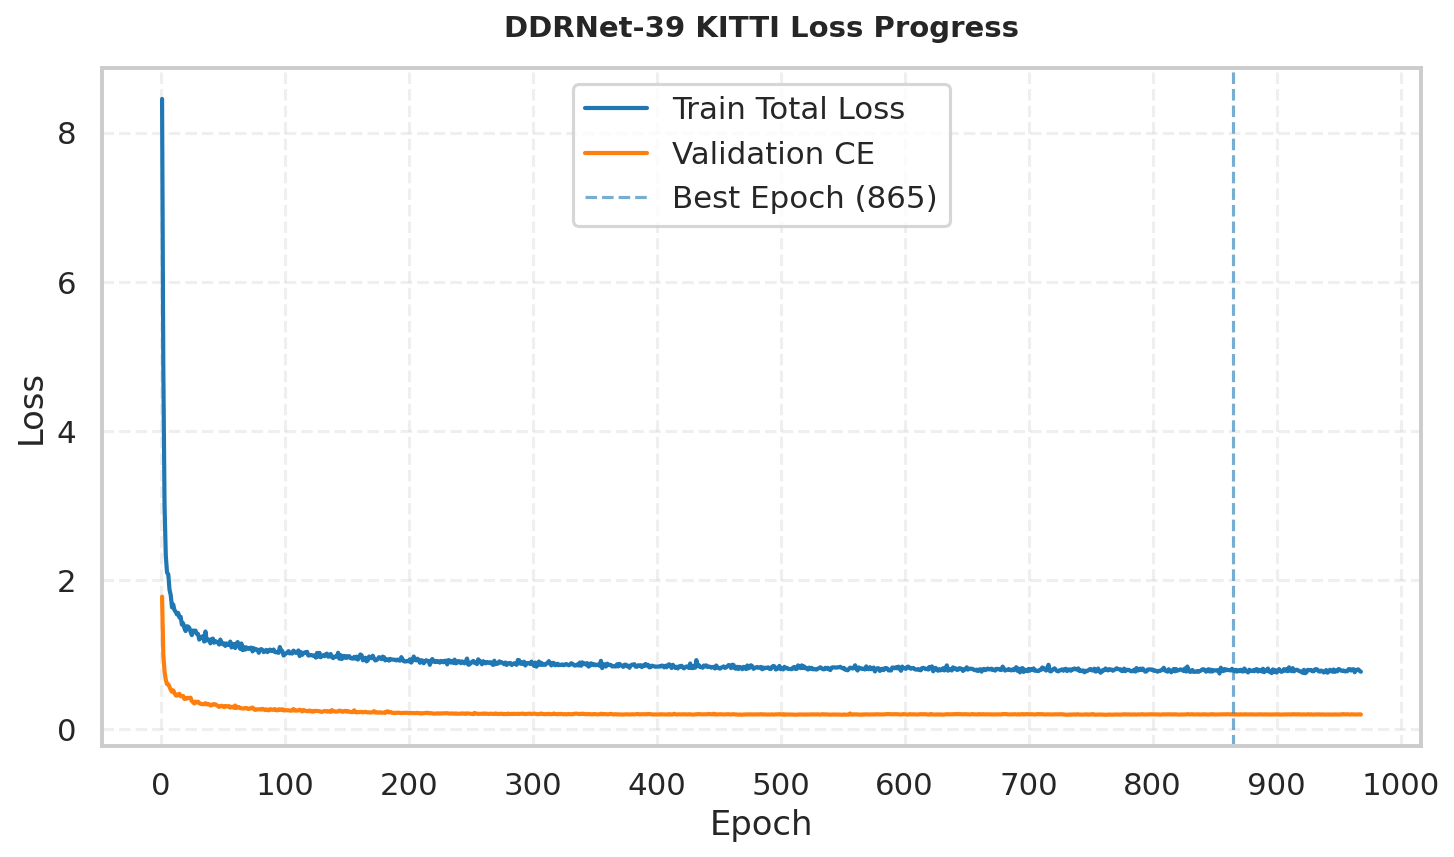

[✓] Saved: loss_comparison_DDRNet39_KITTI.png


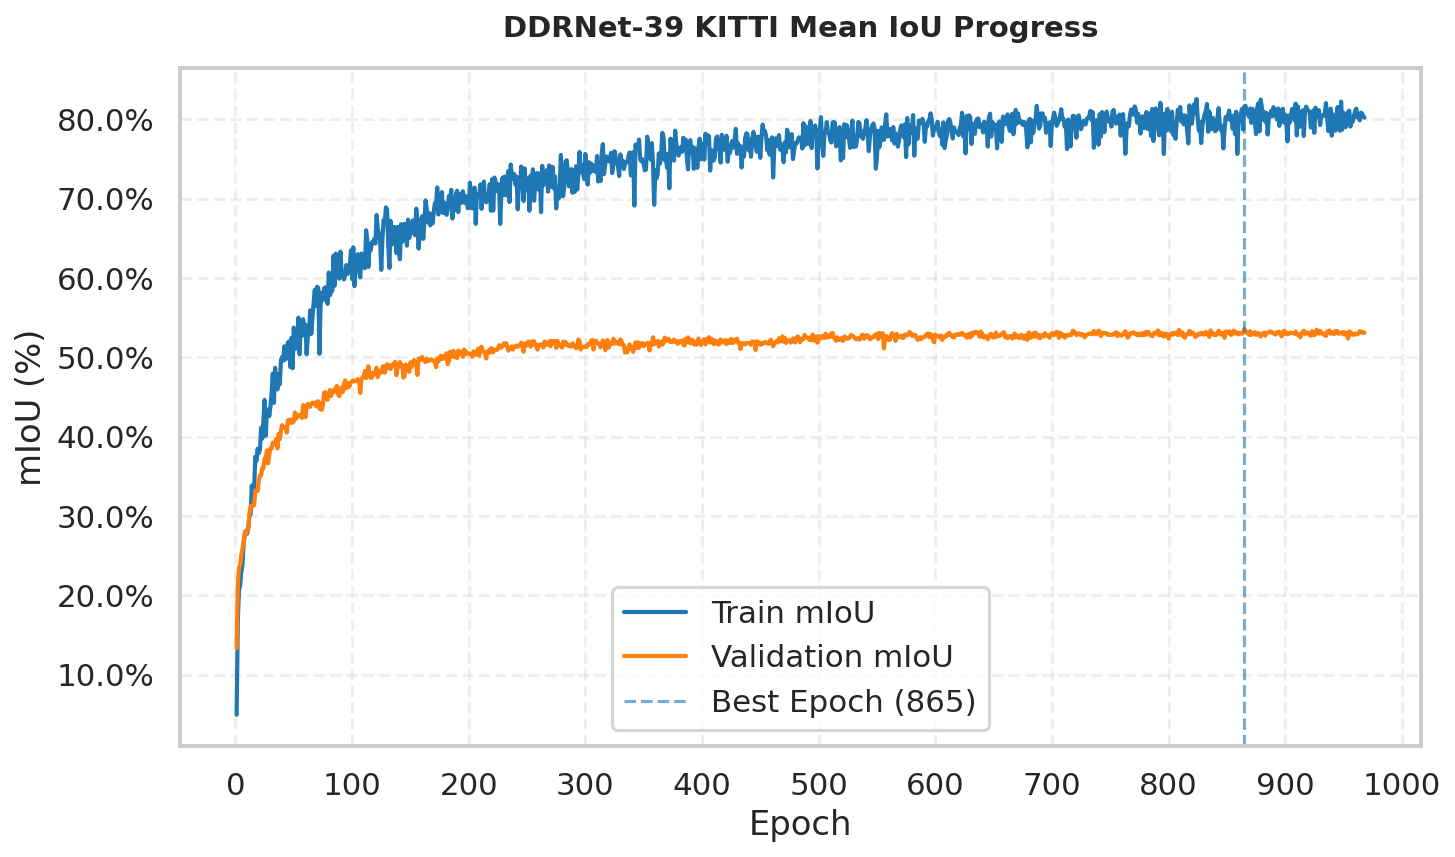

[✓] Saved: miou_progress_DDRNet39_KITTI.png


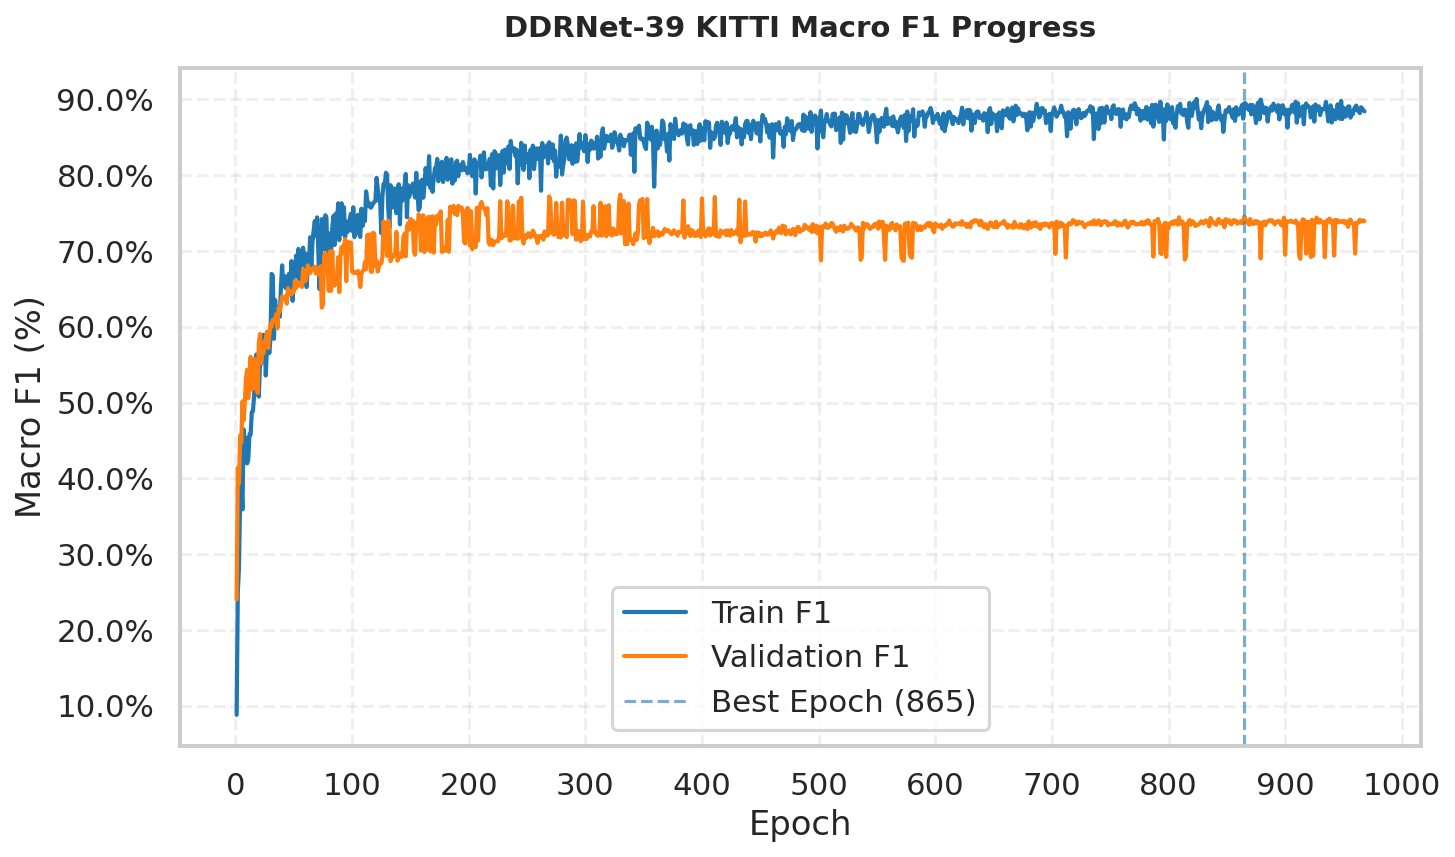

[✓] Saved: f1_progress_DDRNet39_KITTI.png


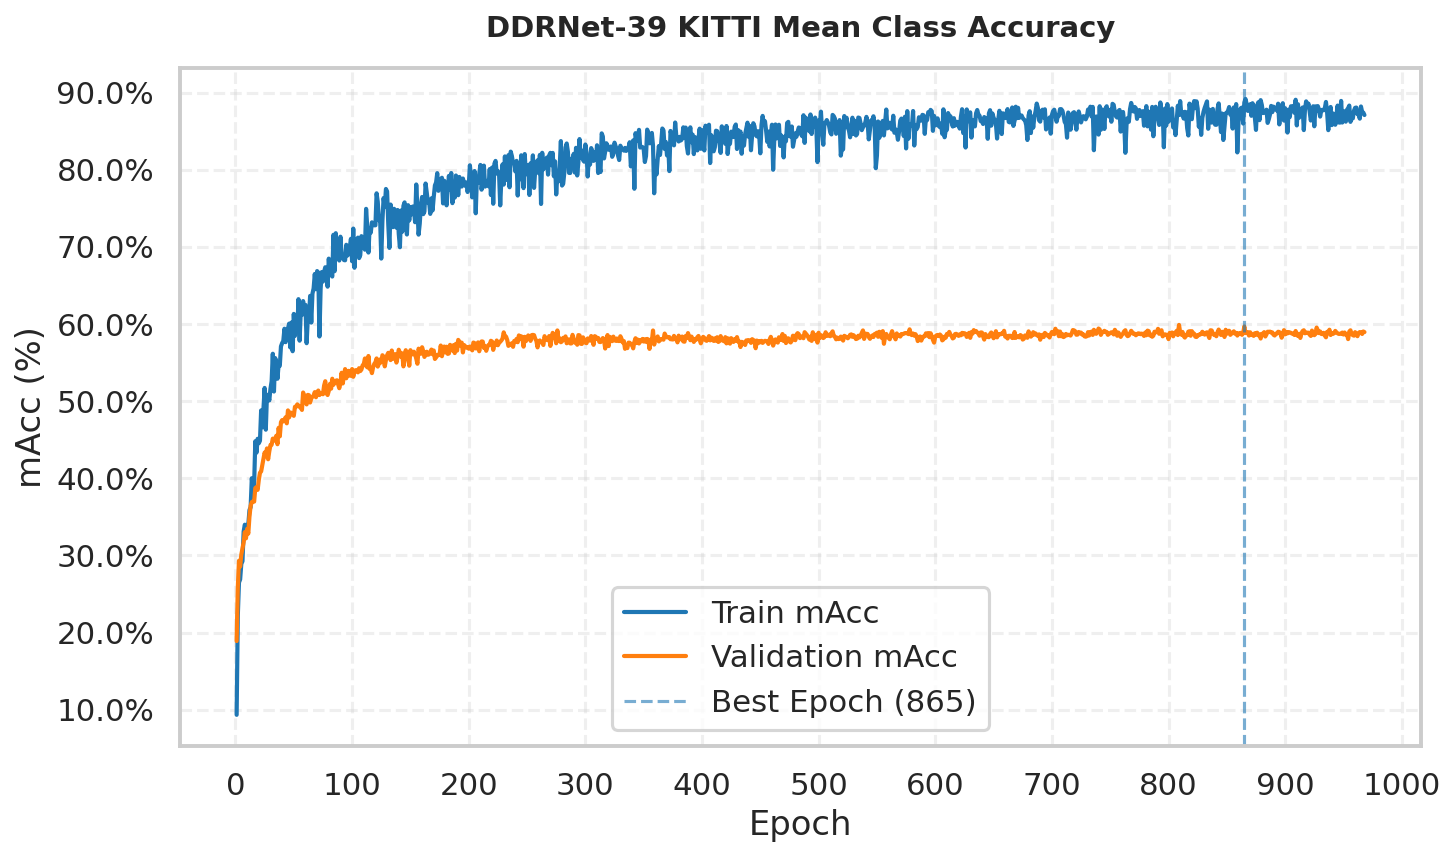

[✓] Saved: macc_progress_DDRNet39_KITTI.png


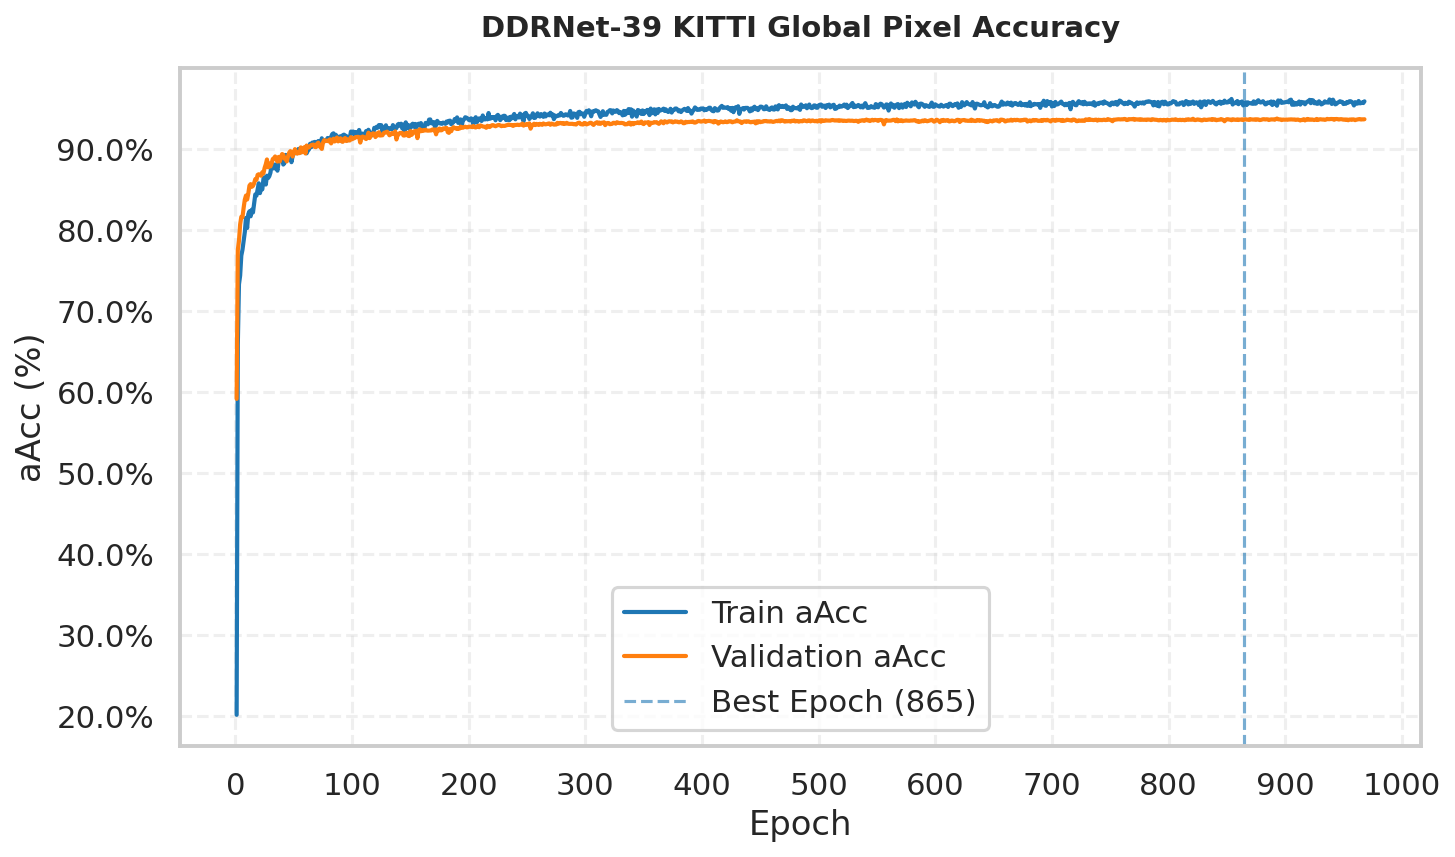

[✓] Saved: aacc_progress_DDRNet39_KITTI.png


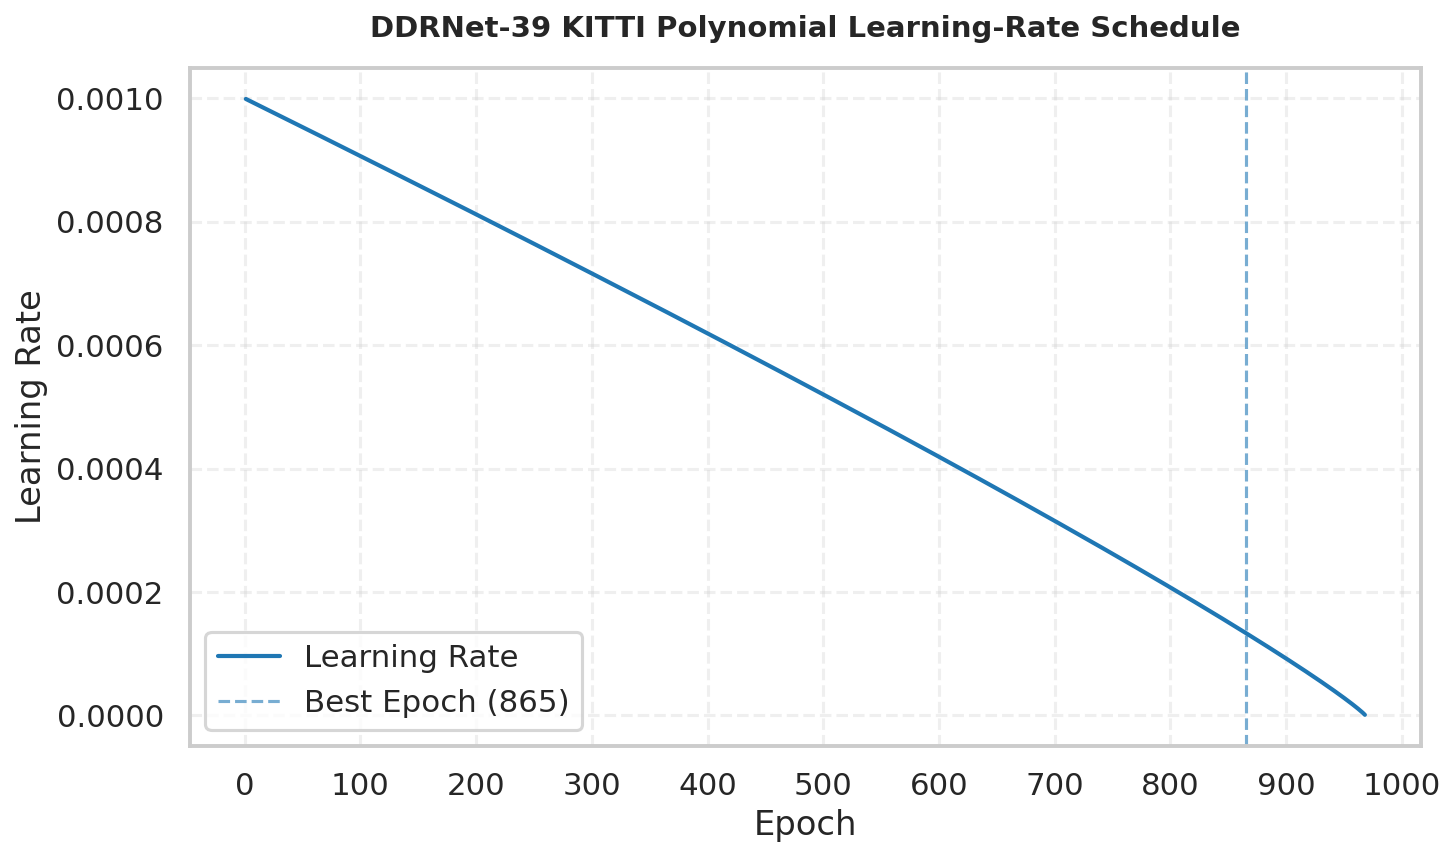

[✓] Saved: learning_rate_progress_DDRNet39_KITTI.png


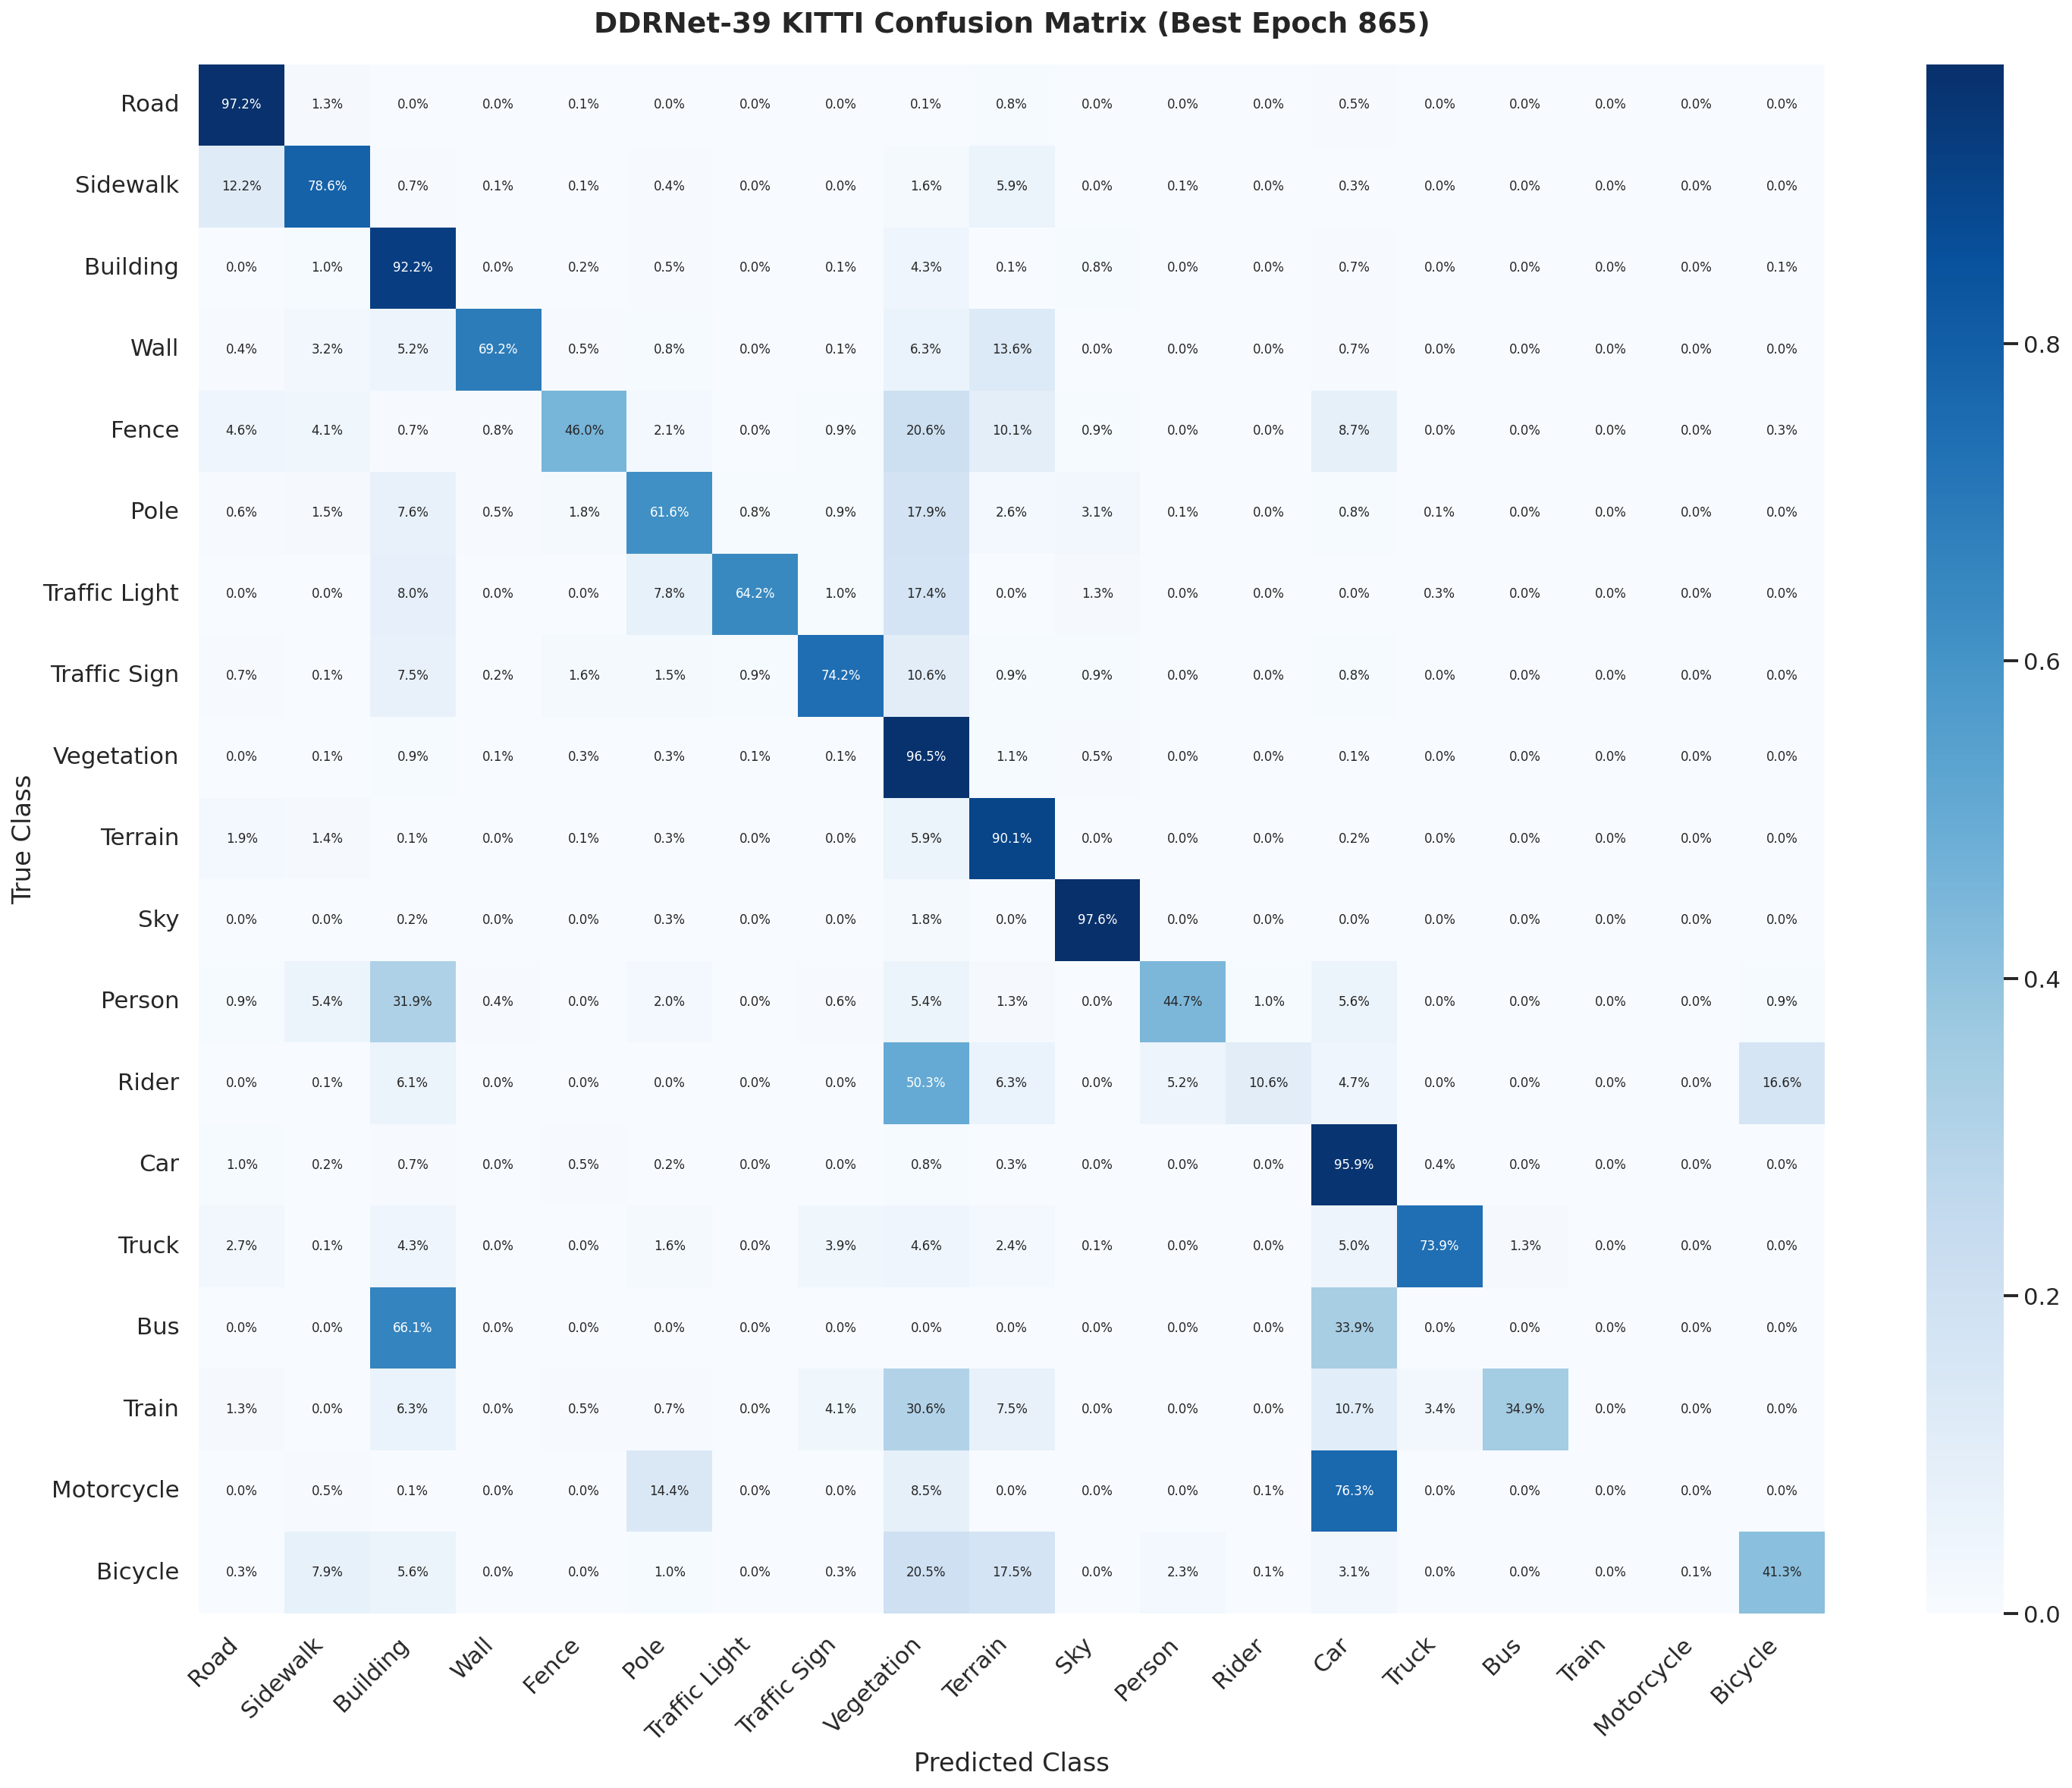

[✓] Saved: confusion_matrix_percentages_DDRNet39_KITTI.png

FINAL RESULTS — DDRNet-39 / KITTI
Architecture                    : DDRNet-39
Dataset                         : KITTI
Backbone                        : Deep Dual-Resolution Network
Context Module                  : DAPPM
Fusion                          : Bilateral Multi-Resolution Fusion
Training Loss                   : OHEM Main + 0.4 × Auxiliary CE
Training Sampling               : Class-balanced WeightedRandomSampler
Evaluation                      : Single-scale / no horizontal flip
Validation Loss                 : Valid-pixel-weighted Cross-Entropy
--------------------------------------------------------------------------------------------------
Training Parameters             : 32,660,838 (32.66 M)
Auxiliary Parameters            : 300,563 (0.30 M)
Inference Parameters            : 32,360,275 (32.36 M)
Trainable Parameters            : 32,660,838
-------------------------------------------------------------------------

In [7]:
# ============================================================
# STEP 6 — DDRNet-39 / KITTI
# BEST-CHECKPOINT RECONSTRUCTION, FINAL METRICS,
# CLASS-WISE ANALYSIS, CSV / EXCEL EXPORT,
# CONFUSION MATRIX, AND FINAL REPORTING
#
# Target Architecture:
# DDRNet-39
#
# Target Dataset:
# KITTI Semantic Segmentation — 19 Classes
#
# Evaluation Protocol:
#   - Reload BEST checkpoint from disk
#   - Deterministic validation split
#   - Single-scale inference
#   - No horizontal flip
#   - Main DDRNet output only
#   - Same protocol used for checkpoint selection
#
# Validation Loss:
#   - Standard Cross-Entropy
#   - Sum over valid semantic pixels
#   - Divide by total valid pixels
#
# Metrics:
#   - mIoU
#   - mAcc
#   - aAcc
#   - Macro Precision / Recall / F1
#   - Micro Precision / Recall / F1
#   - Per-class IoU / Precision / Recall / F1
#
# Exports:
#   - Full epoch history CSV
#   - Class-wise metrics CSV
#   - Global results CSV
#   - Confusion matrices CSV
#   - Complete Excel report
#   - 600-DPI plots
#
# Notebook Safety:
#   - tqdm leave=False
#   - Full 968-row history NOT displayed
#   - Only last MAX_NOTEBOOK_TABLE_ROWS shown
#   - 19-class table may be displayed once
#   - Final plots displayed once only if enabled
#
# No ONNX export.
# No new imports are required.
# ============================================================


# ============================================================
# 1. SAFETY CHECKS
# ============================================================

required_globals = [
    "history",
    "model",
    "CLASS_NAMES",
    "CLASSES",
    "best_record",
    "DEVICE",
    "FINAL_SAVE_DIR",
    "METRICS_DIR",
    "val_loader",
    "IGNORE_INDEX",
    "ALIGN_CORNERS",
    "USE_AMP",
    "single_scale_inference",
    "fast_confusion_matrix",
    "compute_metrics",
    "safe_cross_entropy_sum_and_count",
    "NOTEBOOK_SAFE_MODE",
    "TQDM_LEAVE",
    "DISPLAY_FINAL_REPORT_PLOTS",
    "MAX_NOTEBOOK_TABLE_ROWS",
    "EXPERIMENT_NAME",
    "TRAINING_PROTOCOL_NAME",
    "MODEL_NAME",
    "EPOCHS",
    "BASE_LR",
    "PHYSICAL_BATCH_SIZE",
    "GRAD_ACCUM_STEPS",
    "EFFECTIVE_BATCH_SIZE",
    "TRAIN_SAMPLING_MODE",
    "KITTI_MASK_ENCODING_MODE",
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise NameError(
        "Required variables/functions are missing. "
        "Run corrected Steps 1-5 first.\n"
        f"Missing: {missing_globals}"
    )


if CLASSES != 19:

    raise RuntimeError(
        "DDRNet-KITTI final evaluation expects "
        f"19 classes, found {CLASSES}."
    )


if len(CLASS_NAMES) != CLASSES:

    raise RuntimeError(
        "CLASS_NAMES length does not match CLASSES."
    )


if len(val_loader) == 0:

    raise RuntimeError(
        "Validation DataLoader is empty."
    )


if len(
    history.get(
        "epoch",
        []
    )
) == 0:

    raise RuntimeError(
        "Training history is empty."
    )


FINAL_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "[✓] Step 6 safety checks passed."
)


print(
    f"[*] Final export directory:\n"
    f"    {FINAL_SAVE_DIR.resolve()}"
)


# ============================================================
# 2. NOTEBOOK OUTPUT POLICY
# ============================================================

REPORT_TQDM_LEAVE = (
    False
    if NOTEBOOK_SAFE_MODE
    else bool(TQDM_LEAVE)
)


print(
    "\n--- Step 6 Notebook Policy ---"
)


print(
    f"[*] Notebook-safe mode        : "
    f"{NOTEBOOK_SAFE_MODE}"
)


print(
    f"[*] tqdm leave                : "
    f"{REPORT_TQDM_LEAVE}"
)


print(
    f"[*] Display final plots       : "
    f"{DISPLAY_FINAL_REPORT_PLOTS}"
)


print(
    f"[*] Maximum history rows shown: "
    f"{MAX_NOTEBOOK_TABLE_ROWS}"
)


# ============================================================
# 3. BEST CHECKPOINT LOCATION
# ============================================================

best_ckpt_path = Path(
    best_record[
        "best_path"
    ]
)


if not best_ckpt_path.exists():

    raise FileNotFoundError(
        "DDRNet-39 KITTI BEST checkpoint was not found.\n"
        f"Expected:\n{best_ckpt_path}"
    )


print(
    "\n--- Best DDRNet-39 KITTI Checkpoint ---"
)


print(
    f"[*] Path: "
    f"{best_ckpt_path}"
)


# ============================================================
# 4. LOAD BEST CHECKPOINT
# ============================================================

try:


    best_checkpoint = torch.load(
        best_ckpt_path,
        map_location=DEVICE,
        weights_only=False
    )


except TypeError:


    best_checkpoint = torch.load(
        best_ckpt_path,
        map_location=DEVICE
    )


# ============================================================
# 5. STRICT CHECKPOINT IDENTITY VERIFICATION
# ============================================================

checkpoint_experiment = str(
    best_checkpoint.get(
        "experiment_name",
        ""
    )
)


checkpoint_protocol = str(
    best_checkpoint.get(
        "training_protocol_name",
        ""
    )
)


checkpoint_dataset = str(
    best_checkpoint.get(
        "dataset_name",
        ""
    )
)


checkpoint_model = str(
    best_checkpoint.get(
        "model_name",
        ""
    )
)


checkpoint_classes = int(
    best_checkpoint.get(
        "num_classes",
        -1
    )
)


if checkpoint_experiment != EXPERIMENT_NAME:

    raise RuntimeError(
        "BEST checkpoint belongs to a different experiment.\n"
        f"Checkpoint : {checkpoint_experiment}\n"
        f"Current    : {EXPERIMENT_NAME}"
    )


if checkpoint_protocol != TRAINING_PROTOCOL_NAME:

    raise RuntimeError(
        "BEST checkpoint training protocol mismatch."
    )


if checkpoint_dataset.lower() != "kitti":

    raise RuntimeError(
        "BEST checkpoint is not a KITTI checkpoint."
    )


if checkpoint_model != MODEL_NAME:

    raise RuntimeError(
        "BEST checkpoint architecture mismatch."
    )


if checkpoint_classes != CLASSES:

    raise RuntimeError(
        "BEST checkpoint class-count mismatch."
    )


print(
    "[✓] Best-checkpoint identity verified."
)


# ============================================================
# 6. RECOVER BEST-EPOCH INFORMATION FROM CHECKPOINT
# ============================================================

checkpoint_best_record = (
    best_checkpoint.get(
        "best_record",
        {}
    )
)


best_epoch = int(
    checkpoint_best_record.get(
        "best_epoch",
        checkpoint_best_record.get(
            "epoch",
            best_checkpoint.get(
                "epoch",
                -1
            )
        )
    )
)


best_miou_record = float(
    checkpoint_best_record.get(
        "best_miou",
        best_record.get(
            "best_miou",
            -1.0
        )
    )
)


best_checkpoint_epoch = int(
    best_checkpoint.get(
        "epoch",
        best_epoch
    )
)


if (
    best_epoch > 0
    and best_checkpoint_epoch != best_epoch
):

    warnings.warn(
        "Best-record epoch and checkpoint epoch differ.\n"
        f"Best record : {best_epoch}\n"
        f"Checkpoint  : {best_checkpoint_epoch}"
    )


print(
    f"[*] Best epoch       : "
    f"{best_epoch}"
)


print(
    f"[*] Stored best mIoU : "
    f"{best_miou_record:.4f}%"
)


# ============================================================
# 7. LOAD BEST MODEL WEIGHTS
# ============================================================

model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print(
    "[✓] Best DDRNet-39 model weights loaded."
)


# ============================================================
# 8. RECONSTRUCT BEST VALIDATION RESULTS
# ============================================================
#
# Reconstruct from disk rather than using the confusion
# matrix remaining from the LAST epoch.
#
# Evaluation:
#
#       best checkpoint
#             ↓
#       single scale
#             ↓
#       no flip
#             ↓
#       main DDRNet logits
#             ↓
#       valid-pixel confusion matrix
#
# Also reconstruct:
#
#       total valid-pixel CE
#             ÷
#       total valid pixels
#
# exactly as corrected Step 5.
# ============================================================

print(
    "\n[*] Reconstructing best-checkpoint "
    "validation results..."
)


BEST_CONF_MATRIX = np.zeros(
    (
        CLASSES,
        CLASSES
    ),
    dtype=np.int64
)


BEST_VAL_CLASS_IMAGE_COUNTS = np.zeros(
    CLASSES,
    dtype=np.int64
)


best_val_loss_sum = 0.0


best_val_valid_pixels = 0


best_val_processed_images = 0


reconstruction_pbar = tqdm(
    val_loader,
    total=len(
        val_loader
    ),
    desc="Best KITTI Validation Reconstruction",
    leave=REPORT_TQDM_LEAVE,
    dynamic_ncols=True,
    mininterval=1.0
)


with torch.inference_mode():


    for reconstruction_step, (
        images,
        masks
    ) in enumerate(
        reconstruction_pbar,
        start=1
    ):


        images = images.to(
            DEVICE,
            non_blocking=True
        )


        masks = masks.to(
            DEVICE,
            non_blocking=True
        )


        # ====================================================
        # SINGLE-SCALE MAIN DDRNet OUTPUT
        # ====================================================

        semantic_logits = (
            single_scale_inference(
                model,
                images
            )
        )


        if not bool(
            torch.isfinite(
                semantic_logits
            )
            .all()
            .item()
        ):

            raise FloatingPointError(
                "Non-finite logits detected during "
                "best-checkpoint reconstruction.\n"
                f"Validation step: {reconstruction_step}"
            )


        # ====================================================
        # VALID-PIXEL-WEIGHTED VALIDATION LOSS
        # ====================================================

        (
            batch_loss_sum,
            batch_valid_pixels,
            semantic_logits
        ) = safe_cross_entropy_sum_and_count(
            semantic_logits.float(),
            masks,
            ignore_index=IGNORE_INDEX
        )


        if batch_valid_pixels <= 0:

            raise RuntimeError(
                "A validation sample contains zero valid "
                "semantic pixels during Step 6.\n"
                f"Validation step: {reconstruction_step}"
            )


        if not bool(
            torch.isfinite(
                batch_loss_sum
            )
            .item()
        ):

            raise FloatingPointError(
                "Non-finite validation CE detected during "
                "Step 6 reconstruction."
            )


        best_val_loss_sum += float(
            batch_loss_sum.item()
        )


        best_val_valid_pixels += int(
            batch_valid_pixels
        )


        # ====================================================
        # PREDICTION
        # ====================================================

        predictions = torch.argmax(
            semantic_logits,
            dim=1
        )


        predictions_np = (
            predictions
            .cpu()
            .numpy()
            .astype(
                np.int64,
                copy=False
            )
        )


        targets_np = (
            masks
            .cpu()
            .numpy()
            .astype(
                np.int64,
                copy=False
            )
        )


        valid = (
            targets_np
            != IGNORE_INDEX
        )


        if valid.any():


            BEST_CONF_MATRIX += (
                fast_confusion_matrix(
                    targets_np[
                        valid
                    ],
                    predictions_np[
                        valid
                    ],
                    CLASSES
                )
            )


        # ====================================================
        # CLASS IMAGE SUPPORT
        # ====================================================

        for sample_index in range(
            targets_np.shape[0]
        ):


            sample_target = (
                targets_np[
                    sample_index
                ]
            )


            sample_valid = (
                sample_target
                != IGNORE_INDEX
            )


            if sample_valid.any():


                present_classes = np.unique(
                    sample_target[
                        sample_valid
                    ]
                )


                for class_id in present_classes:


                    if (
                        0
                        <= int(
                            class_id
                        )
                        < CLASSES
                    ):


                        BEST_VAL_CLASS_IMAGE_COUNTS[
                            int(
                                class_id
                            )
                        ] += 1


            best_val_processed_images += 1


reconstruction_pbar.close()


# ============================================================
# 9. FINAL RECONSTRUCTED VALIDATION LOSS
# ============================================================

if best_val_valid_pixels <= 0:

    raise RuntimeError(
        "No valid KITTI pixels were evaluated."
    )


reconstructed_best_val_loss = (
    best_val_loss_sum
    / float(
        best_val_valid_pixels
    )
)


if not np.isfinite(
    reconstructed_best_val_loss
):

    raise FloatingPointError(
        "Reconstructed validation loss is non-finite."
    )


print(
    "[✓] Best-checkpoint validation reconstruction complete."
)


print(
    f"[*] Validation images evaluated : "
    f"{best_val_processed_images}"
)


print(
    f"[*] Valid pixels evaluated      : "
    f"{best_val_valid_pixels:,}"
)


print(
    f"[*] Reconstructed Val Loss      : "
    f"{reconstructed_best_val_loss:.6f}"
)


# ============================================================
# 10. GLOBAL METRICS FROM BEST CONFUSION MATRIX
# ============================================================

BEST_METRICS = compute_metrics(
    BEST_CONF_MATRIX
)


reconstructed_best_miou = (
    BEST_METRICS[
        "mIoU_Macro"
    ]
    * 100.0
)


reconstructed_best_macc = (
    BEST_METRICS[
        "Recall_Macro"
    ]
    * 100.0
)


reconstructed_best_aacc = (
    BEST_METRICS[
        "Global_Accuracy"
    ]
    * 100.0
)


reconstructed_best_f1 = (
    BEST_METRICS[
        "F1_Macro"
    ]
    * 100.0
)


reconstructed_best_precision = (
    BEST_METRICS[
        "Precision_Macro"
    ]
    * 100.0
)


reconstructed_best_micro_f1 = (
    BEST_METRICS[
        "F1_Micro"
    ]
    * 100.0
)


# ============================================================
# 11. BEST-CHECKPOINT METRIC CONSISTENCY CHECK
# ============================================================

miou_difference = abs(
    best_miou_record
    - reconstructed_best_miou
)


print(
    "\n--- Best Checkpoint Verification ---"
)


print(
    f"Stored best mIoU        : "
    f"{best_miou_record:.4f}%"
)


print(
    f"Reconstructed best mIoU : "
    f"{reconstructed_best_miou:.4f}%"
)


print(
    f"Absolute difference     : "
    f"{miou_difference:.6f} percentage points"
)


BEST_RECONSTRUCTION_TOLERANCE_PP = 0.10


if (
    miou_difference
    > BEST_RECONSTRUCTION_TOLERANCE_PP
):

    raise RuntimeError(
        "Best-checkpoint reconstruction differs from the "
        "stored validation mIoU by more than "
        f"{BEST_RECONSTRUCTION_TOLERANCE_PP:.2f} "
        "percentage points.\n\n"
        "This usually indicates that the validation pipeline "
        "or split changed after training."
    )


print(
    "[✓] Stored and reconstructed best mIoU are consistent."
)


# ============================================================
# 12. COMPLETE EPOCH-WISE DATAFRAME
# ============================================================

num_epochs = len(
    history[
        "epoch"
    ]
)


def get_hist_col(
    key
):
    """
    Return a history column with exactly num_epochs rows.
    """

    values = list(
        history.get(
            key,
            []
        )
    )


    if len(values) > num_epochs:


        return values[
            :num_epochs
        ]


    if len(values) < num_epochs:


        values.extend(
            [np.nan]
            * (
                num_epochs
                - len(values)
            )
        )


    return values


epoch_metrics_df = pd.DataFrame(
    {
        "Epoch":
            get_hist_col(
                "epoch"
            ),

        "Phase":
            get_hist_col(
                "phase"
            ),

        "Train_Total_Loss":
            get_hist_col(
                "train_total_loss"
            ),

        "Train_Main_OHEM_Loss":
            get_hist_col(
                "train_main_loss"
            ),

        "Train_Aux_Loss":
            get_hist_col(
                "train_aux_loss"
            ),

        "Validation_Loss":
            get_hist_col(
                "val_total_loss"
            ),

        "Train_mIoU":
            get_hist_col(
                "train_miou"
            ),

        "Validation_mIoU":
            get_hist_col(
                "val_miou"
            ),

        "Train_mAcc":
            get_hist_col(
                "train_macc"
            ),

        "Validation_mAcc":
            get_hist_col(
                "val_macc"
            ),

        "Train_aAcc":
            get_hist_col(
                "train_aacc"
            ),

        "Validation_aAcc":
            get_hist_col(
                "val_aacc"
            ),

        "Train_Precision_Macro":
            get_hist_col(
                "train_Precision_Macro"
            ),

        "Validation_Precision_Macro":
            get_hist_col(
                "val_Precision_Macro"
            ),

        "Train_Recall_Macro":
            get_hist_col(
                "train_Recall_Macro"
            ),

        "Validation_Recall_Macro":
            get_hist_col(
                "val_Recall_Macro"
            ),

        "Train_F1_Macro":
            get_hist_col(
                "train_F1_Macro"
            ),

        "Validation_F1_Macro":
            get_hist_col(
                "val_F1_Macro"
            ),

        "Train_Precision_Micro":
            get_hist_col(
                "train_Precision_Micro"
            ),

        "Validation_Precision_Micro":
            get_hist_col(
                "val_Precision_Micro"
            ),

        "Train_Recall_Micro":
            get_hist_col(
                "train_Recall_Micro"
            ),

        "Validation_Recall_Micro":
            get_hist_col(
                "val_Recall_Micro"
            ),

        "Train_F1_Micro":
            get_hist_col(
                "train_F1_Micro"
            ),

        "Validation_F1_Micro":
            get_hist_col(
                "val_F1_Micro"
            ),

        "Learning_Rate":
            get_hist_col(
                "learning_rate"
            ),

        "Epoch_Time_sec":
            get_hist_col(
                "epoch_time_sec"
            ),

        "Cumulative_Training_Time":
            get_hist_col(
                "total_training_time_str"
            ),
    }
)


# ============================================================
# 13. BEST HISTORY ROW
# ============================================================

best_history_rows = epoch_metrics_df[
    epoch_metrics_df[
        "Epoch"
    ]
    == best_epoch
]


if len(
    best_history_rows
) == 1:


    best_history_row = (
        best_history_rows.iloc[
            0
        ]
    )


    stored_best_val_loss = float(
        best_history_row[
            "Validation_Loss"
        ]
    )


    stored_history_best_miou = float(
        best_history_row[
            "Validation_mIoU"
        ]
    )


else:


    best_history_row = None


    stored_best_val_loss = np.nan


    stored_history_best_miou = np.nan


print(
    "\n--- Best Epoch History Verification ---"
)


print(
    f"[*] Stored history mIoU : "
    f"{stored_history_best_miou:.4f}%"
)


print(
    f"[*] Stored history loss : "
    f"{stored_best_val_loss:.6f}"
)


print(
    f"[*] Rebuilt loss        : "
    f"{reconstructed_best_val_loss:.6f}"
)


# ============================================================
# 14. TOTAL TRAINING TIME
# ============================================================

if (
    "cumulative_training_time_sec"
    in globals()
):


    total_training_time_sec = float(
        cumulative_training_time_sec
    )


else:


    total_training_time_sec = float(
        np.nansum(
            epoch_metrics_df[
                "Epoch_Time_sec"
            ]
            .to_numpy(
                dtype=np.float64
            )
        )
    )


total_time_str = str(
    datetime.timedelta(
        seconds=int(
            total_training_time_sec
        )
    )
)


# ============================================================
# 15. CLASS-WISE METRICS
# ============================================================
#
# Reuse the definitions from corrected Step 5.
#
# NaN is retained when a metric is mathematically undefined
# for a class rather than silently replacing it with zero.
# ============================================================

iou_per_class = np.asarray(
    BEST_METRICS[
        "Class_IoU"
    ],
    dtype=np.float64
)


precision_per_class = np.asarray(
    BEST_METRICS[
        "Class_Precision"
    ],
    dtype=np.float64
)


recall_per_class = np.asarray(
    BEST_METRICS[
        "Class_Accuracy"
    ],
    dtype=np.float64
)


f1_per_class = np.asarray(
    BEST_METRICS[
        "Class_F1"
    ],
    dtype=np.float64
)


gt_pixel_counts = (
    BEST_CONF_MATRIX.sum(
        axis=1
    )
)


prediction_pixel_counts = (
    BEST_CONF_MATRIX.sum(
        axis=0
    )
)


class_wise_df = pd.DataFrame(
    {
        "Class ID":
            np.arange(
                CLASSES
            ),

        "Class Name":
            CLASS_NAMES,

        "Validation Images":
            BEST_VAL_CLASS_IMAGE_COUNTS,

        "GT Pixels":
            gt_pixel_counts,

        "Predicted Pixels":
            prediction_pixel_counts,

        "IoU (%)":
            iou_per_class
            * 100.0,

        "F1-Score (%)":
            f1_per_class
            * 100.0,

        "Precision (%)":
            precision_per_class
            * 100.0,

        "Recall / Class Accuracy (%)":
            recall_per_class
            * 100.0,
    }
)


# ============================================================
# 16. RAW CONFUSION MATRIX
# ============================================================

confusion_matrix_counts_df = pd.DataFrame(
    BEST_CONF_MATRIX,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


# ============================================================
# 17. ROW-NORMALIZED CONFUSION MATRIX
# ============================================================

row_sums = BEST_CONF_MATRIX.sum(
    axis=1,
    keepdims=True
)


confusion_matrix_percent = np.divide(
    BEST_CONF_MATRIX.astype(
        np.float64
    ),
    row_sums,
    out=np.zeros_like(
        BEST_CONF_MATRIX,
        dtype=np.float64
    ),
    where=(
        row_sums > 0
    )
) * 100.0


confusion_matrix_percent_df = pd.DataFrame(
    confusion_matrix_percent,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


# ============================================================
# 18. GLOBAL FINAL RESULTS
# ============================================================

successful_updates = int(
    best_checkpoint.get(
        "global_update_step",
        -1
    )
)


amp_skipped_updates = int(
    best_checkpoint.get(
        "amp_skipped_updates",
        0
    )
)


final_global_results_df = pd.DataFrame(
    [
        {
            "Metric":
                "Best Validation mIoU (Macro)",

            "Value":
                f"{reconstructed_best_miou:.2f}%"
        },

        {
            "Metric":
                "Best Validation mAcc (Macro Recall)",

            "Value":
                f"{reconstructed_best_macc:.2f}%"
        },

        {
            "Metric":
                "Best Validation aAcc (Global Pixel Accuracy)",

            "Value":
                f"{reconstructed_best_aacc:.2f}%"
        },

        {
            "Metric":
                "Best Validation Macro F1",

            "Value":
                f"{reconstructed_best_f1:.2f}%"
        },

        {
            "Metric":
                "Best Validation Macro Precision",

            "Value":
                f"{reconstructed_best_precision:.2f}%"
        },

        {
            "Metric":
                "Best Validation Micro F1",

            "Value":
                f"{reconstructed_best_micro_f1:.2f}%"
        },

        {
            "Metric":
                "Best Validation Loss",

            "Value":
                f"{reconstructed_best_val_loss:.6f}"
        },

        {
            "Metric":
                "Best Epoch",

            "Value":
                str(
                    best_epoch
                )
        },

        {
            "Metric":
                "Training Epoch Schedule",

            "Value":
                str(
                    EPOCHS
                )
        },

        {
            "Metric":
                "Initial Learning Rate",

            "Value":
                str(
                    BASE_LR
                )
        },

        {
            "Metric":
                "Physical Batch Size",

            "Value":
                str(
                    PHYSICAL_BATCH_SIZE
                )
        },

        {
            "Metric":
                "Gradient Accumulation",

            "Value":
                str(
                    GRAD_ACCUM_STEPS
                )
        },

        {
            "Metric":
                "Effective Batch Size",

            "Value":
                str(
                    EFFECTIVE_BATCH_SIZE
                )
        },

        {
            "Metric":
                "Training Sampling",

            "Value":
                TRAIN_SAMPLING_MODE
        },

        {
            "Metric":
                "Validation Protocol",

            "Value":
                "Single-scale, no horizontal flip"
        },

        {
            "Metric":
                "Mask Encoding",

            "Value":
                KITTI_MASK_ENCODING_MODE
        },

        {
            "Metric":
                "Successful Updates at Best Epoch",

            "Value":
                str(
                    successful_updates
                )
        },

        {
            "Metric":
                "AMP Skipped Updates at Best Epoch",

            "Value":
                str(
                    amp_skipped_updates
                )
        },

        {
            "Metric":
                "Total Training Time",

            "Value":
                total_time_str
        },
    ]
)


# ============================================================
# 19. OUTPUT PATHS
# ============================================================

epoch_csv_path = (
    FINAL_SAVE_DIR
    / "epoch_metrics_DDRNet39_KITTI.csv"
)


class_csv_path = (
    FINAL_SAVE_DIR
    / "classwise_metrics_DDRNet39_KITTI.csv"
)


final_csv_path = (
    FINAL_SAVE_DIR
    / "finalresults_DDRNet39_KITTI.csv"
)


cm_counts_csv_path = (
    FINAL_SAVE_DIR
    / "confusion_matrix_counts_DDRNet39_KITTI.csv"
)


cm_percent_csv_path = (
    FINAL_SAVE_DIR
    / "confusion_matrix_percent_DDRNet39_KITTI.csv"
)


# ============================================================
# 20. SAVE CSV FILES
# ============================================================

epoch_metrics_df.to_csv(
    epoch_csv_path,
    index=False
)


class_wise_df.to_csv(
    class_csv_path,
    index=False
)


final_global_results_df.to_csv(
    final_csv_path,
    index=False
)


confusion_matrix_counts_df.to_csv(
    cm_counts_csv_path
)


confusion_matrix_percent_df.to_csv(
    cm_percent_csv_path
)


print(
    "\n[✓] Final CSV reports saved."
)


# ============================================================
# 21. SAVE COMPLETE EXCEL REPORT
# ============================================================

excel_path = (
    FINAL_SAVE_DIR
    / "Training_Metrics_Report_DDRNet39_KITTI.xlsx"
)


excel_saved = False


try:


    with pd.ExcelWriter(
        excel_path,
        engine="openpyxl"
    ) as writer:


        epoch_metrics_df.to_excel(
            writer,
            sheet_name="Epoch_Metrics",
            index=False
        )


        final_global_results_df.to_excel(
            writer,
            sheet_name="Final_Results",
            index=False
        )


        class_wise_df.to_excel(
            writer,
            sheet_name="Class_Wise_Results",
            index=False
        )


        confusion_matrix_counts_df.to_excel(
            writer,
            sheet_name="Confusion_Counts"
        )


        confusion_matrix_percent_df.to_excel(
            writer,
            sheet_name="Confusion_Percent"
        )


        # Optional Step-3 audit information.
        if (
            "class_distribution_df"
            in globals()
        ):


            class_distribution_df.to_excel(
                writer,
                sheet_name="Dataset_Class_Distribution",
                index=False
            )


        if (
            "split_manifest_df"
            in globals()
        ):


            split_manifest_df.to_excel(
                writer,
                sheet_name="Train_Val_Split",
                index=False
            )


    excel_saved = True


    print(
        f"[✓] Excel report saved:\n"
        f"    {excel_path}"
    )


except Exception as excel_error:


    warnings.warn(
        "Excel report could not be created. "
        "CSV files remain available.\n"
        f"Reason: {excel_error}"
    )


# ============================================================
# 22. COMPACT JUPYTER TABLE DISPLAY
# ============================================================
#
# Do NOT display all 968 epoch rows.
# ============================================================

print(
    "\n"
    + "=" * 88
)


print(
    "FINAL DDRNet-39 / KITTI GLOBAL RESULTS"
)


print(
    "=" * 88
)


display(
    final_global_results_df
)


print(
    "\n"
    + "=" * 88
)


print(
    "DDRNet-39 / KITTI CLASS-WISE RESULTS"
)


print(
    "=" * 88
)


display(
    class_wise_df.style.format(
        {
            "IoU (%)":
                "{:.2f}",

            "F1-Score (%)":
                "{:.2f}",

            "Precision (%)":
                "{:.2f}",

            "Recall / Class Accuracy (%)":
                "{:.2f}",

            "GT Pixels":
                "{:,}",

            "Predicted Pixels":
                "{:,}",
        },
        na_rep="N/A"
    )
)


# ============================================================
# DISPLAY ONLY THE LAST N HISTORY ROWS
# ============================================================

history_rows_to_show = min(
    MAX_NOTEBOOK_TABLE_ROWS,
    len(
        epoch_metrics_df
    )
)


print(
    "\n"
    + "=" * 88
)


print(
    f"LAST {history_rows_to_show} EPOCHS "
    "OF TRAINING HISTORY"
)


print(
    "=" * 88
)


display(
    epoch_metrics_df.tail(
        history_rows_to_show
    )
)


print(
    f"\n[*] Full {len(epoch_metrics_df)}-epoch history "
    "was exported to CSV/Excel and was not fully "
    "embedded into the notebook."
)


# ============================================================
# 23. FINAL-PLOT HELPER
# ============================================================
#
# Plots are always SAVED at 600 DPI.
#
# They are displayed exactly once only when:
#
#       DISPLAY_FINAL_REPORT_PLOTS = True
# ============================================================

def save_final_plot(
    filename,
    title,
    ylabel,
    train_data,
    val_data=None,
    label1="Train",
    label2="Validation",
    is_percentage=False,
    mark_best_epoch=True
):


    fig, ax = plt.subplots(
        figsize=(
            10,
            6
        )
    )


    epochs_range = (
        epoch_metrics_df[
            "Epoch"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )


    train_clean = np.asarray(
        train_data,
        dtype=np.float64
    )


    if not np.isnan(
        train_clean
    ).all():


        ax.plot(
            epochs_range,
            train_clean,
            label=label1,
            linewidth=2
        )


    if val_data is not None:


        val_clean = np.asarray(
            val_data,
            dtype=np.float64
        )


        if not np.isnan(
            val_clean
        ).all():


            ax.plot(
                epochs_range,
                val_clean,
                label=label2,
                linewidth=2
            )


    if (
        mark_best_epoch
        and best_epoch > 0
    ):


        ax.axvline(
            best_epoch,
            linestyle="--",
            linewidth=1.5,
            alpha=0.6,
            label=f"Best Epoch ({best_epoch})"
        )


    if is_percentage:


        ax.yaxis.set_major_formatter(
            mtick.PercentFormatter(
                decimals=1
            )
        )


    ax.xaxis.set_major_locator(
        mtick.MaxNLocator(
            integer=True,
            nbins=12
        )
    )


    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=15
    )


    ax.set_xlabel(
        "Epoch"
    )


    ax.set_ylabel(
        ylabel
    )


    ax.grid(
        True,
        alpha=0.3,
        linestyle="--"
    )


    ax.legend()


    fig.tight_layout()


    output_path = (
        FINAL_SAVE_DIR
        / f"{filename}.png"
    )


    fig.savefig(
        output_path,
        dpi=600,
        bbox_inches="tight"
    )


    if DISPLAY_FINAL_REPORT_PLOTS:


        plt.show()


    plt.close(
        fig
    )


    print(
        f"[✓] Saved: "
        f"{output_path.name}"
    )


    return output_path


# ============================================================
# 24. EXTRACT PLOT SERIES
# ============================================================

train_total_loss_series = (
    epoch_metrics_df[
        "Train_Total_Loss"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


val_total_loss_series = (
    epoch_metrics_df[
        "Validation_Loss"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


train_miou_series = (
    epoch_metrics_df[
        "Train_mIoU"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


val_miou_series = (
    epoch_metrics_df[
        "Validation_mIoU"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


train_f1_series = (
    epoch_metrics_df[
        "Train_F1_Macro"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


val_f1_series = (
    epoch_metrics_df[
        "Validation_F1_Macro"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


train_macc_series = (
    epoch_metrics_df[
        "Train_mAcc"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


val_macc_series = (
    epoch_metrics_df[
        "Validation_mAcc"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


train_aacc_series = (
    epoch_metrics_df[
        "Train_aAcc"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


val_aacc_series = (
    epoch_metrics_df[
        "Validation_aAcc"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


learning_rate_series = (
    epoch_metrics_df[
        "Learning_Rate"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


# ============================================================
# 25. LOSS PLOT
# ============================================================

loss_plot_path = save_final_plot(
    filename="loss_comparison_DDRNet39_KITTI",
    title="DDRNet-39 KITTI Loss Progress",
    ylabel="Loss",
    train_data=train_total_loss_series,
    val_data=val_total_loss_series,
    label1="Train Total Loss",
    label2="Validation CE"
)


# ============================================================
# 26. mIoU PLOT
# ============================================================

miou_plot_path = save_final_plot(
    filename="miou_progress_DDRNet39_KITTI",
    title="DDRNet-39 KITTI Mean IoU Progress",
    ylabel="mIoU (%)",
    train_data=train_miou_series,
    val_data=val_miou_series,
    label1="Train mIoU",
    label2="Validation mIoU",
    is_percentage=True
)


# ============================================================
# 27. MACRO F1 PLOT
# ============================================================

f1_plot_path = save_final_plot(
    filename="f1_progress_DDRNet39_KITTI",
    title="DDRNet-39 KITTI Macro F1 Progress",
    ylabel="Macro F1 (%)",
    train_data=train_f1_series,
    val_data=val_f1_series,
    label1="Train F1",
    label2="Validation F1",
    is_percentage=True
)


# ============================================================
# 28. mAcc PLOT
# ============================================================

macc_plot_path = save_final_plot(
    filename="macc_progress_DDRNet39_KITTI",
    title="DDRNet-39 KITTI Mean Class Accuracy",
    ylabel="mAcc (%)",
    train_data=train_macc_series,
    val_data=val_macc_series,
    label1="Train mAcc",
    label2="Validation mAcc",
    is_percentage=True
)


# ============================================================
# 29. aAcc PLOT
# ============================================================

aacc_plot_path = save_final_plot(
    filename="aacc_progress_DDRNet39_KITTI",
    title="DDRNet-39 KITTI Global Pixel Accuracy",
    ylabel="aAcc (%)",
    train_data=train_aacc_series,
    val_data=val_aacc_series,
    label1="Train aAcc",
    label2="Validation aAcc",
    is_percentage=True
)


# ============================================================
# 30. POLYNOMIAL LR PLOT
# ============================================================

lr_plot_path = save_final_plot(
    filename="learning_rate_progress_DDRNet39_KITTI",
    title="DDRNet-39 KITTI Polynomial Learning-Rate Schedule",
    ylabel="Learning Rate",
    train_data=learning_rate_series,
    val_data=None,
    label1="Learning Rate",
    mark_best_epoch=True
)


# ============================================================
# 31. NORMALIZED CONFUSION-MATRIX HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        20,
        16
    )
)


sns.heatmap(
    confusion_matrix_percent / 100.0,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={
        "size":
            8
    },
    ax=ax
)


ax.set_title(
    (
        "DDRNet-39 KITTI Confusion Matrix "
        f"(Best Epoch {best_epoch})"
    ),
    fontsize=18,
    fontweight="bold",
    pad=20
)


ax.set_ylabel(
    "True Class"
)


ax.set_xlabel(
    "Predicted Class"
)


ax.tick_params(
    axis="x",
    rotation=45
)


for tick_label in ax.get_xticklabels():

    tick_label.set_horizontalalignment(
        "right"
    )


fig.tight_layout()


confusion_matrix_plot_path = (
    FINAL_SAVE_DIR
    / "confusion_matrix_percentages_DDRNet39_KITTI.png"
)


fig.savefig(
    confusion_matrix_plot_path,
    dpi=600,
    bbox_inches="tight"
)


if DISPLAY_FINAL_REPORT_PLOTS:


    plt.show()


plt.close(
    fig
)


print(
    f"[✓] Saved: "
    f"{confusion_matrix_plot_path.name}"
)


# ============================================================
# 32. MODEL PARAMETER SUMMARY
# ============================================================

training_total_params = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)


trainable_params = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


if hasattr(
    model,
    "seghead_extra"
):


    auxiliary_params = sum(
        parameter.numel()
        for parameter
        in model.seghead_extra.parameters()
    )


else:


    auxiliary_params = 0


inference_params = (
    training_total_params
    - auxiliary_params
)


# ============================================================
# 33. FINAL TEXT SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 98
)


print(
    "FINAL RESULTS — DDRNet-39 / KITTI"
)


print(
    "=" * 98
)


print(
    f"Architecture                    : "
    "DDRNet-39"
)


print(
    f"Dataset                         : "
    "KITTI"
)


print(
    f"Backbone                        : "
    "Deep Dual-Resolution Network"
)


print(
    f"Context Module                  : "
    "DAPPM"
)


print(
    f"Fusion                          : "
    "Bilateral Multi-Resolution Fusion"
)


print(
    f"Training Loss                   : "
    "OHEM Main + 0.4 × Auxiliary CE"
)


print(
    f"Training Sampling               : "
    f"{TRAIN_SAMPLING_MODE}"
)


print(
    f"Evaluation                      : "
    "Single-scale / no horizontal flip"
)


print(
    f"Validation Loss                 : "
    "Valid-pixel-weighted Cross-Entropy"
)


print(
    "-" * 98
)


print(
    f"Training Parameters             : "
    f"{training_total_params:,} "
    f"({training_total_params / 1e6:.2f} M)"
)


print(
    f"Auxiliary Parameters            : "
    f"{auxiliary_params:,} "
    f"({auxiliary_params / 1e6:.2f} M)"
)


print(
    f"Inference Parameters            : "
    f"{inference_params:,} "
    f"({inference_params / 1e6:.2f} M)"
)


print(
    f"Trainable Parameters            : "
    f"{trainable_params:,}"
)


print(
    "-" * 98
)


print(
    f"Best Validation mIoU            : "
    f"{reconstructed_best_miou:.2f}% "
    f"(Epoch {best_epoch})"
)


print(
    f"Best Validation mAcc            : "
    f"{reconstructed_best_macc:.2f}%"
)


print(
    f"Best Validation aAcc            : "
    f"{reconstructed_best_aacc:.2f}%"
)


print(
    f"Best Validation Macro F1        : "
    f"{reconstructed_best_f1:.2f}%"
)


print(
    f"Best Validation Macro Precision : "
    f"{reconstructed_best_precision:.2f}%"
)


print(
    f"Best Validation Loss            : "
    f"{reconstructed_best_val_loss:.6f}"
)


print(
    f"Total Training Time             : "
    f"{total_time_str}"
)


print(
    "=" * 98
)


# ============================================================
# 34. CLASS-WISE COMPACT TEXT SUMMARY
# ============================================================

print(
    "\n"
    + "-" * 112
)


print(
    f"{'CLASS':<16}"
    f" | {'VAL IMG':>7}"
    f" | {'GT PIXELS':>11}"
    f" | {'IoU (%)':>8}"
    f" | {'F1 (%)':>8}"
    f" | {'PREC (%)':>9}"
    f" | {'RECALL (%)':>10}"
)


print(
    "-" * 112
)


for _, row in class_wise_df.iterrows():


    def fmt_metric(
        value
    ):


        if pd.isna(
            value
        ):

            return "N/A"


        return f"{value:.2f}"


    print(
        f"{row['Class Name']:<16}"
        f" | {int(row['Validation Images']):>7}"
        f" | {int(row['GT Pixels']):>11,}"
        f" | {fmt_metric(row['IoU (%)']):>8}"
        f" | {fmt_metric(row['F1-Score (%)']):>8}"
        f" | {fmt_metric(row['Precision (%)']):>9}"
        f" | "
        f"{fmt_metric(row['Recall / Class Accuracy (%)']):>10}"
    )


print(
    "-" * 112
)


# ============================================================
# 35. EXPORTED FILE SUMMARY
# ============================================================

exported_files = [
    epoch_csv_path,
    class_csv_path,
    final_csv_path,
    cm_counts_csv_path,
    cm_percent_csv_path,
    loss_plot_path,
    miou_plot_path,
    f1_plot_path,
    macc_plot_path,
    aacc_plot_path,
    lr_plot_path,
    confusion_matrix_plot_path,
]


if excel_saved:

    exported_files.append(
        excel_path
    )


print(
    "\n"
    + "=" * 98
)


print(
    "EXPORTED DDRNet-39 / KITTI ARTIFACTS"
)


print(
    "=" * 98
)


for path in exported_files:


    print(
        f"[✓] {path.name}"
    )


print(
    "\n[✓] Complete results exported to:"
)


print(
    f"    {FINAL_SAVE_DIR.resolve()}"
)


print(
    "\n[✓] Full epoch history saved but not fully "
    "embedded in the notebook."
)


print(
    "[✓] Best-checkpoint confusion matrix reconstructed."
)


print(
    "[✓] Correct global aAcc definition retained."
)


print(
    "[✓] Validation loss independently reconstructed "
    "using valid pixels only."
)


print(
    "[✓] Corrected Step 6 completed successfully."
)

[✓] Step 7 safety checks passed.

--- Best Epoch Verification ---
[*] History best epoch    : 865
[*] History best mIoU     : 53.6096%
[*] best_record epoch     : 865
[*] best_record mIoU      : 53.6096%

DDRNet-39 / KITTI — STEP 7 PLOTTING SUMMARY
[*] Experiment               : DDRNet39_KITTI_PaperAligned_Retrain
[*] Recorded epochs          : 968
[*] Configured epoch budget  : 968
[*] First recorded epoch     : 1
[*] Final recorded epoch     : 968
[*] Best validation mIoU     : 53.61%
[*] Best epoch               : 865
[*] mAcc at best epoch       : 59.67%
[*] aAcc at best epoch       : 93.65%
[*] LR at best epoch         : 1.335422e-04

--- Plot Filtering ---
[*] Metric sampling step : 20
[*] X-axis tick step     : 100

[✓] Combined KITTI validation-metrics figure saved:
    /home/hrusikesh-nishank/Pictures/DDRNet_kitti/Results_Export_DDRNet_kitti/presentation_combined_metrics_DDRNet39_KITTI.png


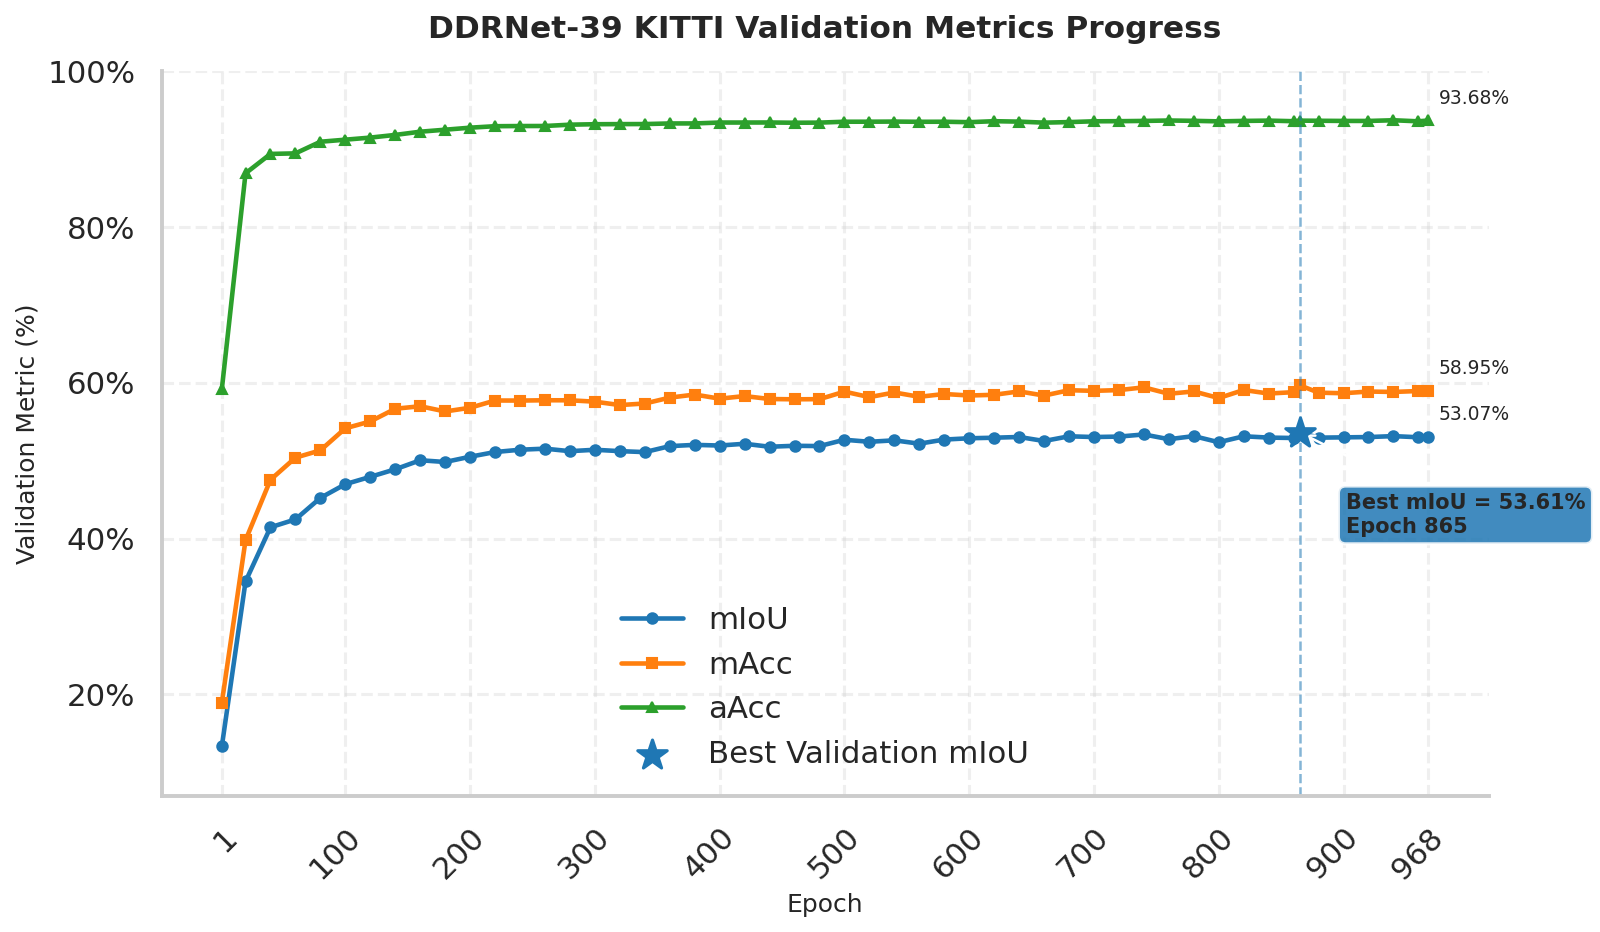


[✓] Filtered KITTI Polynomial-LR figure saved:
    /home/hrusikesh-nishank/Pictures/DDRNet_kitti/Results_Export_DDRNet_kitti/presentation_learning_rate_schedule_DDRNet39_KITTI.png


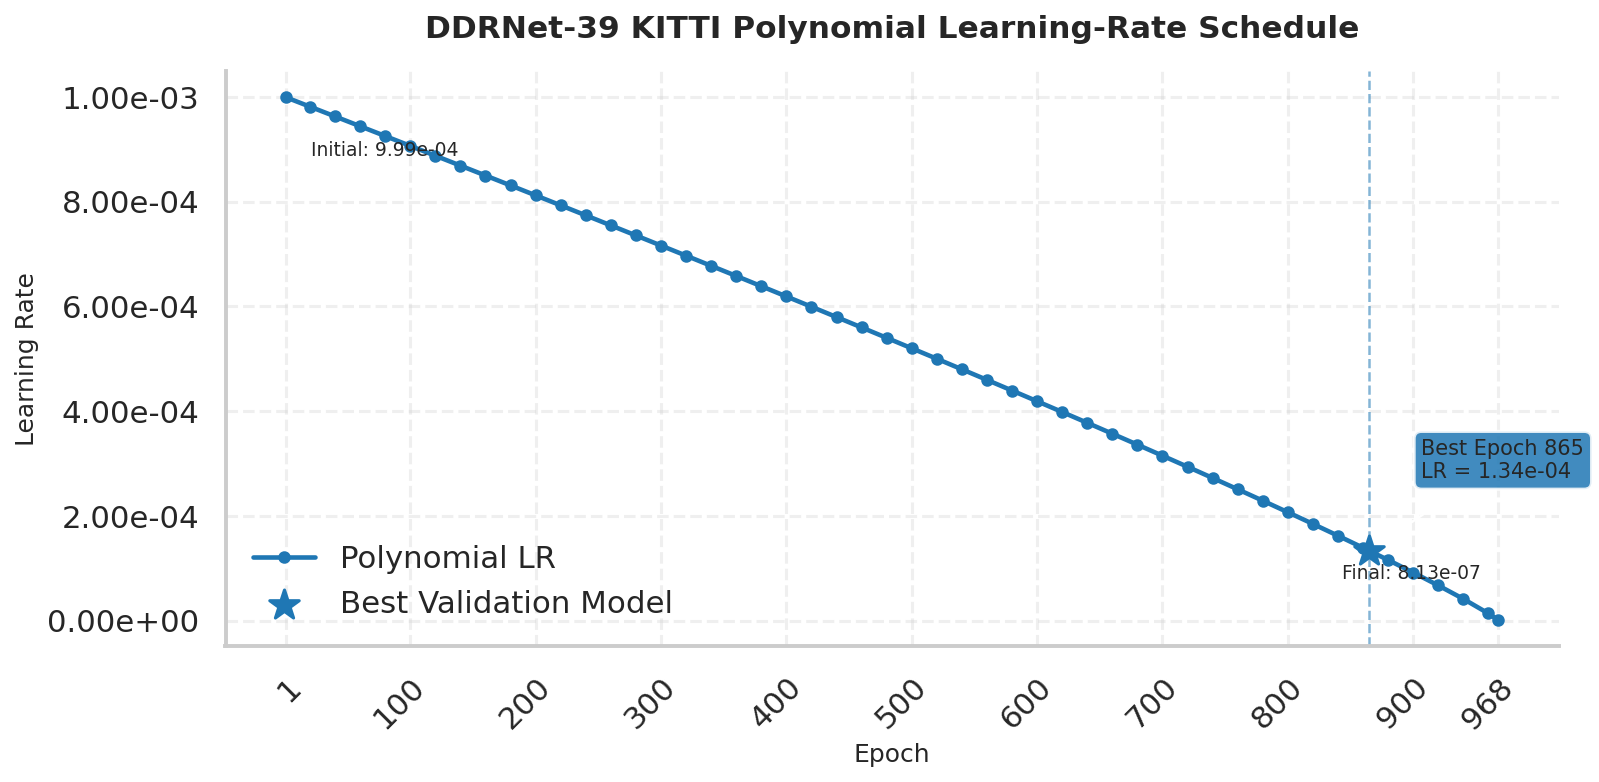


STEP 7 COMPLETE — DDRNet-39 / KITTI
[*] Recorded epochs          : 968
[*] Best Validation mIoU     : 53.61%
[*] Best Validation Epoch    : 865
[*] mAcc at Best Epoch       : 59.67%
[*] aAcc at Best Epoch       : 93.65%
[*] LR at Best Epoch         : 1.335422e-04
------------------------------------------------------------------------------------------
[*] Final Validation mIoU    : 53.07%
[*] Final Validation mAcc    : 58.95%
[*] Final Validation aAcc    : 93.68%
[*] Final Learning Rate      : 8.133359e-07
------------------------------------------------------------------------------------------
[*] Metric sampling step     : 20 epochs
[*] X-axis tick step         : 100 epochs
[*] Metric points displayed  : 51
[*] Figure display enabled   : True
------------------------------------------------------------------------------------------
[*] Generated figures:
    1. presentation_combined_metrics_DDRNet39_KITTI.png
    2. presentation_learning_rate_schedule_DDRNet39_KITTI.png

[*] Both 

In [8]:
# ============================================================
# STEP 7 — DDRNet-39 / KITTI
# PUBLICATION-READY FILTERED VALIDATION METRICS
# AND POLYNOMIAL LEARNING-RATE SCHEDULE
#
# Target Architecture:
# DDRNet-39
#
# Target Dataset:
# KITTI Semantic Segmentation — 19 Classes
#
# Purpose:
#   1. Produce one clean combined validation-metrics figure:
#
#          mIoU
#          mAcc
#          aAcc
#
#   2. Produce one clean Polynomial LR figure
#
#   3. Mark the true best validation checkpoint
#
#   4. Keep the 968-epoch experiment visually readable
#
#   5. Save figures at 600 DPI
#
#   6. Display only TWO final figures once in Jupyter
#
# Important:
#   - Metrics come directly from corrected Step-5 history
#   - mAcc = mean class recall
#   - aAcc = global valid-pixel accuracy
#   - Best epoch is based on validation mIoU
#   - No multi-scale TTA is involved here
#   - No additional evaluation is performed
#
# Notebook Safety:
#   - No full tables
#   - No repeated figures
#   - Only two final plots displayed
#
# No new imports are required.
# ============================================================


# ============================================================
# 0. SAFETY CHECKS
# ============================================================

required_globals = [
    "history",
    "FINAL_SAVE_DIR",
    "MODEL_NAME",
    "EXPERIMENT_NAME",
    "EPOCHS",
    "BASE_LR",
    "LR_POWER",
    "best_record",
    "DISPLAY_FINAL_REPORT_PLOTS",
    "NOTEBOOK_SAFE_MODE",
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise NameError(
        "Required objects are missing. "
        "Run corrected Steps 1-6 first.\n"
        f"Missing: {missing_globals}"
    )


required_history_keys = [
    "epoch",
    "val_miou",
    "val_macc",
    "val_aacc",
    "learning_rate",
]


missing_history_keys = [
    key
    for key in required_history_keys
    if (
        key not in history
        or len(
            history[
                key
            ]
        ) == 0
    )
]


if missing_history_keys:

    raise ValueError(
        "Required DDRNet-39 KITTI history entries "
        "are missing or empty:\n"
        f"{missing_history_keys}"
    )


if not FINAL_SAVE_DIR.exists():

    raise FileNotFoundError(
        "FINAL_SAVE_DIR does not exist. "
        "Run the previous steps first."
    )


history_length = len(
    history[
        "epoch"
    ]
)


for key in required_history_keys:


    if len(
        history[
            key
        ]
    ) != history_length:


        raise ValueError(
            f"History length mismatch for '{key}'.\n"
            f"Expected : {history_length}\n"
            f"Found    : {len(history[key])}"
        )


if history_length < 1:

    raise RuntimeError(
        "Training history is empty."
    )


print(
    "[✓] Step 7 safety checks passed."
)


# ============================================================
# 1. CONVERT HISTORY TO NUMPY ARRAYS
# ============================================================

epoch_values = np.asarray(
    history[
        "epoch"
    ],
    dtype=np.int64
)


val_miou_values = np.asarray(
    history[
        "val_miou"
    ],
    dtype=np.float64
)


val_macc_values = np.asarray(
    history[
        "val_macc"
    ],
    dtype=np.float64
)


val_aacc_values = np.asarray(
    history[
        "val_aacc"
    ],
    dtype=np.float64
)


learning_rate_values = np.asarray(
    history[
        "learning_rate"
    ],
    dtype=np.float64
)


# ============================================================
# 2. FINITENESS CHECKS
# ============================================================

if np.isnan(
    val_miou_values
).all():

    raise ValueError(
        "Validation mIoU history contains no valid values."
    )


if np.isnan(
    val_macc_values
).all():

    raise ValueError(
        "Validation mAcc history contains no valid values."
    )


if np.isnan(
    val_aacc_values
).all():

    raise ValueError(
        "Validation aAcc history contains no valid values."
    )


if np.isnan(
    learning_rate_values
).all():

    raise ValueError(
        "Learning-rate history contains no valid values."
    )


finite_metric_mask = (
    np.isfinite(
        val_miou_values
    )
    &
    np.isfinite(
        val_macc_values
    )
    &
    np.isfinite(
        val_aacc_values
    )
)


if not finite_metric_mask.any():

    raise RuntimeError(
        "No epoch contains finite validation "
        "mIoU, mAcc and aAcc simultaneously."
    )


# ============================================================
# 3. EPOCH ORDER CHECK
# ============================================================

if (
    np.diff(
        epoch_values
    )
    <= 0
).any():

    raise RuntimeError(
        "Epoch history is not strictly increasing."
    )


first_epoch = int(
    epoch_values[
        0
    ]
)


final_epoch = int(
    epoch_values[
        -1
    ]
)


# ============================================================
# 4. FIND TRUE BEST VALIDATION mIoU
# ============================================================

best_miou_index = int(
    np.nanargmax(
        val_miou_values
    )
)


best_epoch_from_history = int(
    epoch_values[
        best_miou_index
    ]
)


best_miou_pct = float(
    val_miou_values[
        best_miou_index
    ]
)


best_macc_at_best = float(
    val_macc_values[
        best_miou_index
    ]
)


best_aacc_at_best = float(
    val_aacc_values[
        best_miou_index
    ]
)


best_lr = float(
    learning_rate_values[
        best_miou_index
    ]
)


# ============================================================
# 5. VERIFY AGAINST BEST_RECORD
# ============================================================

recorded_best_epoch = int(
    best_record.get(
        "best_epoch",
        best_record.get(
            "epoch",
            -1
        )
    )
)


recorded_best_miou = float(
    best_record.get(
        "best_miou",
        np.nan
    )
)


print(
    "\n--- Best Epoch Verification ---"
)


print(
    f"[*] History best epoch    : "
    f"{best_epoch_from_history}"
)


print(
    f"[*] History best mIoU     : "
    f"{best_miou_pct:.4f}%"
)


print(
    f"[*] best_record epoch     : "
    f"{recorded_best_epoch}"
)


print(
    f"[*] best_record mIoU      : "
    f"{recorded_best_miou:.4f}%"
)


if (
    recorded_best_epoch > 0
    and recorded_best_epoch
    != best_epoch_from_history
):

    warnings.warn(
        "Best epoch in history differs from best_record.\n"
        f"History     : {best_epoch_from_history}\n"
        f"best_record : {recorded_best_epoch}"
    )


if (
    np.isfinite(
        recorded_best_miou
    )
    and abs(
        recorded_best_miou
        - best_miou_pct
    ) > 0.10
):

    warnings.warn(
        "Best mIoU in history differs from best_record "
        "by more than 0.10 percentage points."
    )


# Use history as the plotting source.
best_epoch = (
    best_epoch_from_history
)


# ============================================================
# 6. FINAL-EPOCH METRICS
# ============================================================

final_miou = float(
    val_miou_values[
        -1
    ]
)


final_macc = float(
    val_macc_values[
        -1
    ]
)


final_aacc = float(
    val_aacc_values[
        -1
    ]
)


final_lr = float(
    learning_rate_values[
        -1
    ]
)


# ============================================================
# 7. STEP-7 SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 86
)


print(
    "DDRNet-39 / KITTI — STEP 7 PLOTTING SUMMARY"
)


print(
    "=" * 86
)


print(
    f"[*] Experiment               : "
    f"{EXPERIMENT_NAME}"
)


print(
    f"[*] Recorded epochs          : "
    f"{history_length}"
)


print(
    f"[*] Configured epoch budget  : "
    f"{EPOCHS}"
)


print(
    f"[*] First recorded epoch     : "
    f"{first_epoch}"
)


print(
    f"[*] Final recorded epoch     : "
    f"{final_epoch}"
)


print(
    f"[*] Best validation mIoU     : "
    f"{best_miou_pct:.2f}%"
)


print(
    f"[*] Best epoch               : "
    f"{best_epoch}"
)


print(
    f"[*] mAcc at best epoch       : "
    f"{best_macc_at_best:.2f}%"
)


print(
    f"[*] aAcc at best epoch       : "
    f"{best_aacc_at_best:.2f}%"
)


print(
    f"[*] LR at best epoch         : "
    f"{best_lr:.6e}"
)


print(
    "=" * 86
)


# ============================================================
# 8. FILTERED DATA-POINT INTERVAL
# ============================================================
#
# 968 epochs are too dense for publication when every point
# is marked.
#
# Data curves:
#
#       <= 150 epochs  -> every 5 epochs
#       <= 500 epochs  -> every 10 epochs
#       >  500 epochs  -> every 20 epochs
#
# For our corrected 968-epoch run:
#
#       every 20 epochs
#
# The best and final epochs are always included.
# ============================================================

if history_length <= 150:


    PLOT_SAMPLE_STEP = 5


elif history_length <= 500:


    PLOT_SAMPLE_STEP = 10


else:


    PLOT_SAMPLE_STEP = 20


# ============================================================
# 9. X-AXIS TICK INTERVAL
# ============================================================
#
# Plot points can be every 20 epochs while labels are much
# less frequent.
#
# For ~968 epochs use approximately every 100 epochs.
# ============================================================

if history_length <= 150:


    X_TICK_STEP = 10


elif history_length <= 500:


    X_TICK_STEP = 50


else:


    X_TICK_STEP = 100


print(
    "\n--- Plot Filtering ---"
)


print(
    f"[*] Metric sampling step : "
    f"{PLOT_SAMPLE_STEP}"
)


print(
    f"[*] X-axis tick step     : "
    f"{X_TICK_STEP}"
)


# ============================================================
# 10. ROBUST EPOCH -> INDEX MAP
# ============================================================

epoch_to_index = {

    int(
        epoch
    ):
        index

    for index, epoch
    in enumerate(
        epoch_values
    )
}


# ============================================================
# 11. FILTERED PLOT EPOCHS
# ============================================================

plot_epochs = [
    int(
        epoch
    )

    for epoch
    in epoch_values

    if (
        epoch == first_epoch

        or epoch
        % PLOT_SAMPLE_STEP
        == 0
    )
]


# Always include final epoch.
if final_epoch not in plot_epochs:


    plot_epochs.append(
        final_epoch
    )


# Always include best epoch.
if best_epoch not in plot_epochs:


    plot_epochs.append(
        best_epoch
    )


plot_epochs = sorted(
    set(
        plot_epochs
    )
)


plot_indices = [
    epoch_to_index[
        epoch
    ]

    for epoch
    in plot_epochs
]


# ============================================================
# 12. X-AXIS TICKS
# ============================================================

tick_epochs = [
    int(
        epoch
    )

    for epoch
    in epoch_values

    if (
        epoch == first_epoch

        or epoch
        % X_TICK_STEP
        == 0
    )
]


if final_epoch not in tick_epochs:


    tick_epochs.append(
        final_epoch
    )


tick_epochs = sorted(
    set(
        tick_epochs
    )
)


# ============================================================
# 13. FILTERED METRIC SERIES
# ============================================================

filtered_miou = (
    val_miou_values[
        plot_indices
    ]
)


filtered_macc = (
    val_macc_values[
        plot_indices
    ]
)


filtered_aacc = (
    val_aacc_values[
        plot_indices
    ]
)


filtered_lr = (
    learning_rate_values[
        plot_indices
    ]
)


# ============================================================
# 14. FILTERED SERIES FINITENESS CHECK
# ============================================================

if not np.isfinite(
    filtered_miou
).all():

    raise RuntimeError(
        "Filtered validation mIoU contains NaN/Inf."
    )


if not np.isfinite(
    filtered_macc
).all():

    raise RuntimeError(
        "Filtered validation mAcc contains NaN/Inf."
    )


if not np.isfinite(
    filtered_aacc
).all():

    raise RuntimeError(
        "Filtered validation aAcc contains NaN/Inf."
    )


if not np.isfinite(
    filtered_lr
).all():

    raise RuntimeError(
        "Filtered learning-rate history contains NaN/Inf."
    )


# ============================================================
# 15. COMBINED VALIDATION METRICS FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        11,
        6.5
    )
)


# ============================================================
# mIoU
# ============================================================

ax.plot(
    plot_epochs,
    filtered_miou,
    marker="o",
    linewidth=2.2,
    markersize=5,
    label="mIoU"
)


# ============================================================
# mAcc
# ============================================================

ax.plot(
    plot_epochs,
    filtered_macc,
    marker="s",
    linewidth=2.2,
    markersize=5,
    label="mAcc"
)


# ============================================================
# aAcc
# ============================================================

ax.plot(
    plot_epochs,
    filtered_aacc,
    marker="^",
    linewidth=2.2,
    markersize=5,
    label="aAcc"
)


# ============================================================
# 16. BEST mIoU MARKER
# ============================================================

ax.scatter(
    [
        best_epoch
    ],
    [
        best_miou_pct
    ],
    marker="*",
    s=220,
    label="Best Validation mIoU",
    zorder=6
)


# ============================================================
# 17. BEST-EPOCH VERTICAL LINE
# ============================================================

ax.axvline(
    x=best_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.55
)


# ============================================================
# 18. BEST mIoU ANNOTATION
# ============================================================

ax.annotate(
    (
        f"Best mIoU = "
        f"{best_miou_pct:.2f}%\n"
        f"Epoch {best_epoch}"
    ),

    xy=(
        best_epoch,
        best_miou_pct
    ),

    xytext=(
        22,
        -48
    ),

    textcoords="offset points",

    fontsize=10,

    fontweight="bold",

    bbox=dict(
        boxstyle="round,pad=0.35",
        alpha=0.85
    ),

    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.2
    )
)


# ============================================================
# 19. FINAL-EPOCH VALUE MARKERS
# ============================================================

final_value_offset = 0.8


ax.annotate(
    f"{final_miou:.2f}%",

    xy=(
        final_epoch,
        final_miou
    ),

    xytext=(
        5,
        8
    ),

    textcoords="offset points",

    fontsize=9
)


ax.annotate(
    f"{final_macc:.2f}%",

    xy=(
        final_epoch,
        final_macc
    ),

    xytext=(
        5,
        8
    ),

    textcoords="offset points",

    fontsize=9
)


ax.annotate(
    f"{final_aacc:.2f}%",

    xy=(
        final_epoch,
        final_aacc
    ),

    xytext=(
        5,
        8
    ),

    textcoords="offset points",

    fontsize=9
)


# ============================================================
# 20. METRIC FIGURE AXES
# ============================================================

ax.set_xlabel(
    "Epoch",
    fontsize=12
)


ax.set_ylabel(
    "Validation Metric (%)",
    fontsize=12
)


ax.set_title(
    "DDRNet-39 KITTI Validation Metrics Progress",
    fontsize=15,
    fontweight="bold",
    pad=16
)


ax.set_xticks(
    tick_epochs
)


ax.set_xticklabels(
    [
        str(
            epoch
        )

        for epoch
        in tick_epochs
    ]
)


plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(
        decimals=0
    )
)


# ============================================================
# 21. METRIC Y-AXIS RANGE
# ============================================================
#
# Use data-driven limits instead of forcing 0-100 when the
# actual curves occupy a much narrower region.
# ============================================================

combined_metric_values = np.concatenate(
    [
        filtered_miou,
        filtered_macc,
        filtered_aacc
    ]
)


metric_min = float(
    np.nanmin(
        combined_metric_values
    )
)


metric_max = float(
    np.nanmax(
        combined_metric_values
    )
)


metric_margin = max(
    3.0,
    (
        metric_max
        - metric_min
    )
    * 0.08
)


ax.set_ylim(
    max(
        0.0,
        metric_min
        - metric_margin
    ),
    min(
        100.0,
        metric_max
        + metric_margin
    )
)


# ============================================================
# 22. METRIC FIGURE STYLE
# ============================================================

ax.grid(
    True,
    linestyle="--",
    alpha=0.3
)


ax.spines[
    "top"
].set_visible(
    False
)


ax.spines[
    "right"
].set_visible(
    False
)


ax.legend(
    loc="best",
    frameon=False
)


fig.tight_layout()


# ============================================================
# 23. SAVE COMBINED METRICS FIGURE
# ============================================================

combined_graph_path = (
    FINAL_SAVE_DIR
    / "presentation_combined_metrics_DDRNet39_KITTI.png"
)


fig.savefig(
    combined_graph_path,
    dpi=600,
    bbox_inches="tight"
)


print(
    "\n[✓] Combined KITTI validation-metrics figure saved:"
)


print(
    f"    {combined_graph_path}"
)


# ============================================================
# DISPLAY ONCE
# ============================================================

if DISPLAY_FINAL_REPORT_PLOTS:


    plt.show()


plt.close(
    fig
)


# ============================================================
# 24. POLYNOMIAL LEARNING-RATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        11,
        5.5
    )
)


# ============================================================
# LR CURVE
# ============================================================

ax.plot(
    plot_epochs,
    filtered_lr,
    marker="o",
    linewidth=2.2,
    markersize=5,
    label="Polynomial LR"
)


# ============================================================
# BEST MODEL LR MARKER
# ============================================================

ax.scatter(
    [
        best_epoch
    ],
    [
        best_lr
    ],
    marker="*",
    s=220,
    label="Best Validation Model",
    zorder=6
)


ax.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.55
)


# ============================================================
# 25. BEST LR ANNOTATION
# ============================================================

ax.annotate(
    (
        f"Best Epoch {best_epoch}\n"
        f"LR = {best_lr:.2e}"
    ),

    xy=(
        best_epoch,
        best_lr
    ),

    xytext=(
        25,
        35
    ),

    textcoords="offset points",

    fontsize=10,

    bbox=dict(
        boxstyle="round,pad=0.35",
        alpha=0.85
    ),

    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.2
    )
)


# ============================================================
# 26. INITIAL / FINAL LR ANNOTATIONS
# ============================================================

initial_lr_recorded = float(
    learning_rate_values[
        0
    ]
)


ax.annotate(
    f"Initial: {initial_lr_recorded:.2e}",

    xy=(
        first_epoch,
        initial_lr_recorded
    ),

    xytext=(
        12,
        -28
    ),

    textcoords="offset points",

    fontsize=9
)


ax.annotate(
    f"Final: {final_lr:.2e}",

    xy=(
        final_epoch,
        final_lr
    ),

    xytext=(
        -75,
        20
    ),

    textcoords="offset points",

    fontsize=9
)


# ============================================================
# 27. LR FIGURE AXES
# ============================================================

ax.set_xlabel(
    "Epoch",
    fontsize=12
)


ax.set_ylabel(
    "Learning Rate",
    fontsize=12
)


ax.set_title(
    "DDRNet-39 KITTI Polynomial Learning-Rate Schedule",
    fontsize=15,
    fontweight="bold",
    pad=16
)


ax.set_xticks(
    tick_epochs
)


ax.set_xticklabels(
    [
        str(
            epoch
        )

        for epoch
        in tick_epochs
    ]
)


plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)


ax.yaxis.set_major_formatter(
    mtick.FormatStrFormatter(
        "%.2e"
    )
)


# ============================================================
# 28. LR FIGURE STYLE
# ============================================================

ax.grid(
    True,
    linestyle="--",
    alpha=0.3
)


ax.spines[
    "top"
].set_visible(
    False
)


ax.spines[
    "right"
].set_visible(
    False
)


ax.legend(
    loc="best",
    frameon=False
)


fig.tight_layout()


# ============================================================
# 29. SAVE POLYLR FIGURE
# ============================================================

lr_filtered_path = (
    FINAL_SAVE_DIR
    / "presentation_learning_rate_schedule_DDRNet39_KITTI.png"
)


fig.savefig(
    lr_filtered_path,
    dpi=600,
    bbox_inches="tight"
)


print(
    "\n[✓] Filtered KITTI Polynomial-LR figure saved:"
)


print(
    f"    {lr_filtered_path}"
)


# ============================================================
# DISPLAY ONCE
# ============================================================

if DISPLAY_FINAL_REPORT_PLOTS:


    plt.show()


plt.close(
    fig
)


# ============================================================
# 30. FINAL STEP-7 SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 90
)


print(
    "STEP 7 COMPLETE — DDRNet-39 / KITTI"
)


print(
    "=" * 90
)


print(
    f"[*] Recorded epochs          : "
    f"{history_length}"
)


print(
    f"[*] Best Validation mIoU     : "
    f"{best_miou_pct:.2f}%"
)


print(
    f"[*] Best Validation Epoch    : "
    f"{best_epoch}"
)


print(
    f"[*] mAcc at Best Epoch       : "
    f"{best_macc_at_best:.2f}%"
)


print(
    f"[*] aAcc at Best Epoch       : "
    f"{best_aacc_at_best:.2f}%"
)


print(
    f"[*] LR at Best Epoch         : "
    f"{best_lr:.6e}"
)


print(
    "-" * 90
)


print(
    f"[*] Final Validation mIoU    : "
    f"{final_miou:.2f}%"
)


print(
    f"[*] Final Validation mAcc    : "
    f"{final_macc:.2f}%"
)


print(
    f"[*] Final Validation aAcc    : "
    f"{final_aacc:.2f}%"
)


print(
    f"[*] Final Learning Rate      : "
    f"{final_lr:.6e}"
)


print(
    "-" * 90
)


print(
    f"[*] Metric sampling step     : "
    f"{PLOT_SAMPLE_STEP} epochs"
)


print(
    f"[*] X-axis tick step         : "
    f"{X_TICK_STEP} epochs"
)


print(
    f"[*] Metric points displayed  : "
    f"{len(plot_epochs)}"
)


print(
    f"[*] Figure display enabled   : "
    f"{DISPLAY_FINAL_REPORT_PLOTS}"
)


print(
    "-" * 90
)


print(
    "[*] Generated figures:"
)


print(
    f"    1. {combined_graph_path.name}"
)


print(
    f"    2. {lr_filtered_path.name}"
)


print(
    "\n[*] Both figures saved at 600 DPI."
)


print(
    "[*] Only two final figures were displayed in Jupyter."
)


print(
    "[*] No large tables or repeated figures were embedded."
)


print(
    "=" * 90
)